In [2]:
# ============================================================================
# FINAL PREDICTION: Attention U-Net + ConvLSTM — Yearly Data
# Train on ALL data (1990–2025) → Predict 2026–2040 (15 years)
# FIXED: Lambda layers replaced with custom layer for safe serialization
# ============================================================================

# ── Suppress TF / XLA / CUDA warnings BEFORE importing tensorflow ──
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['XLA_FLAGS'] = '--xla_gpu_strict_conv_algorithm_picker=false'
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'

import re
import glob
import logging
import numpy as np
import pandas as pd

logging.getLogger('tensorflow').setLevel(logging.FATAL)
logging.getLogger('absl').setLevel(logging.FATAL)

import tensorflow as tf
tf.get_logger().setLevel('FATAL')
tf.autograph.set_verbosity(0)

import warnings
warnings.filterwarnings('ignore')
import absl.logging
absl.logging.set_verbosity(absl.logging.FATAL)
absl.logging._warn_preinit_stderr = False

from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback
)
from tensorflow.keras.optimizers import Adam
import rasterio
from sklearn.metrics import precision_score, recall_score
from skimage.transform import resize
import cv2
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')

np.random.seed(42)
tf.random.set_seed(42)

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ GPU configured: {len(gpus)} GPU(s) available")
    except RuntimeError as e:
        print(f"GPU Error: {e}")
else:
    print("⚠ No GPU found, using CPU")

# GPU warmup
_warmup = tf.zeros((1, 1), dtype=tf.float32)
_ = tf.matmul(_warmup, _warmup)
del _warmup

# ============================================================================
# CONFIGURATION
# ============================================================================

DATA_DIR = "/kaggle/input/datasets/kaoserahamed/riverbank/river"
IMG_HEIGHT = 256
IMG_WIDTH = 256

# ── Best sequence length from Setup 1 experiments ──
# Change this to whichever seq_len gave the best IoU in your Setup 1 runs
BEST_SEQ_LEN = 5

PREDICTION_HORIZON = 1
STRIDE = 1
EPOCHS = 200
EARLY_STOP_PATIENCE = 20
REDUCE_LR_PATIENCE = 7
BATCH_SIZE = 4
N_COMPONENTS = 3

# Future prediction configuration
FUTURE_YEARS_TO_PREDICT = 15  # 2026 through 2040

# ============================================================================
# CUSTOM LAYER: Replace Lambda for safe serialization
# ============================================================================

@tf.keras.utils.register_keras_serializable(package="Custom", name="LastTimeStep")
class LastTimeStep(layers.Layer):
    """
    Extracts the last time step from a 5D tensor.
    Input:  (batch, timesteps, H, W, C)
    Output: (batch, H, W, C)
    
    Replaces: Lambda(lambda x: x[:, -1, :, :, :])
    This is serialization-safe (no anonymous lambda).
    """
    def __init__(self, **kwargs):
        super(LastTimeStep, self).__init__(**kwargs)

    def call(self, inputs):
        return inputs[:, -1, :, :, :]

    def compute_output_shape(self, input_shape):
        return (input_shape[0],) + input_shape[2:]

    def get_config(self):
        return super(LastTimeStep, self).get_config()


# ============================================================================
# PREPROCESSING FUNCTIONS
# ============================================================================

def keep_largest_n_components_cv2(mask, n=1):
    binary_mask = (mask > 0).astype(np.uint8)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        binary_mask, connectivity=8
    )
    if num_labels <= 1:
        return np.zeros_like(mask)
    areas = stats[1:, cv2.CC_STAT_AREA]
    sorted_indices = np.argsort(areas)[::-1]
    n_to_keep = min(n, len(sorted_indices))
    top_n_indices = sorted_indices[:n_to_keep]
    cleaned_mask = np.zeros_like(mask)
    for idx in top_n_indices:
        actual_label = idx + 1
        cleaned_mask[labels == actual_label] = mask.max()
    return cleaned_mask


def load_and_preprocess_image(filepath, apply_cleaning=True, n_components=N_COMPONENTS):
    with rasterio.open(filepath) as src:
        img = src.read(1)
    if apply_cleaning:
        img = keep_largest_n_components_cv2(img, n=n_components)
    img_resized = resize(
        img, (IMG_HEIGHT, IMG_WIDTH),
        mode='constant', preserve_range=True, anti_aliasing=False
    )
    img_binary = (img_resized > 0.5).astype(np.float32)
    return img_binary


def create_sequences_with_years(images, years, seq_len):
    """Create sequences with year tracking."""
    X, y, input_years_list, target_years_list = [], [], [], []
    for i in range(0, len(images) - seq_len - PREDICTION_HORIZON + 1, STRIDE):
        X.append(images[i:i + seq_len])
        y.append(images[i + seq_len])
        input_years_list.append(years[i:i + seq_len])
        target_years_list.append(years[i + seq_len])
    return (np.array(X), np.array(y),
            np.array(input_years_list), np.array(target_years_list))


# ============================================================================
# LOSSES AND METRICS
# ============================================================================

@tf.keras.utils.register_keras_serializable(package="Custom", name="dice_coefficient")
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


@tf.keras.utils.register_keras_serializable(package="Custom", name="dice_loss")
def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)


@tf.keras.utils.register_keras_serializable(package="Custom", name="combined_loss")
def combined_loss(y_true, y_pred):
    bce = K.mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    return bce + dice_loss(y_true, y_pred)


@tf.keras.utils.register_keras_serializable(package="Custom", name="iou_metric")
def iou_metric(y_true, y_pred, threshold=0.5):
    y_pred_binary = K.cast(y_pred > threshold, dtype='float32')
    y_true_binary = K.cast(y_true > threshold, dtype='float32')
    intersection = K.sum(y_true_binary * y_pred_binary)
    union = K.sum(y_true_binary) + K.sum(y_pred_binary) - intersection
    return (intersection + K.epsilon()) / (union + K.epsilon())


def dice_coefficient_np(y_true, y_pred, threshold=0.5):
    y_true_b = (y_true > threshold).astype(np.float32)
    y_pred_b = (y_pred > threshold).astype(np.float32)
    intersection = np.sum(y_true_b * y_pred_b)
    return (2. * intersection) / (np.sum(y_true_b) + np.sum(y_pred_b) + 1e-6)


def iou_np(y_true, y_pred, threshold=0.5):
    y_true_b = (y_true > threshold).astype(np.float32)
    y_pred_b = (y_pred > threshold).astype(np.float32)
    intersection = np.sum(y_true_b * y_pred_b)
    union = np.sum(y_true_b) + np.sum(y_pred_b) - intersection
    return intersection / (union + 1e-6)


def calculate_area_km2(mask, pixel_area_km2, threshold=0.5):
    return np.sum((mask > threshold).astype(np.float32)) * pixel_area_km2


# ============================================================================
# CUSTOM STRUCTURED TRAINING CALLBACK
# ============================================================================

class StructuredTrainingLogger(Callback):
    """Compact one-line-per-epoch logger with aligned columns."""

    def __init__(self, total_epochs):
        super().__init__()
        self.total_epochs = total_epochs
        self.best_val_loss = np.inf

    def on_train_begin(self, logs=None):
        header = (
            f"{'Ep':>4s}/{'Tot':<4s} │ {'Loss':>8s} │ {'VLoss':>8s} │ "
            f"{'Dice':>6s} │ {'VDice':>6s} │ {'IoU':>6s} │ "
            f"{'VIoU':>6s} │ {'LR':>9s} │ Note"
        )
        print("─" * len(header))
        print(header)
        print("─" * len(header))

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        loss = logs.get('loss', 0)
        vloss = logs.get('val_loss', 0)
        dice = logs.get('dice_coefficient', 0)
        vdice = logs.get('val_dice_coefficient', 0)
        iou = logs.get('iou_metric', 0)
        viou = logs.get('val_iou_metric', 0)
        lr = float(K.get_value(self.model.optimizer.learning_rate))

        note = ""
        if vloss < self.best_val_loss:
            self.best_val_loss = vloss
            note = "★ saved"

        print(
            f"{epoch+1:>4d}/{self.total_epochs:<4d} │ {loss:>8.4f} │ {vloss:>8.4f} │ "
            f"{dice:>6.4f} │ {vdice:>6.4f} │ {iou:>6.4f} │ "
            f"{viou:>6.4f} │ {lr:>9.2e} │ {note}"
        )

    def on_train_end(self, logs=None):
        print("─" * 85)
        print(f"  Training finished  │  Best val_loss: {self.best_val_loss:.4f}")
        print("─" * 85)


# ============================================================================
# CALLBACKS FACTORY
# ============================================================================

def create_callbacks(model_name, checkpoint_dir='checkpoints_final'):
    os.makedirs(checkpoint_dir, exist_ok=True)
    ckpt_path = os.path.join(checkpoint_dir, f'{model_name}_best.keras')
    return [
        ModelCheckpoint(
            ckpt_path,
            monitor='val_loss', save_best_only=True,
            save_weights_only=False, mode='min', verbose=0
        ),
        EarlyStopping(
            monitor='val_loss', patience=EARLY_STOP_PATIENCE,
            restore_best_weights=True, verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=REDUCE_LR_PATIENCE, min_lr=1e-7, verbose=0
        ),
        StructuredTrainingLogger(total_epochs=EPOCHS),
    ]


# ============================================================================
# MODEL DEFINITION: Attention U-Net + ConvLSTM (Lambda-free)
# ============================================================================

def attention_block(x, g, inter_channel):
    theta_x = layers.Conv2D(inter_channel, 1, strides=1, padding='same')(x)
    phi_g = layers.Conv2D(inter_channel, 1, strides=1, padding='same')(g)
    f = layers.Activation('relu')(layers.Add()([theta_x, phi_g]))
    psi_f = layers.Conv2D(1, 1, strides=1, padding='same', activation='sigmoid')(f)
    return layers.Multiply()([x, psi_f])


def build_attention_unet_convlstm_model(seq_len):
    input_shape = (seq_len, IMG_HEIGHT, IMG_WIDTH, 1)
    inputs = layers.Input(shape=input_shape)

    # ── Encoder ──
    enc1 = layers.TimeDistributed(
        layers.Conv2D(32, 3, padding='same', activation='relu'))(inputs)
    enc1 = layers.TimeDistributed(layers.BatchNormalization())(enc1)
    enc1 = layers.TimeDistributed(
        layers.Conv2D(32, 3, padding='same', activation='relu'))(enc1)
    pool1 = layers.TimeDistributed(layers.MaxPooling2D(2))(enc1)
    pool1 = layers.TimeDistributed(layers.Dropout(0.2))(pool1)

    enc2 = layers.TimeDistributed(
        layers.Conv2D(64, 3, padding='same', activation='relu'))(pool1)
    enc2 = layers.TimeDistributed(layers.BatchNormalization())(enc2)
    enc2 = layers.TimeDistributed(
        layers.Conv2D(64, 3, padding='same', activation='relu'))(enc2)
    pool2 = layers.TimeDistributed(layers.MaxPooling2D(2))(enc2)
    pool2 = layers.TimeDistributed(layers.Dropout(0.2))(pool2)

    enc3 = layers.TimeDistributed(
        layers.Conv2D(128, 3, padding='same', activation='relu'))(pool2)
    enc3 = layers.TimeDistributed(layers.BatchNormalization())(enc3)
    pool3 = layers.TimeDistributed(layers.MaxPooling2D(2))(enc3)
    pool3 = layers.TimeDistributed(layers.Dropout(0.3))(pool3)

    # ── Bottleneck with ConvLSTM ──
    bottleneck = layers.TimeDistributed(
        layers.Conv2D(256, 3, padding='same', activation='relu'))(pool3)

    lstm1 = layers.ConvLSTM2D(
        256, (3, 3), padding='same', return_sequences=True, dropout=0.3)(bottleneck)
    lstm1 = layers.BatchNormalization()(lstm1)

    lstm2 = layers.ConvLSTM2D(
        128, (3, 3), padding='same', return_sequences=False, dropout=0.3)(lstm1)
    lstm2 = layers.BatchNormalization()(lstm2)

    # ── Extract last time step using CUSTOM LAYER (not Lambda) ──
    enc3_last = LastTimeStep(name='enc3_last_timestep')(enc3)
    enc2_last = LastTimeStep(name='enc2_last_timestep')(enc2)
    enc1_last = LastTimeStep(name='enc1_last_timestep')(enc1)

    # ── Decoder with attention skip connections ──
    up3 = layers.UpSampling2D(2)(lstm2)
    att3 = attention_block(enc3_last, up3, 128)
    up3 = layers.Concatenate()([up3, att3])
    dec3 = layers.Conv2D(128, 3, padding='same', activation='relu')(up3)
    dec3 = layers.BatchNormalization()(dec3)
    dec3 = layers.Dropout(0.2)(dec3)

    up2 = layers.UpSampling2D(2)(dec3)
    att2 = attention_block(enc2_last, up2, 64)
    up2 = layers.Concatenate()([up2, att2])
    dec2 = layers.Conv2D(64, 3, padding='same', activation='relu')(up2)
    dec2 = layers.BatchNormalization()(dec2)
    dec2 = layers.Dropout(0.2)(dec2)

    up1 = layers.UpSampling2D(2)(dec2)
    att1 = attention_block(enc1_last, up1, 32)
    up1 = layers.Concatenate()([up1, att1])
    dec1 = layers.Conv2D(32, 3, padding='same', activation='relu')(up1)
    dec1 = layers.BatchNormalization()(dec1)

    dec1 = layers.Conv2D(16, 3, padding='same', activation='relu')(dec1)
    outputs = layers.Conv2D(1, 1, padding='same', activation='sigmoid')(dec1)

    model = models.Model(inputs, outputs,
                         name=f'AttUNet_ConvLSTM_seq{seq_len}')
    model.compile(
        optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
        loss=combined_loss,
        metrics=[dice_coefficient, iou_metric]
    )
    return model


# ============================================================================
# POST-PROCESSING FOR PREDICTED MASKS
# ============================================================================

def post_process_prediction(pred_mask, threshold=0.5, n_components=N_COMPONENTS):
    """
    Binarize and clean a predicted mask:
    1. Threshold to binary
    2. Keep only the largest N connected components
    3. Morphological closing to smooth boundaries
    """
    binary = (pred_mask > threshold).astype(np.uint8)
    binary = keep_largest_n_components_cv2(binary, n=n_components)
    binary = (binary > 0).astype(np.uint8)

    # Morphological closing to smooth jagged edges
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    return binary.astype(np.float32)


# ============================================================================
# AUTOREGRESSIVE FUTURE PREDICTION
# ============================================================================

def predict_future_autoregressive(model, seed_images, n_steps, seq_len,
                                  post_process=True):
    """
    Autoregressively predict n_steps into the future.

    Args:
        model: Trained Attention U-Net + ConvLSTM model
        seed_images: Array of the last `seq_len` known images (seq_len, H, W)
        n_steps: Number of future steps to predict
        seq_len: Sequence length the model expects
        post_process: Whether to clean each prediction before feeding back

    Returns:
        future_predictions: np.array of shape (n_steps, H, W)
    """
    rolling_window = list(seed_images[-seq_len:].copy())
    future_predictions = []

    for step in range(n_steps):
        # Prepare input: (1, seq_len, H, W, 1)
        input_seq = np.array(rolling_window[-seq_len:])
        input_seq = np.expand_dims(input_seq, axis=(0, -1))

        # Predict next step
        pred = model.predict(input_seq, verbose=0)
        pred_mask = pred[0, :, :, 0]

        # Post-process to reduce drift
        if post_process:
            pred_mask = post_process_prediction(pred_mask)

        future_predictions.append(pred_mask)

        # Slide the window forward
        rolling_window.append(pred_mask)

        print(f"  Step {step+1}/{n_steps} predicted │ "
              f"River pixels: {np.sum(pred_mask > 0.5):,.0f} │ "
              f"Area fraction: {np.mean(pred_mask > 0.5):.4f}")

    return np.array(future_predictions)


# ============================================================================
# PHASE 1: LOAD DATA
# ============================================================================

print("=" * 80)
print("  PHASE 1: LOADING ALL YEARLY DATA")
print("=" * 80)

files = sorted(glob.glob(os.path.join(DATA_DIR, "*.tif")))
file_info = []
for filepath in files:
    filename = os.path.basename(filepath)
    match = re.search(r'(\d{4})', filename)
    if match:
        file_info.append({
            'filepath': filepath, 'filename': filename,
            'year': int(match.group(1))
        })

df_files = pd.DataFrame(file_info).sort_values('year').reset_index(drop=True)
print(f"Found {len(df_files)} files, years {df_files['year'].min()}-{df_files['year'].max()}")

all_images, all_years = [], []
for idx, row in df_files.iterrows():
    img = load_and_preprocess_image(row['filepath'])
    all_images.append(img)
    all_years.append(row['year'])
    if (idx + 1) % 10 == 0:
        print(f"  Processed {idx+1}/{len(df_files)} images...")

all_images = np.array(all_images)
all_years = np.array(all_years)
print(f"✓ Loaded {len(all_images)} images │ Years: {all_years.min()}-{all_years.max()}")

# Pixel area calculation
with rasterio.open(df_files.iloc[0]['filepath']) as src:
    bounds = src.bounds
    center_lat = (bounds.top + bounds.bottom) / 2
    if src.crs and src.crs.to_epsg() == 4326:
        meters_per_deg_lon = 111320 * np.cos(np.radians(center_lat))
        width_m = (bounds.right - bounds.left) * meters_per_deg_lon
        height_m = (bounds.top - bounds.bottom) * 111320
        total_area_km2 = (width_m * height_m) / 1e6
    else:
        total_area_km2 = (
            (bounds.right - bounds.left) * (bounds.top - bounds.bottom)
        ) / 1e6

pixel_area_km2 = total_area_km2 / (IMG_HEIGHT * IMG_WIDTH)
print(f"✓ Pixel area: {pixel_area_km2:.8f} km²")

last_known_year = all_years.max()
future_years = np.arange(last_known_year + 1,
                         last_known_year + 1 + FUTURE_YEARS_TO_PREDICT)
print(f"✓ Last known year: {last_known_year}")
print(f"✓ Will predict: {future_years[0]} → {future_years[-1]} "
      f"({FUTURE_YEARS_TO_PREDICT} steps)")

# ============================================================================
# PHASE 2: TRAIN ON 100% OF DATA
# ============================================================================

print("\n" + "=" * 80)
print(f"  PHASE 2: TRAINING ON 100% DATA │ SeqLen={BEST_SEQ_LEN}")
print("=" * 80)

X_all, y_all, iy_all, ty_all = create_sequences_with_years(
    all_images.tolist(), all_years.tolist(), BEST_SEQ_LEN
)
print(f"✓ Total sequences: {len(X_all)} │ "
      f"Target years: {ty_all.min()}-{ty_all.max()}")

# 85/15 temporal split (validation is only for early stopping)
sort_idx = np.argsort(ty_all)
X_sorted = X_all[sort_idx]
y_sorted = y_all[sort_idx]
ty_sorted = ty_all[sort_idx]

split_idx = int(len(X_sorted) * 0.85)
X_train = np.expand_dims(X_sorted[:split_idx], axis=-1)
y_train = np.expand_dims(y_sorted[:split_idx], axis=-1)
X_val = np.expand_dims(X_sorted[split_idx:], axis=-1)
y_val = np.expand_dims(y_sorted[split_idx:], axis=-1)

print(f"  Train: {len(X_train)} samples (years {ty_sorted[:split_idx].min()}-"
      f"{ty_sorted[:split_idx].max()})")
print(f"  Val:   {len(X_val)} samples (years {ty_sorted[split_idx:].min()}-"
      f"{ty_sorted[split_idx:].max()})")

# Build and train
K.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model = build_attention_unet_convlstm_model(BEST_SEQ_LEN)
model.summary()

tag = f"final_yearly_seq{BEST_SEQ_LEN}"
print(f"\n  Training {tag} (max {EPOCHS} epochs, "
      f"early-stop patience={EARLY_STOP_PATIENCE})\n")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=create_callbacks(tag, checkpoint_dir='checkpoints_final'),
    verbose=0
)

stopped_epoch = len(history.history['loss'])
best_val_loss = min(history.history['val_loss'])
best_val_dice = max(history.history['val_dice_coefficient'])
best_val_iou = max(history.history['val_iou_metric'])

print(f"\n✓ Training complete │ Stopped at epoch {stopped_epoch}/{EPOCHS}")
print(f"  Best val_loss={best_val_loss:.4f} │ "
      f"val_dice={best_val_dice:.4f} │ val_iou={best_val_iou:.4f}")

# Load best checkpoint (NOW WORKS — no Lambda layers)
ckpt_path = f'checkpoints_final/{tag}_best.keras'
if os.path.exists(ckpt_path):
    model = tf.keras.models.load_model(
        ckpt_path,
        custom_objects={
            'combined_loss': combined_loss,
            'dice_coefficient': dice_coefficient,
            'iou_metric': iou_metric,
            'LastTimeStep': LastTimeStep,
        }
    )
    print(f"✓ Loaded best model from {ckpt_path}")
else:
    print(f"⚠ Checkpoint not found at {ckpt_path}, using last trained weights")

# ============================================================================
# PHASE 3: SANITY CHECK — Predict Known Years
# ============================================================================

print("\n" + "=" * 80)
print("  PHASE 3: SANITY CHECK — Reconstruction of Known Years")
print("=" * 80)

n_sanity = min(10, len(X_all))
X_sanity = np.expand_dims(X_all[-n_sanity:], axis=-1)
y_sanity = y_all[-n_sanity:]
ty_sanity = ty_all[-n_sanity:]

preds_sanity = model.predict(X_sanity, verbose=0)

print(f"\n{'Year':>6s} │ {'IoU':>8s} │ {'Dice':>8s} │ {'Area_True_km²':>14s} │ "
      f"{'Area_Pred_km²':>14s} │ {'ΔArea_km²':>12s}")
print("─" * 80)

sanity_results = []
for i in range(n_sanity):
    yt = y_sanity[i]
    yp = preds_sanity[i, :, :, 0]
    yp_clean = post_process_prediction(yp)
    year = ty_sanity[i]

    iou_val = iou_np(yt, yp_clean)
    dice_val = dice_coefficient_np(yt, yp_clean)
    area_true = calculate_area_km2(yt, pixel_area_km2)
    area_pred = calculate_area_km2(yp_clean, pixel_area_km2)
    delta = area_pred - area_true

    sanity_results.append({
        'Year': year, 'IoU': iou_val, 'Dice': dice_val,
        'Area_True_km2': area_true, 'Area_Pred_km2': area_pred,
        'Delta_Area_km2': delta
    })

    print(f"{year:>6d} │ {iou_val:>8.4f} │ {dice_val:>8.4f} │ "
          f"{area_true:>14.4f} │ {area_pred:>14.4f} │ {delta:>12.4f}")

df_sanity = pd.DataFrame(sanity_results)
print("─" * 80)
print(f"{'MEAN':>6s} │ {df_sanity['IoU'].mean():>8.4f} │ "
      f"{df_sanity['Dice'].mean():>8.4f} │ "
      f"{df_sanity['Area_True_km2'].mean():>14.4f} │ "
      f"{df_sanity['Area_Pred_km2'].mean():>14.4f} │ "
      f"{df_sanity['Delta_Area_km2'].mean():>12.4f}")

# ============================================================================
# PHASE 4: AUTOREGRESSIVE FUTURE PREDICTION (2026–2040)
# ============================================================================

print("\n" + "=" * 80)
print(f"  PHASE 4: PREDICTING {future_years[0]}–{future_years[-1]} "
      f"({FUTURE_YEARS_TO_PREDICT} steps)")
print("=" * 80)

seed_images = all_images[-BEST_SEQ_LEN:]
seed_years = all_years[-BEST_SEQ_LEN:]
print(f"Seed years: {seed_years.tolist()}")

future_predictions = predict_future_autoregressive(
    model=model,
    seed_images=seed_images,
    n_steps=FUTURE_YEARS_TO_PREDICT,
    seq_len=BEST_SEQ_LEN,
    post_process=True
)

print(f"\n✓ Generated {len(future_predictions)} future predictions")

# ============================================================================
# PHASE 5: COMPUTE FUTURE STATISTICS
# ============================================================================

print("\n" + "=" * 80)
print("  PHASE 5: FUTURE PREDICTION STATISTICS")
print("=" * 80)

last_known_area = calculate_area_km2(all_images[-1], pixel_area_km2)
last_known_pixels = np.sum(all_images[-1] > 0.5)

print(f"\nBaseline ({last_known_year}): "
      f"Area = {last_known_area:.4f} km² │ "
      f"River pixels = {last_known_pixels:,.0f}")

future_stats = []
print(f"\n{'Year':>6s} │ {'Area_km²':>10s} │ {'ΔArea_km²':>12s} │ "
      f"{'ΔArea_%':>10s} │ {'River_Pixels':>14s} │ "
      f"{'Δ_from_prev_km²':>16s}")
print("─" * 85)

prev_area = last_known_area
for i, year in enumerate(future_years):
    pred = future_predictions[i]
    area = calculate_area_km2(pred, pixel_area_km2)
    delta_from_baseline = area - last_known_area
    delta_pct = (delta_from_baseline / last_known_area * 100) if last_known_area > 0 else 0
    delta_from_prev = area - prev_area
    river_pixels = np.sum(pred > 0.5)

    future_stats.append({
        'Year': year,
        'Area_km2': area,
        'Delta_from_baseline_km2': delta_from_baseline,
        'Delta_pct': delta_pct,
        'River_Pixels': river_pixels,
        'Delta_from_prev_km2': delta_from_prev
    })

    print(f"{year:>6d} │ {area:>10.4f} │ {delta_from_baseline:>12.4f} │ "
          f"{delta_pct:>9.2f}% │ {river_pixels:>14,.0f} │ "
          f"{delta_from_prev:>16.4f}")

    prev_area = area

df_future = pd.DataFrame(future_stats)
print("─" * 85)
print(f"\n  Total area change ({future_years[0]}-{future_years[-1]}): "
      f"{df_future['Delta_from_baseline_km2'].iloc[-1]:.4f} km² "
      f"({df_future['Delta_pct'].iloc[-1]:.2f}%)")

# ============================================================================
# PHASE 6: CHANGE DETECTION — Cumulative Erosion/Accretion Maps
# ============================================================================

print("\n" + "=" * 80)
print("  PHASE 6: CHANGE DETECTION ANALYSIS")
print("=" * 80)

last_known_binary = (all_images[-1] > 0.5).astype(np.float32)

change_maps = {}
for i, year in enumerate(future_years):
    pred_binary = (future_predictions[i] > 0.5).astype(np.float32)

    erosion = last_known_binary * (1 - pred_binary)
    accretion = (1 - last_known_binary) * pred_binary
    stable = last_known_binary * pred_binary

    erosion_area = calculate_area_km2(erosion, pixel_area_km2)
    accretion_area = calculate_area_km2(accretion, pixel_area_km2)
    stable_area = calculate_area_km2(stable, pixel_area_km2)

    change_maps[year] = {
        'erosion': erosion, 'accretion': accretion, 'stable': stable,
        'erosion_area_km2': erosion_area,
        'accretion_area_km2': accretion_area,
        'stable_area_km2': stable_area,
    }

    print(f"  {year}: Erosion={erosion_area:.4f} km² │ "
          f"Accretion={accretion_area:.4f} km² │ "
          f"Stable={stable_area:.4f} km² │ "
          f"Net={accretion_area - erosion_area:+.4f} km²")

# ============================================================================
# PHASE 7: VISUALIZATION
# ============================================================================

print("\n" + "=" * 80)
print("  PHASE 7: GENERATING VISUALIZATIONS")
print("=" * 80)

# ── 7A: Training Curves ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], label='Train Loss', linewidth=1.5)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=1.5)
axes[0].set_title('Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['dice_coefficient'], label='Train Dice', linewidth=1.5)
axes[1].plot(history.history['val_dice_coefficient'], label='Val Dice', linewidth=1.5)
axes[1].set_title('Dice Coefficient', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Dice')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(history.history['iou_metric'], label='Train IoU', linewidth=1.5)
axes[2].plot(history.history['val_iou_metric'], label='Val IoU', linewidth=1.5)
axes[2].set_title('IoU', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('IoU')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Final Model Training Curves (seq={BEST_SEQ_LEN}, '
             f'stopped@{stopped_epoch})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('final_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved → final_training_curves.png")

# ── 7B: Future Area Trend ──
fig, ax = plt.subplots(figsize=(14, 6))

historical_areas = [calculate_area_km2(img, pixel_area_km2) for img in all_images]
ax.plot(all_years, historical_areas, 'b-o', markersize=4,
        label='Historical (observed)', linewidth=2)

ax.plot(future_years, df_future['Area_km2'].values, 'r--s', markersize=6,
        label='Predicted (future)', linewidth=2)

ax.axvline(x=last_known_year + 0.5, color='gray', linestyle=':', linewidth=1.5,
           label=f'Prediction boundary ({last_known_year})')

# Expanding confidence band
future_areas = df_future['Area_km2'].values
for i, year in enumerate(future_years):
    step = i + 1
    uncertainty = 0.02 * step * future_areas[i]
    ax.fill_between(
        [year], [future_areas[i] - uncertainty], [future_areas[i] + uncertainty],
        alpha=0.15, color='red'
    )

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('River Area (km²)', fontsize=12)
ax.set_title(f'Riverbank Area: Historical & Predicted '
             f'({future_years[0]}-{future_years[-1]})',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('final_area_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved → final_area_trend.png")

# ── 7C: Future Prediction Masks (Grid) ──
n_future = len(future_predictions)
n_cols = 5
n_rows = int(np.ceil(n_future / n_cols))

fig, axes_grid = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes_flat = axes_grid.flatten() if n_rows > 1 else (
    axes_grid if isinstance(axes_grid, np.ndarray) else [axes_grid])

for i in range(len(axes_flat)):
    if i < n_future:
        axes_flat[i].imshow(future_predictions[i], cmap='Blues', vmin=0, vmax=1)
        area = df_future.iloc[i]['Area_km2']
        delta = df_future.iloc[i]['Delta_pct']
        axes_flat[i].set_title(
            f"{future_years[i]}\n{area:.3f} km² ({delta:+.1f}%)",
            fontsize=10, fontweight='bold'
        )
    axes_flat[i].axis('off')

plt.suptitle(
    f'Predicted River Masks: {future_years[0]}–{future_years[-1]} '
    f'(AttUNet+ConvLSTM, seq={BEST_SEQ_LEN})',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('final_future_masks_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved → final_future_masks_grid.png")

# ── 7D: Change Detection Maps (Milestone Years) ──
milestone_years = [future_years[0], future_years[4], future_years[9], future_years[-1]]
milestone_years = [y for y in milestone_years if y in change_maps]

fig, axes_cd = plt.subplots(1, len(milestone_years),
                            figsize=(6 * len(milestone_years), 6))
if len(milestone_years) == 1:
    axes_cd = [axes_cd]

for ax, year in zip(axes_cd, milestone_years):
    cm = change_maps[year]
    rgb = np.zeros((IMG_HEIGHT, IMG_WIDTH, 3))
    rgb[:, :, 2] = cm['stable']
    rgb[:, :, 0] = cm['erosion']
    rgb[:, :, 1] = cm['accretion']

    ax.imshow(rgb)
    ax.set_title(
        f"{year} vs {last_known_year}\n"
        f"Erosion: {cm['erosion_area_km2']:.3f} km² │ "
        f"Accretion: {cm['accretion_area_km2']:.3f} km²",
        fontsize=10, fontweight='bold'
    )
    ax.axis('off')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', label='Stable River'),
    Patch(facecolor='red', label='Erosion (Lost)'),
    Patch(facecolor='green', label='Accretion (Gained)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=12, bbox_to_anchor=(0.5, -0.02))

plt.suptitle(
    f'Change Detection: {last_known_year} → Future '
    f'(AttUNet+ConvLSTM, seq={BEST_SEQ_LEN})',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('final_change_detection_maps.png', dpi=200, bbox_inches='tight')
plt.show()
print("✓ Saved → final_change_detection_maps.png")

# ── 7E: Erosion vs Accretion Over Time ──
fig, ax = plt.subplots(figsize=(12, 6))

erosion_vals = [change_maps[y]['erosion_area_km2'] for y in future_years]
accretion_vals = [change_maps[y]['accretion_area_km2'] for y in future_years]
net_vals = [a - e for a, e in zip(accretion_vals, erosion_vals)]

ax.bar(future_years - 0.2, erosion_vals, 0.35, color='red', alpha=0.7,
       label='Erosion (km²)')
ax.bar(future_years + 0.2, accretion_vals, 0.35, color='green', alpha=0.7,
       label='Accretion (km²)')
ax.plot(future_years, net_vals, 'k-o', markersize=5, linewidth=2,
        label='Net Change (km²)')
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Area (km²)', fontsize=12)
ax.set_title(f'Erosion vs Accretion: {future_years[0]}–{future_years[-1]} '
             f'(relative to {last_known_year})',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('final_erosion_accretion_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved → final_erosion_accretion_trend.png")

# ── 7F: Side-by-Side — Last Known vs Predicted at Milestones ──
fig, axes_evo = plt.subplots(1, len(milestone_years) + 1,
                             figsize=(5 * (len(milestone_years) + 1), 5))

axes_evo[0].imshow(all_images[-1], cmap='gray')
axes_evo[0].set_title(f'Actual {last_known_year}\n'
                      f'{last_known_area:.3f} km²',
                      fontsize=11, fontweight='bold')
axes_evo[0].axis('off')

for idx, year in enumerate(milestone_years):
    i = np.where(future_years == year)[0][0]
    area = df_future.iloc[i]['Area_km2']
    axes_evo[idx + 1].imshow(future_predictions[i], cmap='gray')
    axes_evo[idx + 1].set_title(f'Predicted {year}\n{area:.3f} km²',
                                fontsize=11, fontweight='bold')
    axes_evo[idx + 1].axis('off')

plt.suptitle(f'River Morphology Evolution '
             f'({last_known_year} → {future_years[-1]})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('final_evolution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved → final_evolution_comparison.png")

# ============================================================================
# PHASE 8: SAVE PREDICTIONS AS GeoTIFF
# ============================================================================

print("\n" + "=" * 80)
print("  PHASE 8: SAVING PREDICTIONS")
print("=" * 80)

output_dir = 'future_predictions'
os.makedirs(output_dir, exist_ok=True)

with rasterio.open(df_files.iloc[0]['filepath']) as src:
    original_profile = src.profile.copy()
    original_shape = (src.height, src.width)

for i, year in enumerate(future_years):
    pred_original_size = resize(
        future_predictions[i], original_shape,
        mode='constant', preserve_range=True, anti_aliasing=False
    )
    pred_binary = (pred_original_size > 0.5).astype(np.uint8)

    out_path = os.path.join(output_dir, f'predicted_{year}.tif')
    profile = original_profile.copy()
    profile.update(dtype='uint8', count=1, compress='lzw')

    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(pred_binary, 1)

    print(f"  ✓ Saved {out_path}")

np.save(os.path.join(output_dir, 'future_predictions_raw.npy'), future_predictions)
np.save(os.path.join(output_dir, 'future_years.npy'), future_years)

df_future.to_csv(os.path.join(output_dir, 'future_statistics.csv'), index=False)

change_stats = []
for year in future_years:
    cm = change_maps[year]
    change_stats.append({
        'Year': year,
        'Erosion_km2': cm['erosion_area_km2'],
        'Accretion_km2': cm['accretion_area_km2'],
        'Stable_km2': cm['stable_area_km2'],
        'Net_Change_km2': cm['accretion_area_km2'] - cm['erosion_area_km2']
    })
df_change = pd.DataFrame(change_stats)
df_change.to_csv(os.path.join(output_dir, 'change_detection_statistics.csv'),
                 index=False)

print(f"\n✓ All predictions saved to '{output_dir}/' directory")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "█" * 80)
print("  FINAL PREDICTION SUMMARY")
print("█" * 80)
print(f"""
  Model:           Attention U-Net + ConvLSTM
  Sequence Length:  {BEST_SEQ_LEN}
  Training Data:    {all_years.min()}-{all_years.max()} ({len(all_images)} years, 100%)
  Training Epochs:  {stopped_epoch}/{EPOCHS} (early stopped)
  Best Val Loss:    {best_val_loss:.4f}
  Best Val Dice:    {best_val_dice:.4f}
  Best Val IoU:     {best_val_iou:.4f}

  Prediction Range: {future_years[0]}-{future_years[-1]} ({FUTURE_YEARS_TO_PREDICT} years)
  Baseline Area:    {last_known_area:.4f} km² ({last_known_year})
  Final Area:       {df_future.iloc[-1]['Area_km2']:.4f} km² ({future_years[-1]})
  Total Change:     {df_future.iloc[-1]['Delta_from_baseline_km2']:+.4f} km² \
({df_future.iloc[-1]['Delta_pct']:+.2f}%)

  Sanity Check (known years):
    Mean IoU:       {df_sanity['IoU'].mean():.4f}
    Mean Dice:      {df_sanity['Dice'].mean():.4f}

  Output Files:
    • future_predictions/predicted_YYYY.tif  (GeoTIFF per year)
    • future_predictions/future_statistics.csv
    • future_predictions/change_detection_statistics.csv
    • future_predictions/future_predictions_raw.npy
    • final_training_curves.png
    • final_area_trend.png
    • final_future_masks_grid.png
    • final_change_detection_maps.png
    • final_erosion_accretion_trend.png
    • final_evolution_comparison.png
""")

print("=" * 80)
print("  ✓ ALL DONE — Final yearly prediction pipeline complete")
print("=" * 80)

✓ GPU configured: 2 GPU(s) available
  PHASE 1: LOADING ALL YEARLY DATA
Found 39 files, years 1987-2025
  Processed 10/39 images...
  Processed 20/39 images...
  Processed 30/39 images...
✓ Loaded 39 images │ Years: 1987-2025
✓ Pixel area: 0.32843740 km²
✓ Last known year: 2025
✓ Will predict: 2026 → 2040 (15 steps)

  PHASE 2: TRAINING ON 100% DATA │ SeqLen=5
✓ Total sequences: 34 │ Target years: 1992-2025
  Train: 28 samples (years 1992-2019)
  Val:   6 samples (years 2020-2025)


Model: "AttUNet_ConvLSTM_seq5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 5, 256,    │          0 │ -                 │
│ (InputLayer)        │ 256, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 5, 256,    │        320 │ input_layer[0][0] │
│ (TimeDistributed)   │ 256, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 5, 256,    │        128 │ time_distributed… │
│ (TimeDistributed)   │ 256, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 5, 256,    │      9,248 │ time_distributed… │
│ (TimeDistributed)   │ 256, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_3  │ (None, 5, 128,    │          0 │ time_distributed… │
│ (TimeDistributed)   │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_4  │ (None, 5, 128,    │          0 │ time_distributed… │
│ (TimeDistributed)   │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_5  │ (None, 5, 128,    │     18,496 │ time_distributed… │
│ (TimeDistributed)   │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_6  │ (None, 5, 128,    │        256 │ time_distributed… │
│ (TimeDistributed)   │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_7  │ (None, 5, 128,    │     36,928 │ time_distributed… │
│ (TimeDistributed)   │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_8  │ (None, 5, 64, 64, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_9  │ (None, 5, 64, 64, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_10 │ (None, 5, 64, 64, │     73,856 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_11 │ (None, 5, 64, 64, │        512 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_12 │ (None, 5, 32, 32, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_13 │ (None, 5, 32, 32, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_14 │ (None, 5, 32, 32, │    295,168 │ time_distributed… │
│ (TimeDistributed)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d         │ (None, 5, 32, 32, │  4,719,616 │ time_distributed

 Total params: 7,413,764 (28.28 MB)

 Trainable params: 7,412,100 (28.27 MB)

 Non-trainable params: 1,664 (6.50 KB)


  Training final_yearly_seq5 (max 200 epochs, early-stop patience=20)

──────────────────────────────────────────────────────────────────────────────────────
  Ep/Tot  │     Loss │    VLoss │   Dice │  VDice │    IoU │   VIoU │        LR │ Note
──────────────────────────────────────────────────────────────────────────────────────
   1/200  │   1.5272 │   1.6229 │ 0.0741 │ 0.0500 │ 0.0675 │ 0.0177 │  1.00e-04 │ ★ saved
   2/200  │   1.2797 │   1.5240 │ 0.1111 │ 0.0502 │ 0.1618 │ 0.0001 │  1.00e-04 │ ★ saved
   3/200  │   1.1314 │   1.3619 │ 0.1540 │ 0.0497 │ 0.2857 │ 0.0000 │  1.00e-04 │ ★ saved
   4/200  │   1.0285 │   1.2320 │ 0.1975 │ 0.0488 │ 0.4006 │ 0.0000 │  1.00e-04 │ ★ saved
   5/200  │   0.9508 │   1.1567 │ 0.2349 │ 0.0482 │ 0.4677 │ 0.0000 │  1.00e-04 │ ★ saved
   6/200  │   0.8841 │   1.1146 │ 0.2713 │ 0.0486 │ 0.5131 │ 0.0000 │  1.00e-04 │ ★ saved
   7/200  │   0.8259 │   1.0864 │ 0.3067 │ 0.0537 │ 0.5438 │ 0.0000 │  1.00e-04 │ ★ saved
   8/200  │   0.7720 │   0.9267 │ 0.3

In [3]:
# ============================================================================
# ZIP & DOWNLOAD ALL OUTPUTS
# ============================================================================

import os
import zipfile
from glob import glob

# ── Define output zip name ──
ZIP_FILENAME = "final_prediction_outputs.zip"

# ── Collect all output files ──
output_files = []

# 1. Saved plots (PNG files in working directory)
plot_files = [
    'final_training_curves.png',
    'final_area_trend.png',
    'final_future_masks_grid.png',
    'final_change_detection_maps.png',
    'final_erosion_accretion_trend.png',
    'final_evolution_comparison.png',
]
for f in plot_files:
    if os.path.exists(f):
        output_files.append(f)

# 2. Future predictions directory (GeoTIFFs, CSVs, NPY files)
pred_dir = 'future_predictions'
if os.path.isdir(pred_dir):
    for root, dirs, files in os.walk(pred_dir):
        for file in files:
            filepath = os.path.join(root, file)
            output_files.append(filepath)

# 3. Best model checkpoint
ckpt_dir = 'checkpoints_final'
if os.path.isdir(ckpt_dir):
    for root, dirs, files in os.walk(ckpt_dir):
        for file in files:
            filepath = os.path.join(root, file)
            output_files.append(filepath)

# ── Create ZIP ──
print("=" * 60)
print("  CREATING ZIP ARCHIVE")
print("=" * 60)

with zipfile.ZipFile(ZIP_FILENAME, 'w', zipfile.ZIP_DEFLATED) as zf:
    for filepath in output_files:
        zf.write(filepath)
        size_kb = os.path.getsize(filepath) / 1024
        print(f"  ✓ Added: {filepath:<55s} ({size_kb:>8.1f} KB)")

zip_size_mb = os.path.getsize(ZIP_FILENAME) / (1024 * 1024)
print(f"\n{'─' * 60}")
print(f"  ✓ ZIP created: {ZIP_FILENAME} ({zip_size_mb:.2f} MB)")
print(f"  ✓ Total files: {len(output_files)}")
print(f"{'─' * 60}")

# ── Download (Kaggle / Colab compatible) ──
try:
    # Google Colab
    from google.colab import files
    files.download(ZIP_FILENAME)
    print("  ✓ Download triggered (Colab)")
except ImportError:
    try:
        # Kaggle — copy to output directory
        kaggle_output = '/kaggle/working'
        if os.path.exists(kaggle_output):
            dest = os.path.join(kaggle_output, ZIP_FILENAME)
            if os.path.abspath(ZIP_FILENAME) != os.path.abspath(dest):
                import shutil
                shutil.copy2(ZIP_FILENAME, dest)
            print(f"  ✓ Available at: {dest}")
            print(f"  ✓ Go to: Output tab → Download '{ZIP_FILENAME}'")
        else:
            print(f"  ✓ ZIP saved locally: {os.path.abspath(ZIP_FILENAME)}")
    except Exception as e:
        print(f"  ✓ ZIP saved locally: {os.path.abspath(ZIP_FILENAME)}")

print("\n  ✓ ALL OUTPUTS ZIPPED — Ready for download")

  CREATING ZIP ARCHIVE
  ✓ Added: final_training_curves.png                               (   134.5 KB)
  ✓ Added: final_area_trend.png                                    (   107.1 KB)
  ✓ Added: final_future_masks_grid.png                             (   571.4 KB)
  ✓ Added: final_change_detection_maps.png                         (   104.7 KB)
  ✓ Added: final_erosion_accretion_trend.png                       (    67.4 KB)
  ✓ Added: final_evolution_comparison.png                          (   111.7 KB)
  ✓ Added: future_predictions/predicted_2029.tif                   (    56.9 KB)
  ✓ Added: future_predictions/predicted_2037.tif                   (    56.7 KB)
  ✓ Added: future_predictions/predicted_2031.tif                   (    56.9 KB)
  ✓ Added: future_predictions/predicted_2030.tif                   (    56.9 KB)
  ✓ Added: future_predictions/future_years.npy                     (     0.2 KB)
  ✓ Added: future_predictions/predicted_2036.tif                   (    56.7 KB)
  ✓ A

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ Download triggered (Colab)

  ✓ ALL OUTPUTS ZIPPED — Ready for download


In [4]:
# ============================================================================
# GENERATE GEOREFERENCED RISK MAPS WITH PROBABILITY ZONES
# Full-resolution water masks + risk overlays for GIS/Map placement
# ============================================================================

import os
import numpy as np
import cv2
import rasterio
from rasterio.transform import from_bounds
from skimage.transform import resize
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import zipfile

# ============================================================================
# CONFIGURATION
# ============================================================================

OUTPUT_DIR = 'georeferenced_risk_maps'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Risk probability thresholds
RISK_LEVELS = {
    'Very High Risk': {'min': 0.8, 'max': 1.0, 'color': (255, 0, 0),       'alpha': 0.9},
    'High Risk':      {'min': 0.6, 'max': 0.8, 'color': (255, 100, 0),     'alpha': 0.75},
    'Moderate Risk':  {'min': 0.4, 'max': 0.6, 'color': (255, 200, 0),     'alpha': 0.6},
    'Low Risk':       {'min': 0.2, 'max': 0.4, 'color': (255, 255, 0),     'alpha': 0.45},
    'Very Low Risk':  {'min': 0.0, 'max': 0.2, 'color': (0, 200, 0),       'alpha': 0.3},
}

# Dot density per risk level (dots per pixel of that class)
DOT_DENSITY = {
    'Very High Risk': 0.15,
    'High Risk':      0.10,
    'Moderate Risk':  0.06,
    'Low Risk':       0.03,
    'Very Low Risk':  0.01,
}

# ============================================================================
# STEP 1: GET ORIGINAL GEOSPATIAL METADATA
# ============================================================================

print("=" * 80)
print("  STEP 1: READING ORIGINAL GEOSPATIAL METADATA")
print("=" * 80)

# Read metadata from the first original raster
original_file = df_files.iloc[0]['filepath']
with rasterio.open(original_file) as src:
    original_crs = src.crs
    original_transform = src.transform
    original_bounds = src.bounds
    original_height = src.height
    original_width = src.width
    original_profile = src.profile.copy()

print(f"  CRS:        {original_crs}")
print(f"  Bounds:     {original_bounds}")
print(f"  Dimensions: {original_width} x {original_height} pixels")
print(f"  Transform:  {original_transform}")

# ============================================================================
# STEP 2: COMPUTE MULTI-YEAR EROSION PROBABILITY MAP
# ============================================================================

print("\n" + "=" * 80)
print("  STEP 2: COMPUTING EROSION PROBABILITY MAPS")
print("=" * 80)

# Get the last known river mask at original resolution
with rasterio.open(df_files.iloc[-1]['filepath']) as src:
    last_known_original = src.read(1)
    last_known_original = keep_largest_n_components_cv2(
        last_known_original, n=N_COMPONENTS
    )
    last_known_binary_orig = (last_known_original > 0).astype(np.float32)

print(f"  Last known year ({last_known_year}): "
      f"{np.sum(last_known_binary_orig > 0):,} river pixels")

# Resize all future predictions to original dimensions
future_preds_original = []
for i, year in enumerate(future_years):
    pred_resized = resize(
        future_predictions[i],
        (original_height, original_width),
        mode='constant', preserve_range=True, anti_aliasing=False
    )
    pred_binary = (pred_resized > 0.5).astype(np.float32)
    future_preds_original.append(pred_binary)
    print(f"  {year}: Resized to {original_width}x{original_height} | "
          f"River pixels: {np.sum(pred_binary > 0):,}")

future_preds_original = np.array(future_preds_original)

# ── Compute erosion probability: How often does each pixel become river? ──
# This tells us: "Over the next N years, what fraction of predictions
# show this pixel as part of the river?"
river_frequency = np.mean(future_preds_original, axis=0)  # 0-1 probability

# ── Compute CHANGE probability: Where does the river shift? ──
# Erosion zone = currently NOT river, but predicted to become river (bank erosion)
# Accretion zone = currently IS river, but predicted to become NOT river

erosion_probability = np.zeros((original_height, original_width), dtype=np.float32)
accretion_probability = np.zeros((original_height, original_width), dtype=np.float32)

for i in range(len(future_preds_original)):
    # Erosion: pixel was NOT river (in baseline), IS river in prediction
    erosion_probability += (1 - last_known_binary_orig) * future_preds_original[i]
    # Accretion: pixel WAS river (in baseline), NOT river in prediction
    accretion_probability += last_known_binary_orig * (1 - future_preds_original[i])

# Normalize to 0-1
n_years = len(future_preds_original)
erosion_probability /= n_years
accretion_probability /= n_years

# Combined risk = erosion OR accretion probability
combined_risk = np.maximum(erosion_probability, accretion_probability)

print(f"\n  Erosion probability range:   [{erosion_probability.min():.4f}, "
      f"{erosion_probability.max():.4f}]")
print(f"  Accretion probability range: [{accretion_probability.min():.4f}, "
      f"{accretion_probability.max():.4f}]")
print(f"  Combined risk range:         [{combined_risk.min():.4f}, "
      f"{combined_risk.max():.4f}]")

# ============================================================================
# STEP 3: GENERATE GEOREFERENCED RISK GeoTIFFs
# ============================================================================

print("\n" + "=" * 80)
print("  STEP 3: SAVING GEOREFERENCED GeoTIFFs")
print("=" * 80)


def save_geotiff(data, filename, profile, dtype='float32', nodata=None):
    """Save a 2D array as a georeferenced GeoTIFF."""
    out_profile = profile.copy()
    out_profile.update(
        dtype=dtype, count=1, compress='lzw',
        nodata=nodata
    )
    filepath = os.path.join(OUTPUT_DIR, filename)
    with rasterio.open(filepath, 'w', **out_profile) as dst:
        dst.write(data.astype(dtype), 1)
    print(f"  ✓ {filename:<50s} ({os.path.getsize(filepath)/1024:.1f} KB)")
    return filepath


# 3A: Erosion probability (0-1 continuous)
save_geotiff(erosion_probability, 'erosion_probability.tif', original_profile)

# 3B: Accretion probability (0-1 continuous)
save_geotiff(accretion_probability, 'accretion_probability.tif', original_profile)

# 3C: Combined risk (0-1 continuous)
save_geotiff(combined_risk, 'combined_risk.tif', original_profile)

# 3D: River frequency (how often a pixel is predicted as river)
save_geotiff(river_frequency, 'river_frequency.tif', original_profile)

# 3E: Baseline mask (last known year)
save_geotiff(last_known_binary_orig, 'baseline_mask.tif',
             original_profile, dtype='uint8')

# 3F: Per-year future masks (original resolution)
for i, year in enumerate(future_years):
    save_geotiff(future_preds_original[i],
                 f'predicted_mask_{year}.tif',
                 original_profile, dtype='uint8')

# 3G: Classified risk zones (integer categories 1-5)
risk_classified = np.zeros((original_height, original_width), dtype=np.uint8)
for level_idx, (level_name, params) in enumerate(RISK_LEVELS.items(), 1):
    mask = (combined_risk >= params['min']) & (combined_risk < params['max'])
    # Only classify pixels near the river (within the change zone)
    near_river = (erosion_probability > 0.01) | (accretion_probability > 0.01)
    risk_classified[mask & near_river] = level_idx

save_geotiff(risk_classified, 'risk_zones_classified.tif',
             original_profile, dtype='uint8', nodata=0)

# ============================================================================
# STEP 4: GENERATE PROBABILITY DOT MAPS
# ============================================================================

print("\n" + "=" * 80)
print("  STEP 4: GENERATING PROBABILITY DOT MAPS")
print("=" * 80)

np.random.seed(42)


def generate_dot_map(probability_map, risk_type='erosion',
                     dot_size=2, min_prob=0.05):
    """
    Generate a dot-density map where dot density represents probability.
    Each dot represents a "risky" pixel; denser dots = higher probability.
    """
    h, w = probability_map.shape

    # Create RGBA canvas (transparent background)
    dot_canvas = np.zeros((h, w, 4), dtype=np.uint8)

    total_dots = 0
    for level_name, params in RISK_LEVELS.items():
        mask = (probability_map >= params['min']) & \
               (probability_map < params['max']) & \
               (probability_map >= min_prob)

        pixel_indices = np.where(mask)
        n_pixels = len(pixel_indices[0])

        if n_pixels == 0:
            continue

        # Number of dots proportional to density setting
        n_dots = int(n_pixels * DOT_DENSITY[level_name])
        if n_dots == 0:
            continue

        # Randomly sample dot positions from qualifying pixels
        sample_idx = np.random.choice(n_pixels, size=min(n_dots, n_pixels),
                                      replace=False)
        dot_rows = pixel_indices[0][sample_idx]
        dot_cols = pixel_indices[1][sample_idx]

        # Color for this risk level
        r, g, b = params['color']
        alpha = int(params['alpha'] * 255)

        # Draw dots
        for row, col in zip(dot_rows, dot_cols):
            cv2.circle(dot_canvas, (int(col), int(row)),
                       dot_size, (r, g, b, alpha), -1)

        total_dots += len(dot_rows)
        print(f"    {level_name:<18s}: {len(dot_rows):>6,} dots "
              f"(from {n_pixels:>8,} pixels)")

    print(f"    {'TOTAL':<18s}: {total_dots:>6,} dots")
    return dot_canvas


# 4A: Erosion risk dots
print("\n  Erosion Risk Dot Map:")
erosion_dots = generate_dot_map(erosion_probability, risk_type='erosion')

# 4B: Accretion risk dots
print("\n  Accretion Risk Dot Map:")
accretion_dots = generate_dot_map(accretion_probability, risk_type='accretion')

# 4C: Combined risk dots
print("\n  Combined Risk Dot Map:")
combined_dots = generate_dot_map(combined_risk, risk_type='combined')

# ============================================================================
# STEP 5: SAVE DOT MAPS AS GEOREFERENCED PNGs + GeoTIFFs
# ============================================================================

print("\n" + "=" * 80)
print("  STEP 5: SAVING DOT MAP OVERLAYS")
print("=" * 80)


def save_rgba_geotiff(rgba_array, filename, profile):
    """Save an RGBA image as a 4-band GeoTIFF for GIS overlay."""
    out_profile = profile.copy()
    out_profile.update(dtype='uint8', count=4, compress='lzw')
    filepath = os.path.join(OUTPUT_DIR, filename)
    with rasterio.open(filepath, 'w', **out_profile) as dst:
        for band in range(4):
            dst.write(rgba_array[:, :, band], band + 1)
    print(f"  ✓ {filename:<50s} ({os.path.getsize(filepath)/1024:.1f} KB)")
    return filepath


save_rgba_geotiff(erosion_dots, 'erosion_risk_dots_overlay.tif', original_profile)
save_rgba_geotiff(accretion_dots, 'accretion_risk_dots_overlay.tif', original_profile)
save_rgba_geotiff(combined_dots, 'combined_risk_dots_overlay.tif', original_profile)

# ============================================================================
# STEP 6: COMPOSITE VISUALIZATION MAPS
# ============================================================================

print("\n" + "=" * 80)
print("  STEP 6: GENERATING COMPOSITE VISUALIZATIONS")
print("=" * 80)


def create_risk_visualization(probability_map, dot_canvas, baseline_mask,
                              title, filename, risk_type='erosion'):
    """Create a publication-quality risk map with dots + probability heatmap."""
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))

    # ── Panel 1: Probability Heatmap ──
    ax = axes[0]
    # Show baseline river in light blue
    river_bg = np.zeros((*baseline_mask.shape, 3))
    river_bg[baseline_mask > 0.5] = [0.6, 0.8, 1.0]  # Light blue
    ax.imshow(river_bg, extent=[
        original_bounds.left, original_bounds.right,
        original_bounds.bottom, original_bounds.top
    ])

    # Overlay probability heatmap
    if risk_type == 'erosion':
        cmap = LinearSegmentedColormap.from_list(
            'erosion', ['#FFFFFF00', '#FFFF00', '#FF8C00', '#FF0000', '#8B0000'])
    elif risk_type == 'accretion':
        cmap = LinearSegmentedColormap.from_list(
            'accretion', ['#FFFFFF00', '#90EE90', '#32CD32', '#006400'])
    else:
        cmap = LinearSegmentedColormap.from_list(
            'combined', ['#FFFFFF00', '#FFFF00', '#FF8C00', '#FF0000', '#8B0000'])

    prob_masked = np.ma.masked_where(probability_map < 0.05, probability_map)
    im = ax.imshow(prob_masked, cmap=cmap, vmin=0, vmax=1,
                   extent=[original_bounds.left, original_bounds.right,
                           original_bounds.bottom, original_bounds.top],
                   alpha=0.8)
    plt.colorbar(im, ax=ax, label='Probability', shrink=0.7)
    ax.set_title(f'{title}\nProbability Heatmap', fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

    # ── Panel 2: Dot Density Map ──
    ax = axes[1]
    river_bg2 = np.ones((*baseline_mask.shape, 3)) * 0.95  # Light gray bg
    river_bg2[baseline_mask > 0.5] = [0.6, 0.8, 1.0]  # River in blue
    ax.imshow(river_bg2, extent=[
        original_bounds.left, original_bounds.right,
        original_bounds.bottom, original_bounds.top
    ])

    # Overlay dots (convert RGBA to float for matplotlib)
    dot_float = dot_canvas.astype(np.float32) / 255.0
    ax.imshow(dot_float, extent=[
        original_bounds.left, original_bounds.right,
        original_bounds.bottom, original_bounds.top
    ])
    ax.set_title(f'{title}\nDot Density Risk Map', fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

    # Legend for dots
    legend_patches = []
    for level_name, params in RISK_LEVELS.items():
        color_norm = tuple(c / 255.0 for c in params['color'])
        legend_patches.append(
            Patch(facecolor=color_norm, label=level_name, alpha=params['alpha'])
        )
    ax.legend(handles=legend_patches, loc='lower right', fontsize=8,
              title='Risk Level', title_fontsize=9)

    # ── Panel 3: Classified Zones ──
    ax = axes[2]
    zone_colors = np.ones((*baseline_mask.shape, 3)) * 0.95
    zone_colors[baseline_mask > 0.5] = [0.6, 0.8, 1.0]

    for level_idx, (level_name, params) in enumerate(RISK_LEVELS.items(), 1):
        mask = risk_classified == level_idx
        color_norm = tuple(c / 255.0 for c in params['color'])
        zone_colors[mask] = color_norm

    ax.imshow(zone_colors, extent=[
        original_bounds.left, original_bounds.right,
        original_bounds.bottom, original_bounds.top
    ])
    ax.set_title(f'{title}\nClassified Risk Zones', fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.legend(handles=legend_patches, loc='lower right', fontsize=8,
              title='Risk Level', title_fontsize=9)

    plt.suptitle(f'Riverbank {title} ({future_years[0]}-{future_years[-1]})',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()

    filepath = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(filepath, dpi=200, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.show()
    print(f"  ✓ {filename}")
    return filepath


# Generate all three composite maps
create_risk_visualization(
    erosion_probability, erosion_dots, last_known_binary_orig,
    'Erosion Risk', 'composite_erosion_risk.png', 'erosion'
)

create_risk_visualization(
    accretion_probability, accretion_dots, last_known_binary_orig,
    'Accretion Risk', 'composite_accretion_risk.png', 'accretion'
)

create_risk_visualization(
    combined_risk, combined_dots, last_known_binary_orig,
    'Combined Morphological Risk', 'composite_combined_risk.png', 'combined'
)

# ============================================================================
# STEP 7: YEAR-BY-YEAR RISK EVOLUTION
# ============================================================================

print("\n" + "=" * 80)
print("  STEP 7: YEAR-BY-YEAR RISK EVOLUTION")
print("=" * 80)

# Show milestones: Year 1, 5, 10, 15
milestone_indices = [0, 4, 9, min(14, len(future_years)-1)]
milestone_indices = list(set(milestone_indices))  # Remove duplicates
milestone_indices.sort()

fig, axes = plt.subplots(2, len(milestone_indices),
                         figsize=(6 * len(milestone_indices), 12))

for col, idx in enumerate(milestone_indices):
    year = future_years[idx]
    pred = future_preds_original[idx]

    # ── Top row: Erosion/Accretion change from baseline ──
    ax = axes[0, col]
    change_rgb = np.ones((original_height, original_width, 3)) * 0.95

    stable = last_known_binary_orig * pred
    erosion = last_known_binary_orig * (1 - pred)
    accretion = (1 - last_known_binary_orig) * pred

    change_rgb[stable > 0.5] = [0.3, 0.5, 0.8]    # Blue = stable river
    change_rgb[erosion > 0.5] = [0.9, 0.1, 0.1]    # Red = erosion
    change_rgb[accretion > 0.5] = [0.1, 0.8, 0.1]  # Green = accretion

    ax.imshow(change_rgb, extent=[
        original_bounds.left, original_bounds.right,
        original_bounds.bottom, original_bounds.top
    ])

    erosion_area = np.sum(erosion > 0.5) * pixel_area_km2
    accretion_area = np.sum(accretion > 0.5) * pixel_area_km2

    ax.set_title(f'{year}\nErosion: {erosion_area:.3f} km²\n'
                 f'Accretion: {accretion_area:.3f} km²',
                 fontsize=10, fontweight='bold')
    if col == 0:
        ax.set_ylabel('Change from Baseline', fontsize=11, fontweight='bold')

    # ── Bottom row: Cumulative erosion probability up to this year ──
    ax = axes[1, col]
    cumulative_prob = np.mean(future_preds_original[:idx+1], axis=0)
    cumul_erosion = (1 - last_known_binary_orig) * cumulative_prob

    river_bg = np.ones((original_height, original_width, 3)) * 0.95
    river_bg[last_known_binary_orig > 0.5] = [0.6, 0.8, 1.0]
    ax.imshow(river_bg, extent=[
        original_bounds.left, original_bounds.right,
        original_bounds.bottom, original_bounds.top
    ])

    cmap_hot = LinearSegmentedColormap.from_list(
        'risk_hot', ['#FFFFFF00', '#FFFF00', '#FF8C00', '#FF0000', '#8B0000'])
    prob_masked = np.ma.masked_where(cumul_erosion < 0.05, cumul_erosion)
    im = ax.imshow(prob_masked, cmap=cmap_hot, vmin=0, vmax=1,
                   extent=[original_bounds.left, original_bounds.right,
                           original_bounds.bottom, original_bounds.top],
                   alpha=0.85)

    ax.set_title(f'{year}\nCumulative Erosion Risk',
                 fontsize=10, fontweight='bold')
    if col == 0:
        ax.set_ylabel('Erosion Probability', fontsize=11, fontweight='bold')

legend_patches = [
    Patch(facecolor=(0.3, 0.5, 0.8), label='Stable River'),
    Patch(facecolor=(0.9, 0.1, 0.1), label='Erosion'),
    Patch(facecolor=(0.1, 0.8, 0.1), label='Accretion'),
]
axes[0, -1].legend(handles=legend_patches, loc='lower right', fontsize=8)

plt.colorbar(im, ax=axes[1, -1], label='Probability', shrink=0.7)
plt.suptitle(f'Risk Evolution: {last_known_year} → {future_years[-1]}',
             fontsize=14, fontweight='bold')
plt.tight_layout()

filepath = os.path.join(OUTPUT_DIR, 'risk_evolution_timeline.png')
plt.savefig(filepath, dpi=200, bbox_inches='tight')
plt.show()
print(f"  ✓ risk_evolution_timeline.png")

# ============================================================================
# STEP 8: GENERATE KML/KMZ FOR GOOGLE EARTH (OPTIONAL)
# ============================================================================

print("\n" + "=" * 80)
print("  STEP 8: GENERATING GOOGLE EARTH OVERLAY (KML)")
print("=" * 80)

try:
    import simplekml

    kml = simplekml.Kml(name="Riverbank Risk Prediction")

    # Save combined risk as PNG for KML overlay
    risk_png_path = os.path.join(OUTPUT_DIR, 'combined_risk_overlay.png')
    plt.figure(figsize=(original_width/100, original_height/100), dpi=100)
    plt.imshow(combined_dots.astype(np.float32)/255.0)
    plt.axis('off')
    plt.savefig(risk_png_path, dpi=100, bbox_inches='tight',
                pad_inches=0, transparent=True)
    plt.close()

    ground = kml.newgroundoverlay(name="Combined Risk Map")
    ground.icon.href = 'combined_risk_overlay.png'
    ground.latlonbox.north = original_bounds.top
    ground.latlonbox.south = original_bounds.bottom
    ground.latlonbox.east = original_bounds.right
    ground.latlonbox.west = original_bounds.left
    ground.color = 'aaffffff'

    kml_path = os.path.join(OUTPUT_DIR, 'risk_map.kml')
    kml.save(kml_path)
    print(f"  ✓ KML saved: {kml_path}")
    print("  (Load in Google Earth for interactive viewing)")

except ImportError:
    print("  ⚠ simplekml not installed — skipping KML generation")
    print("  Install with: pip install simplekml")
    print("  The GeoTIFF files can be loaded directly in QGIS/ArcGIS")

# ============================================================================
# STEP 9: SUMMARY STATISTICS
# ============================================================================

print("\n" + "=" * 80)
print("  RISK MAP SUMMARY")
print("=" * 80)

# Count pixels per risk level
print(f"\n  {'Risk Level':<20s} │ {'Pixels':>10s} │ {'Area (km²)':>12s} │ {'% of Change':>12s}")
print("  " + "─" * 62)

total_risk_pixels = np.sum(risk_classified > 0)
for level_idx, (level_name, params) in enumerate(RISK_LEVELS.items(), 1):
    n_pixels = np.sum(risk_classified == level_idx)
    area = n_pixels * pixel_area_km2
    pct = (n_pixels / total_risk_pixels * 100) if total_risk_pixels > 0 else 0
    print(f"  {level_name:<20s} │ {n_pixels:>10,} │ {area:>12.4f} │ {pct:>11.1f}%")

print("  " + "─" * 62)
total_area = total_risk_pixels * pixel_area_km2
print(f"  {'TOTAL':<20s} │ {total_risk_pixels:>10,} │ {total_area:>12.4f} │ {'100.0':>11s}%")

# ============================================================================
# STEP 10: ZIP ALL RISK MAP OUTPUTS
# ============================================================================

print("\n" + "=" * 80)
print("  STEP 10: CREATING DOWNLOAD PACKAGE")
print("=" * 80)

zip_filename = 'georeferenced_risk_maps.zip'
output_files = []
for root, dirs, files in os.walk(OUTPUT_DIR):
    for f in files:
        output_files.append(os.path.join(root, f))

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zf:
    for filepath in sorted(output_files):
        zf.write(filepath)
        size_kb = os.path.getsize(filepath) / 1024
        print(f"  ✓ {filepath:<55s} ({size_kb:>8.1f} KB)")

zip_size_mb = os.path.getsize(zip_filename) / (1024 * 1024)
print(f"\n{'─' * 65}")
print(f"  ZIP: {zip_filename} ({zip_size_mb:.2f} MB, {len(output_files)} files)")
print(f"{'─' * 65}")

# Download
try:
    from google.colab import files
    files.download(zip_filename)
    print("  ✓ Download triggered (Colab)")
except ImportError:
    kaggle_output = '/kaggle/working'
    if os.path.exists(kaggle_output):
        import shutil
        dest = os.path.join(kaggle_output, zip_filename)
        if os.path.abspath(zip_filename) != os.path.abspath(dest):
            shutil.copy2(zip_filename, dest)
        print(f"  ✓ Available at: {dest}")
    else:
        print(f"  ✓ Saved: {os.path.abspath(zip_filename)}")

# ============================================================================
# USAGE INSTRUCTIONS
# ============================================================================

print("\n" + "█" * 80)
print("  HOW TO USE THESE RISK MAPS")
print("█" * 80)
print(f"""
  ┌─────────────────────────────────────────────────────────────┐
  │  FILES GENERATED ({len(output_files)} total)                │
  ├─────────────────────────────────────────────────────────────┤
  │                                                             │
  │  GEOREFERENCED GeoTIFFs (load in QGIS / ArcGIS / Google    │
  │  Earth Pro — they auto-align to the correct map location):  │
  │                                                             │
  │  • erosion_probability.tif    → 0-1 continuous heatmap      │
  │  • accretion_probability.tif  → 0-1 continuous heatmap      │
  │  • combined_risk.tif          → 0-1 max of both             │
  │  • risk_zones_classified.tif  → 1-5 integer categories      │
  │  • river_frequency.tif        → How often pixel = river     │
  │  • baseline_mask.tif          → Last known river extent     │
  │  • predicted_mask_YYYY.tif    → Per-year predicted masks    │
  │                                                             │
  │  DOT DENSITY OVERLAYS (4-band RGBA GeoTIFF):                │
  │  • erosion_risk_dots_overlay.tif                            │
  │  • accretion_risk_dots_overlay.tif                          │
  │  • combined_risk_dots_overlay.tif                           │
  │                                                             │
  │  VISUALIZATION PNGs:                                        │
  │  • composite_erosion_risk.png                               │
  │  • composite_accretion_risk.png                             │
  │  • composite_combined_risk.png                              │
  │  • risk_evolution_timeline.png                              │
  │                                                             │
  ├─────────────────────────────────────────────────────────────┤
  │  LOADING IN QGIS:                                           │
  │  1. Drag any .tif file into QGIS                            │
  │  2. It will auto-place on the correct coordinates           │
  │  3. Add OpenStreetMap/satellite basemap underneath          │
  │  4. Adjust transparency to see risk zones on real map       │
  │                                                             │
  │  LOADING IN GOOGLE EARTH:                                   │
  │  1. Open risk_map.kml (if generated)                        │
  │  2. Or: File → Import → select any GeoTIFF                 │
  │                                                             │
  │  DOT LEGEND:                                                │
  │  🔴 Red dots     = Very High Risk (80-100% probability)     │
  │  🟠 Orange dots  = High Risk      (60-80%)                  │
  │  🟡 Yellow dots  = Moderate Risk   (40-60%)                  │
  │  🟡 Lt Yellow    = Low Risk        (20-40%)                  │
  │  🟢 Green dots   = Very Low Risk   (0-20%)                   │
  │                                                             │
  │  Denser dots = Higher confidence of change at that location │
  └─────────────────────────────────────────────────────────────┘
""")

print("=" * 80)
print("  ✓ ALL RISK MAPS GENERATED — Ready for GIS overlay")
print("=" * 80)

  STEP 1: READING ORIGINAL GEOSPATIAL METADATA
  CRS:        EPSG:4326
  Bounds:     BoundingBox(left=88.72678027554197, bottom=23.232050214842243, right=90.5232311807242, top=24.2884689889668)
  Dimensions: 3333 x 1960 pixels
  Transform:  | 0.00, 0.00, 88.73|
| 0.00,-0.00, 24.29|
| 0.00, 0.00, 1.00|

  STEP 2: COMPUTING EROSION PROBABILITY MAPS
  Last known year (2025): 157,004 river pixels
  2026: Resized to 3333x1960 | River pixels: 203,649
  2027: Resized to 3333x1960 | River pixels: 206,270
  2028: Resized to 3333x1960 | River pixels: 209,078
  2029: Resized to 3333x1960 | River pixels: 214,954
  2030: Resized to 3333x1960 | River pixels: 217,073
  2031: Resized to 3333x1960 | River pixels: 222,079
  2032: Resized to 3333x1960 | River pixels: 225,593
  2033: Resized to 3333x1960 | River pixels: 229,385
  2034: Resized to 3333x1960 | River pixels: 233,854
  2035: Resized to 3333x1960 | River pixels: 236,246
  2036: Resized to 3333x1960 | River pixels: 238,469
  2037: Resized to 33

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ Download triggered (Colab)

████████████████████████████████████████████████████████████████████████████████
  HOW TO USE THESE RISK MAPS
████████████████████████████████████████████████████████████████████████████████

  ┌─────────────────────────────────────────────────────────────┐
  │  FILES GENERATED (28 total)                │
  ├─────────────────────────────────────────────────────────────┤
  │                                                             │
  │  GEOREFERENCED GeoTIFFs (load in QGIS / ArcGIS / Google    │
  │  Earth Pro — they auto-align to the correct map location):  │
  │                                                             │
  │  • erosion_probability.tif    → 0-1 continuous heatmap      │
  │  • accretion_probability.tif  → 0-1 continuous heatmap      │
  │  • combined_risk.tif          → 0-1 max of both             │
  │  • risk_zones_classified.tif  → 1-5 integer categories      │
  │  • river_frequency.tif        → How often pixel = river     │
  

In [5]:
# ============================================================================
# ZIP & DOWNLOAD ALL OUTPUTS (Complete Package)
# ============================================================================

import os
import zipfile
import shutil

ZIP_FILENAME = "all_outputs_complete.zip"

# ── Collect ALL output files ──
output_files = []

# 1. PNG plots in working directory
png_files = [
    'final_training_curves.png',
    'final_area_trend.png',
    'final_future_masks_grid.png',
    'final_change_detection_maps.png',
    'final_erosion_accretion_trend.png',
    'final_evolution_comparison.png',
]
for f in png_files:
    if os.path.exists(f):
        output_files.append(f)

# 2. Future predictions directory
for folder in ['future_predictions', 'georeferenced_risk_maps', 'checkpoints_final']:
    if os.path.isdir(folder):
        for root, dirs, files in os.walk(folder):
            for file in files:
                output_files.append(os.path.join(root, file))

# 3. Any other generated files in working directory
for f in os.listdir('.'):
    if f.endswith(('.png', '.csv', '.npy')) and f not in output_files:
        output_files.append(f)

# ── Create ZIP ──
print("=" * 65)
print("  CREATING ZIP ARCHIVE")
print("=" * 65)

with zipfile.ZipFile(ZIP_FILENAME, 'w', zipfile.ZIP_DEFLATED) as zf:
    for filepath in sorted(output_files):
        zf.write(filepath)
        size_kb = os.path.getsize(filepath) / 1024
        print(f"  ✓ {filepath:<55s} ({size_kb:>8.1f} KB)")

zip_size_mb = os.path.getsize(ZIP_FILENAME) / (1024 * 1024)
print(f"\n{'─' * 65}")
print(f"  ✓ ZIP: {ZIP_FILENAME}")
print(f"  ✓ Size: {zip_size_mb:.2f} MB")
print(f"  ✓ Files: {len(output_files)}")
print(f"{'─' * 65}")

# ── Download ──
try:
    from google.colab import files
    files.download(ZIP_FILENAME)
    print("  ✓ Download triggered (Colab)")
except ImportError:
    kaggle_output = '/kaggle/working'
    if os.path.exists(kaggle_output):
        dest = os.path.join(kaggle_output, ZIP_FILENAME)
        if os.path.abspath(ZIP_FILENAME) != os.path.abspath(dest):
            shutil.copy2(ZIP_FILENAME, dest)
        print(f"  ✓ Available at: {dest}")
        print(f"  → Go to Output tab → Click '{ZIP_FILENAME}' to download")
    else:
        print(f"  ✓ Saved: {os.path.abspath(ZIP_FILENAME)}")

print("\n  ✓ DONE — All outputs zipped and ready for download")

  CREATING ZIP ARCHIVE
  ✓ checkpoints_final/final_yearly_seq5_best.keras          ( 87144.7 KB)
  ✓ final_area_trend.png                                    (   107.1 KB)
  ✓ final_change_detection_maps.png                         (   104.7 KB)
  ✓ final_erosion_accretion_trend.png                       (    67.4 KB)
  ✓ final_evolution_comparison.png                          (   111.7 KB)
  ✓ final_future_masks_grid.png                             (   571.4 KB)
  ✓ final_training_curves.png                               (   134.5 KB)
  ✓ future_predictions/change_detection_statistics.csv      (     1.2 KB)
  ✓ future_predictions/future_predictions_raw.npy           (  3840.1 KB)
  ✓ future_predictions/future_statistics.csv                (     1.3 KB)
  ✓ future_predictions/future_years.npy                     (     0.2 KB)
  ✓ future_predictions/predicted_2026.tif                   (    57.0 KB)
  ✓ future_predictions/predicted_2027.tif                   (    56.9 KB)
  ✓ future_pred

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ Download triggered (Colab)

  ✓ DONE — All outputs zipped and ready for download


  1. BASELINE vs FINAL YEAR PREDICTION


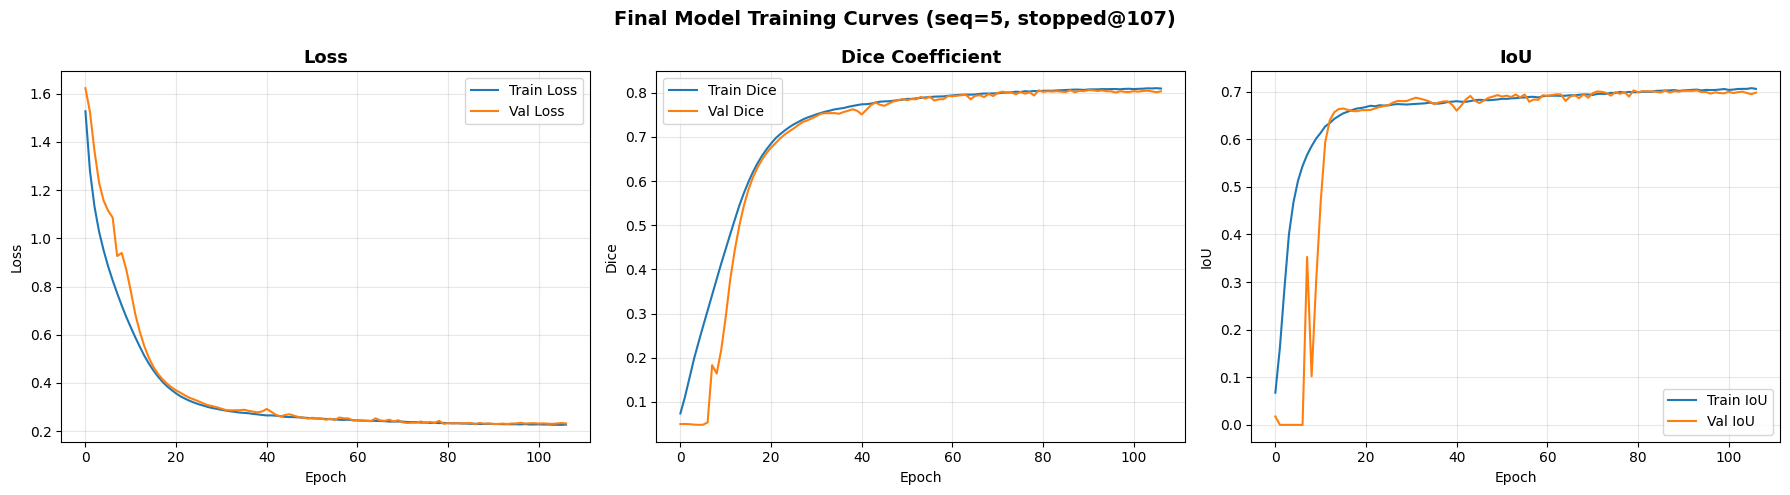

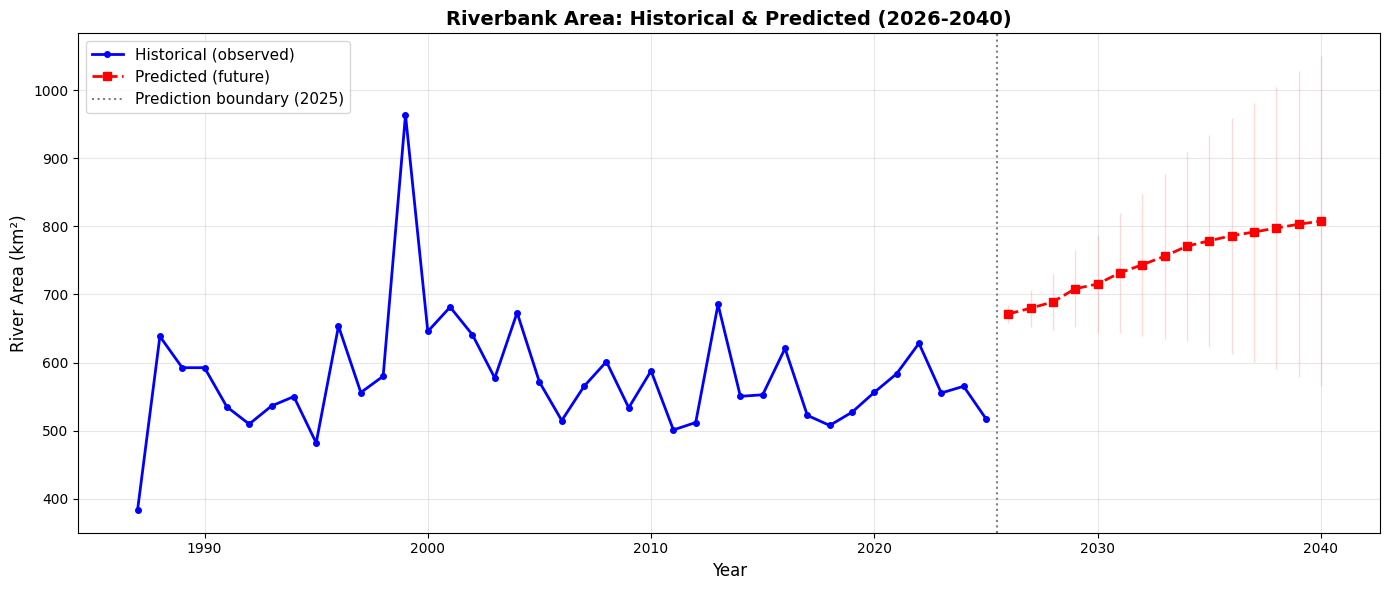

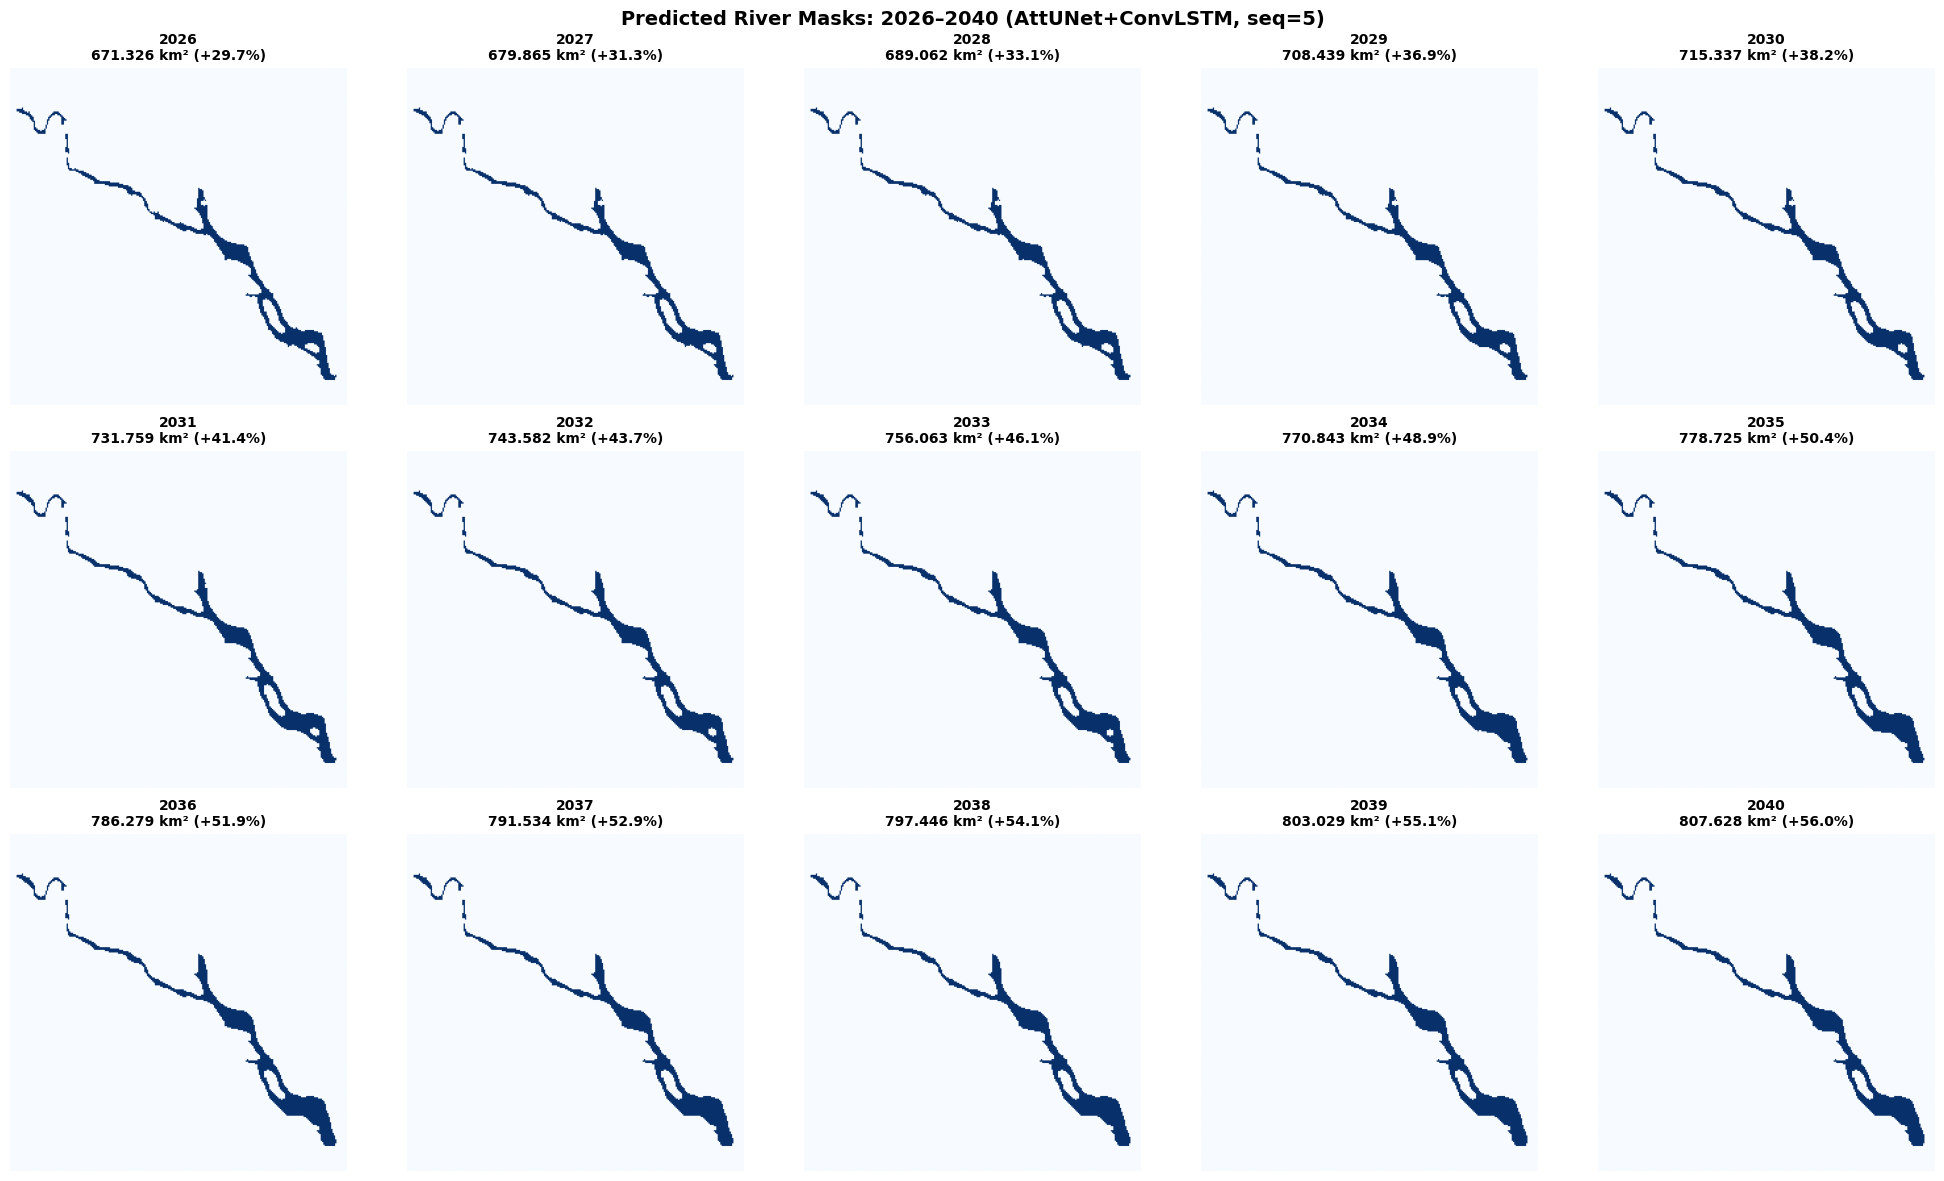

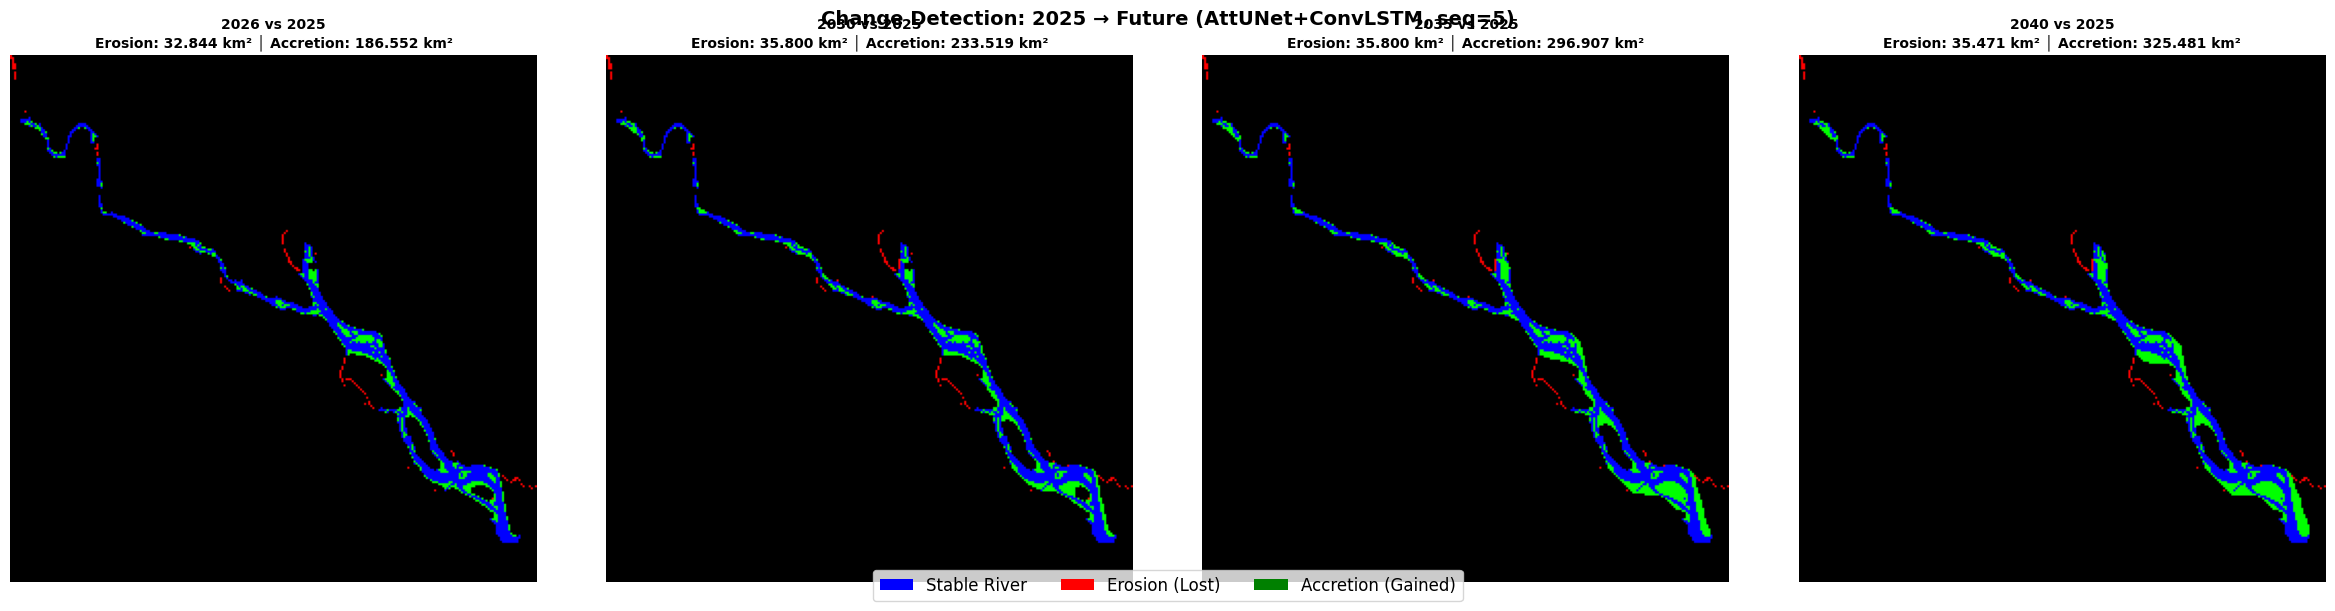

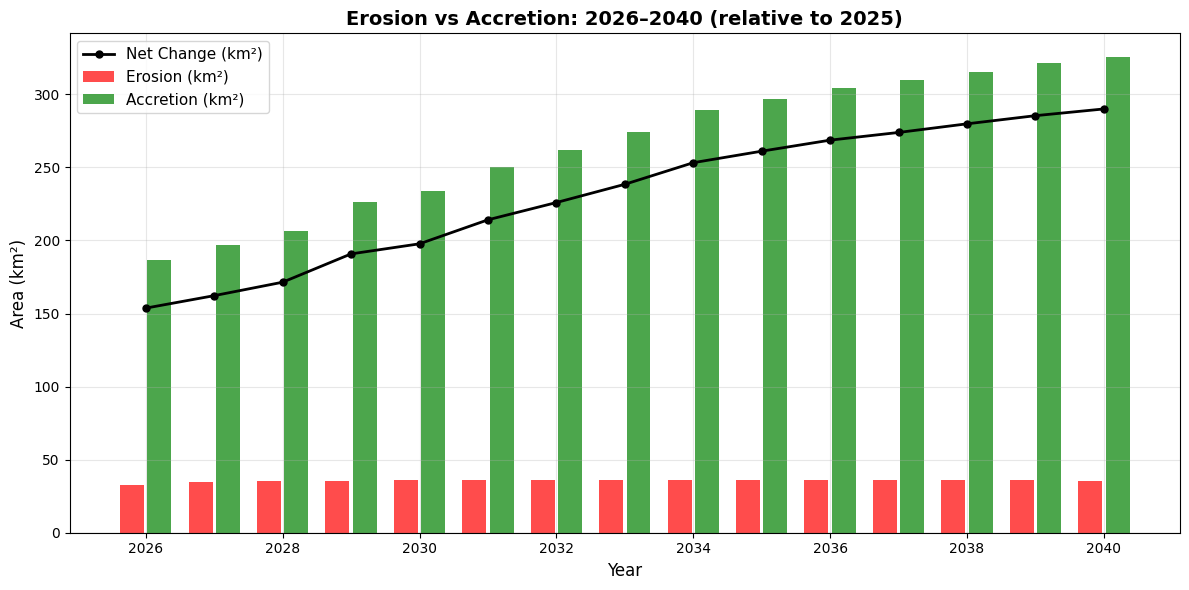

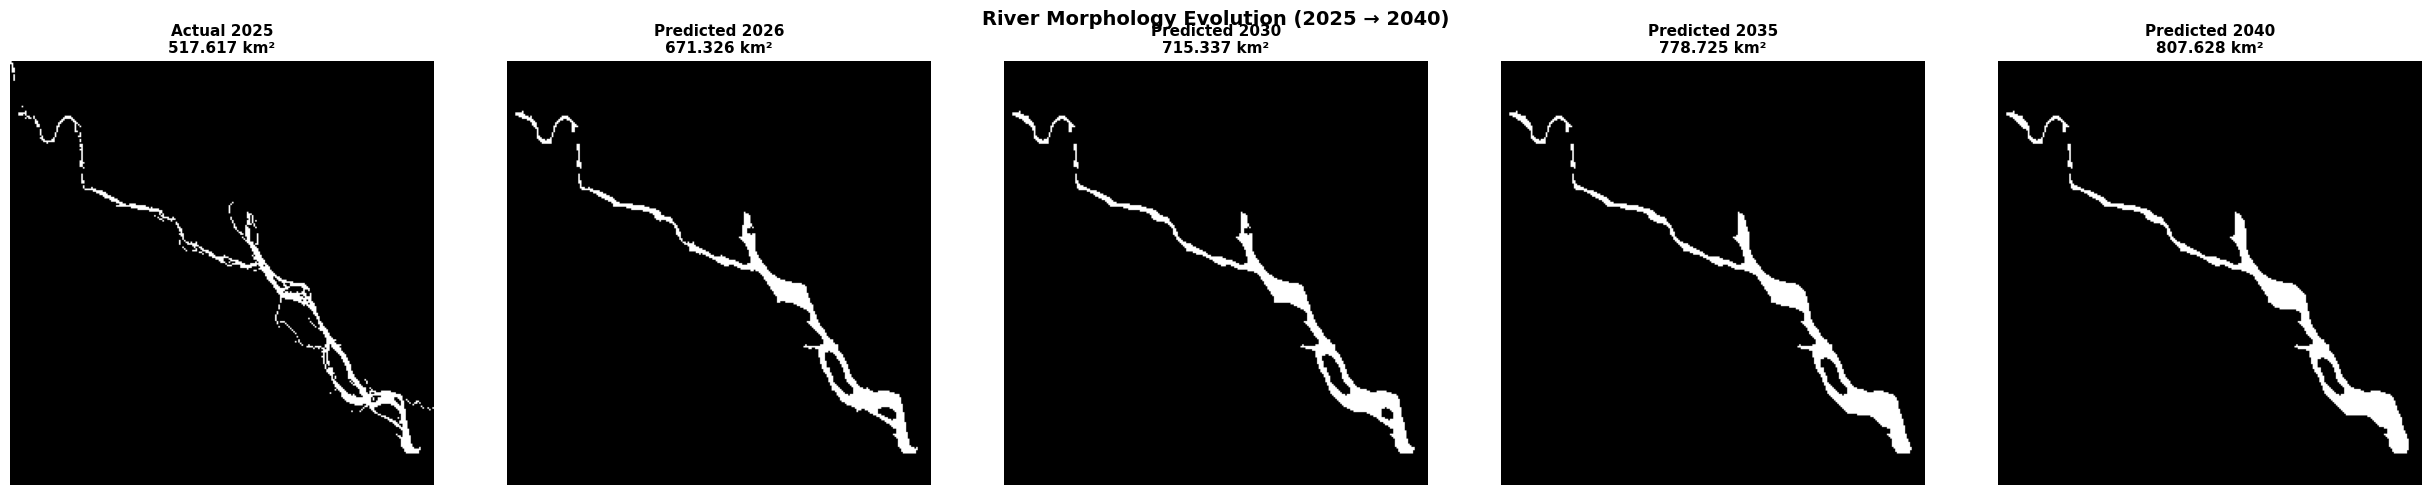

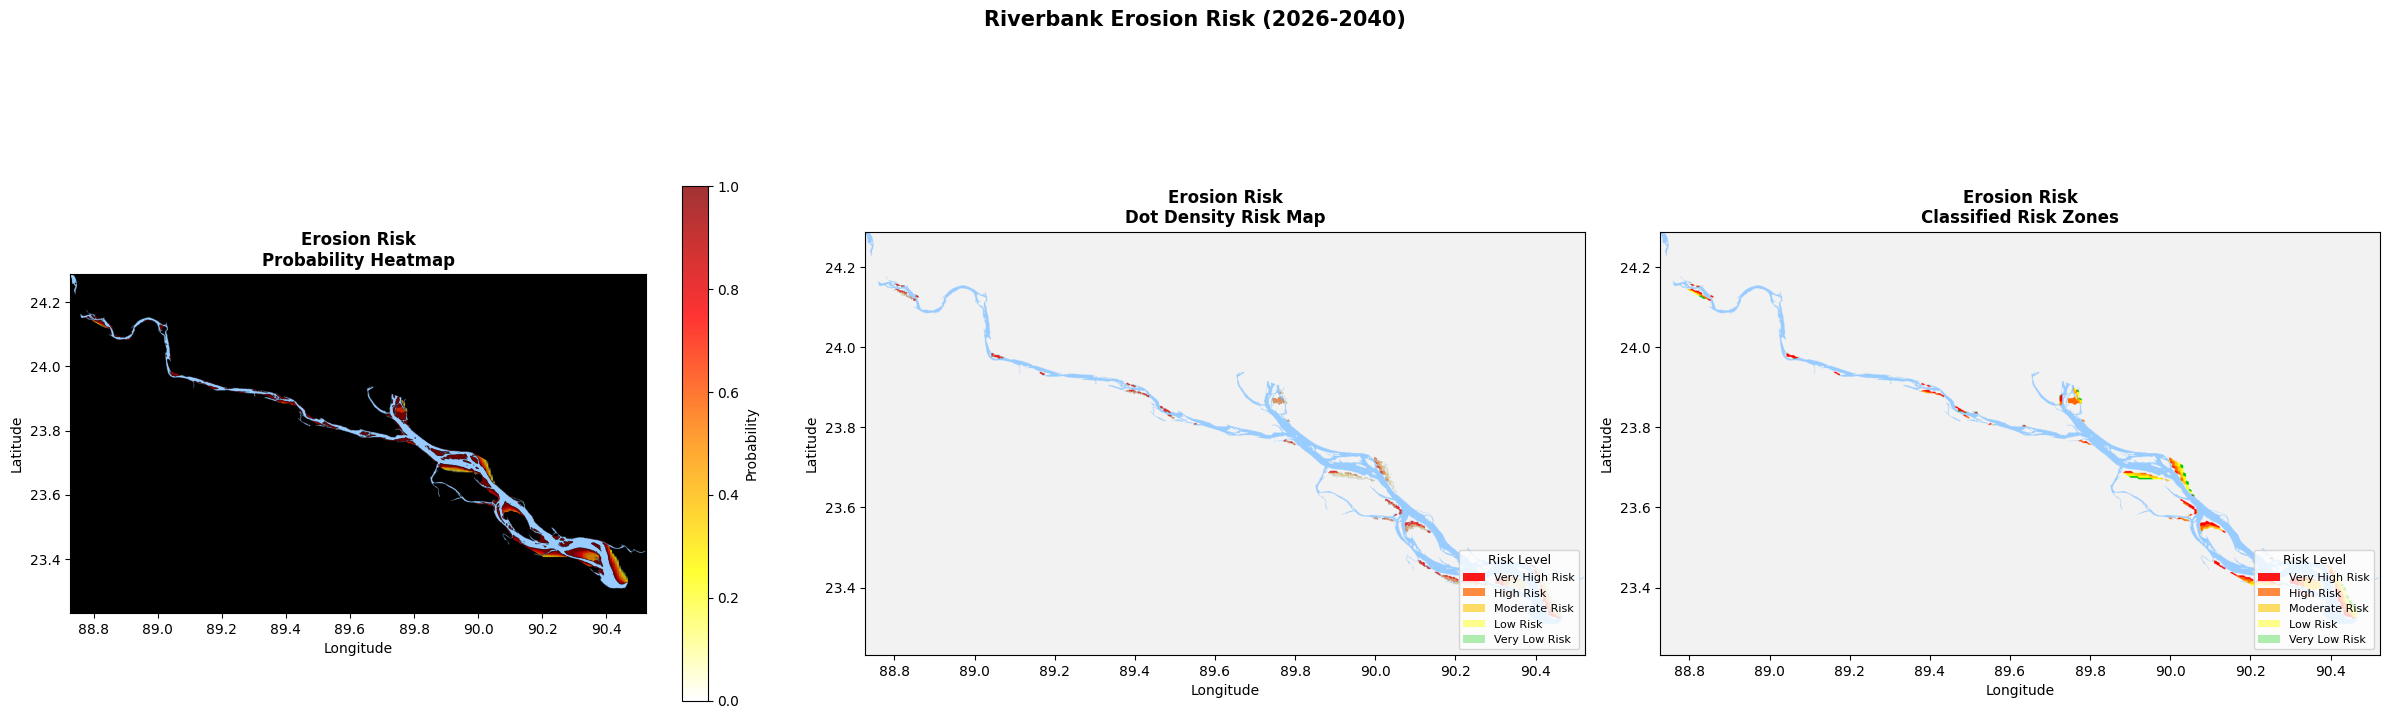

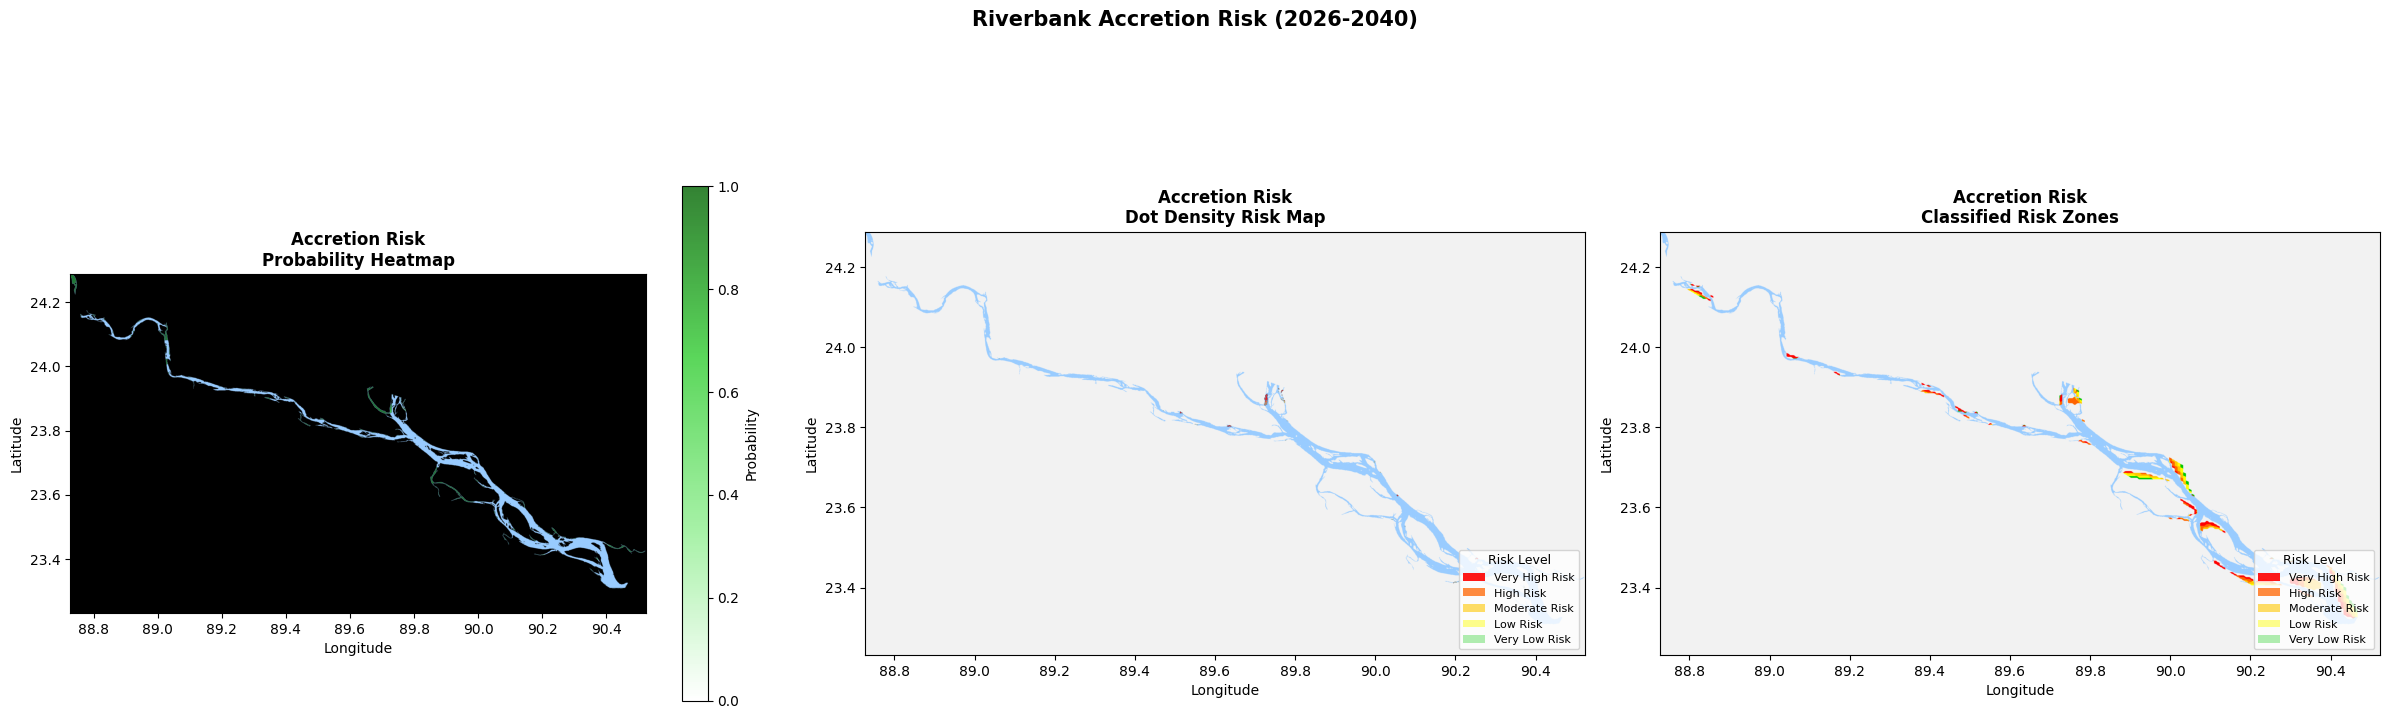

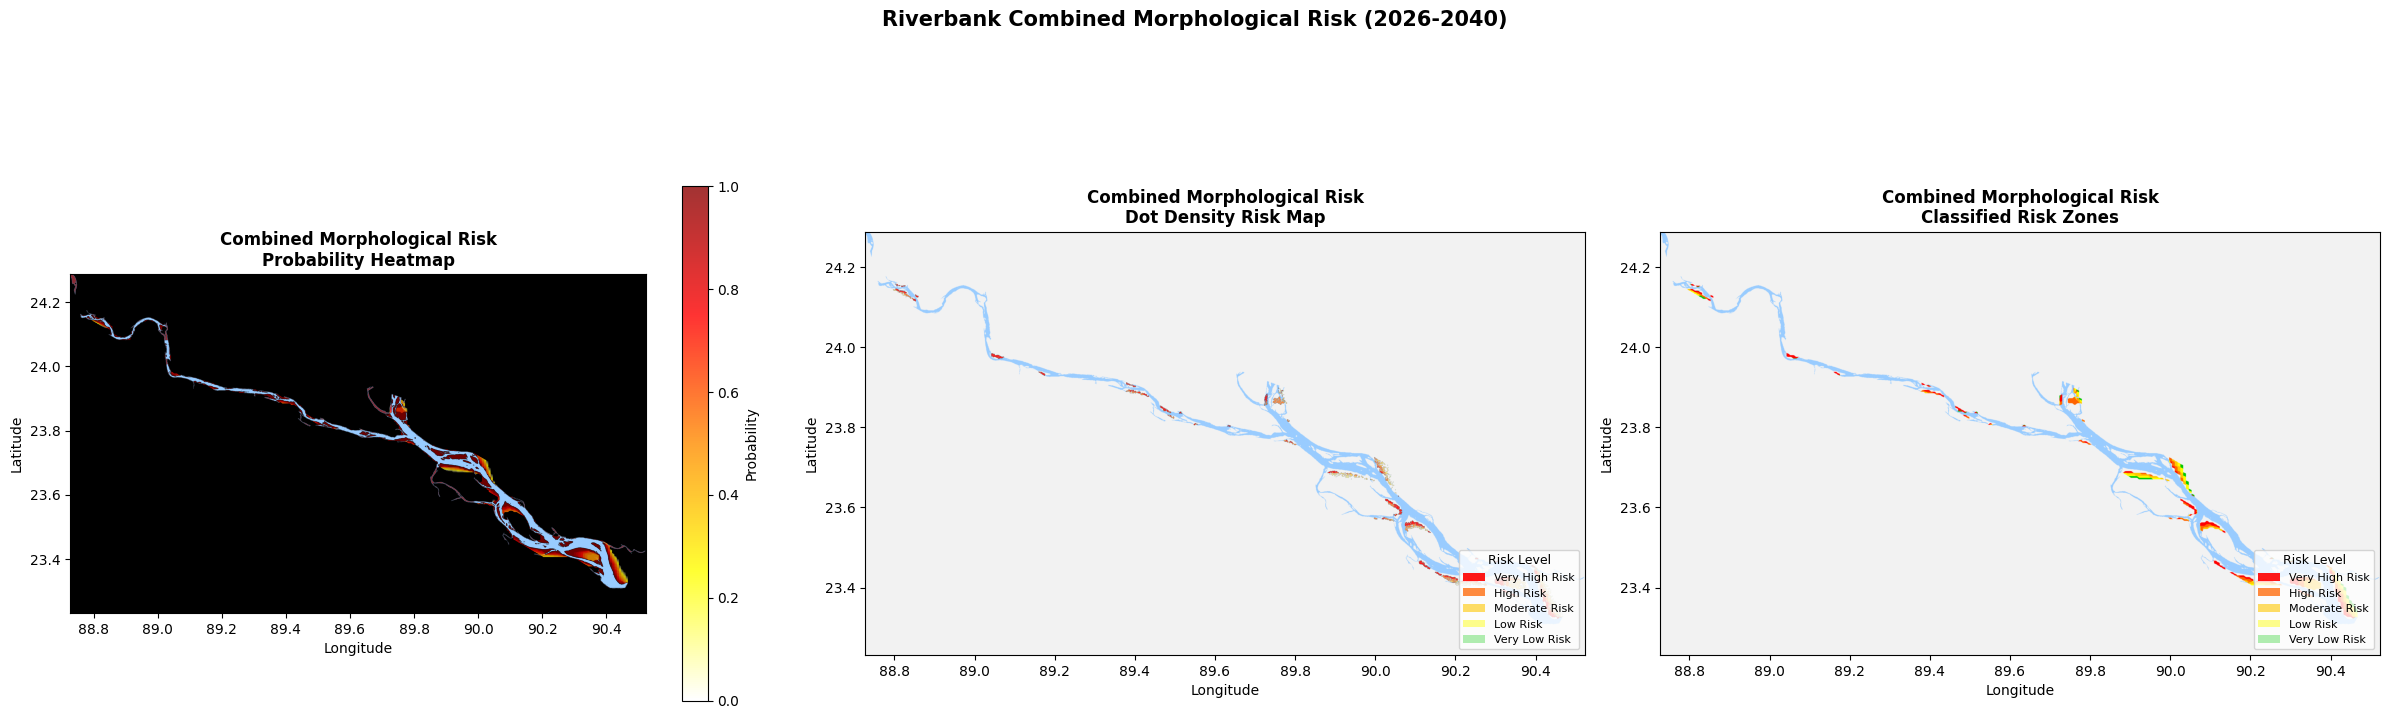

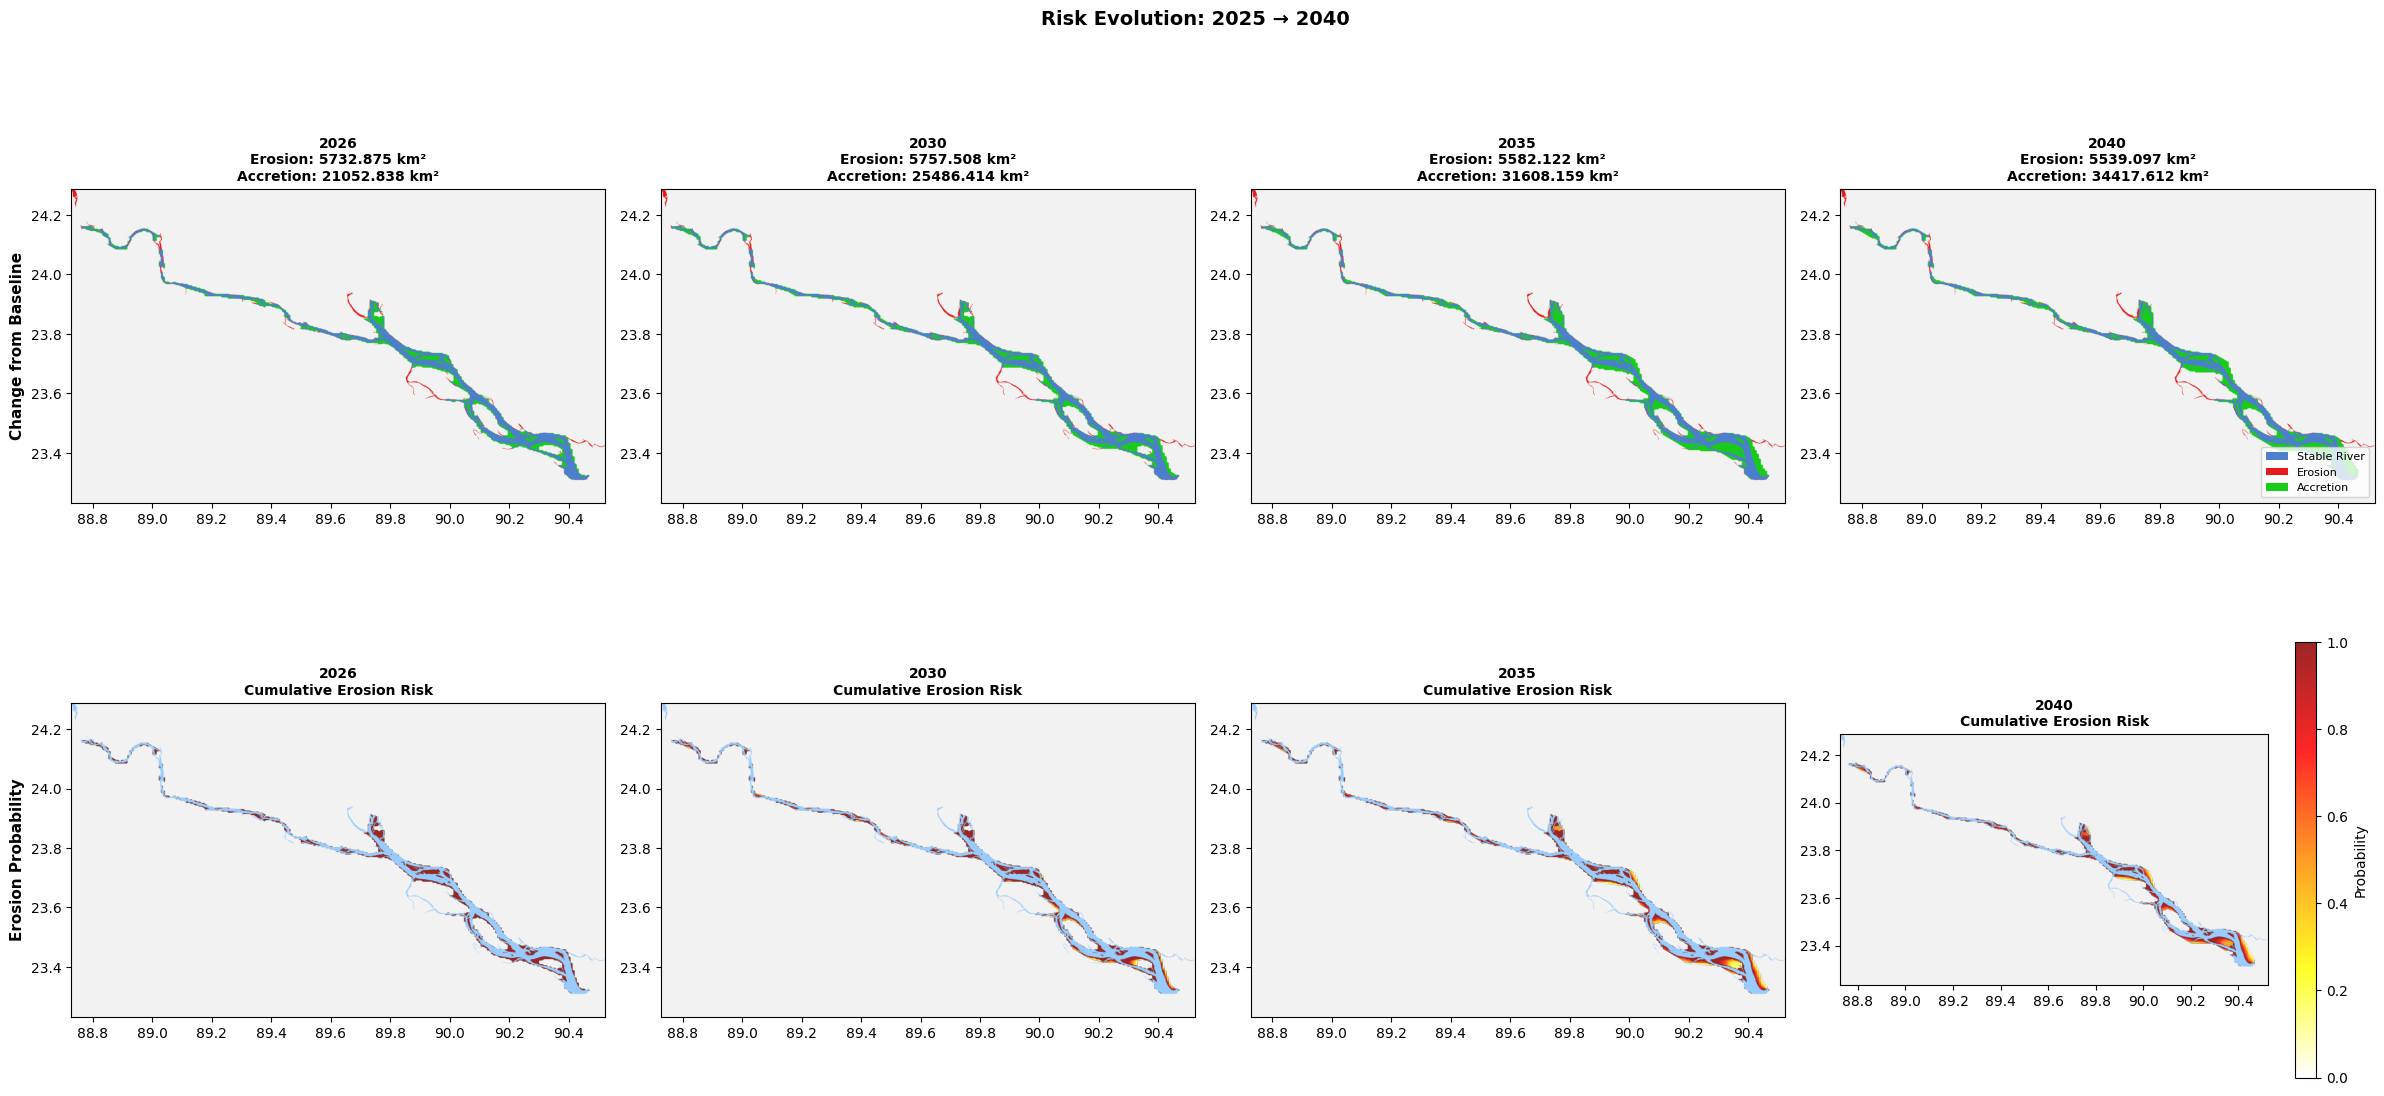

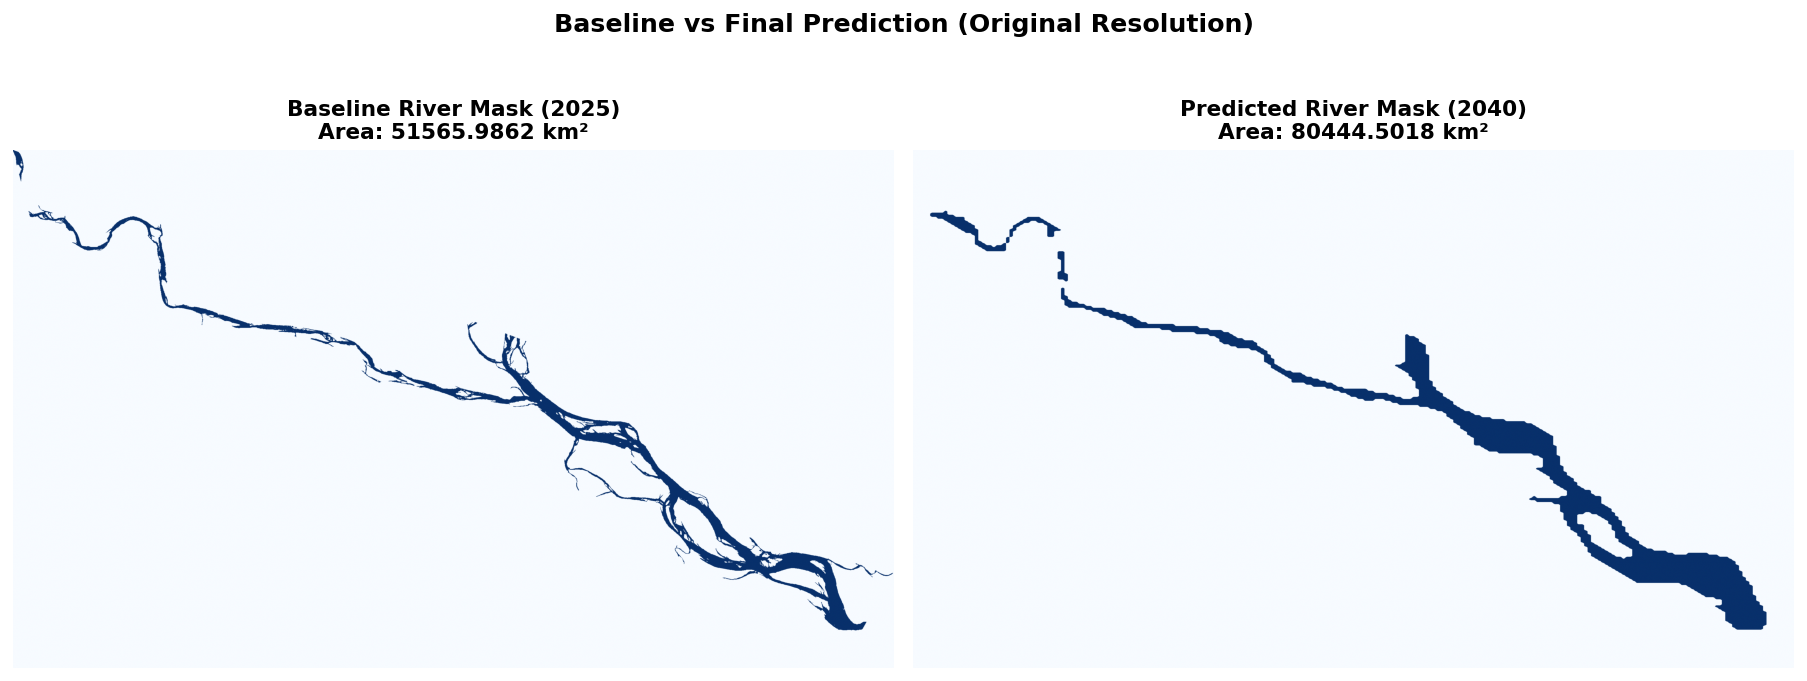


  2. EROSION PROBABILITY HEATMAP


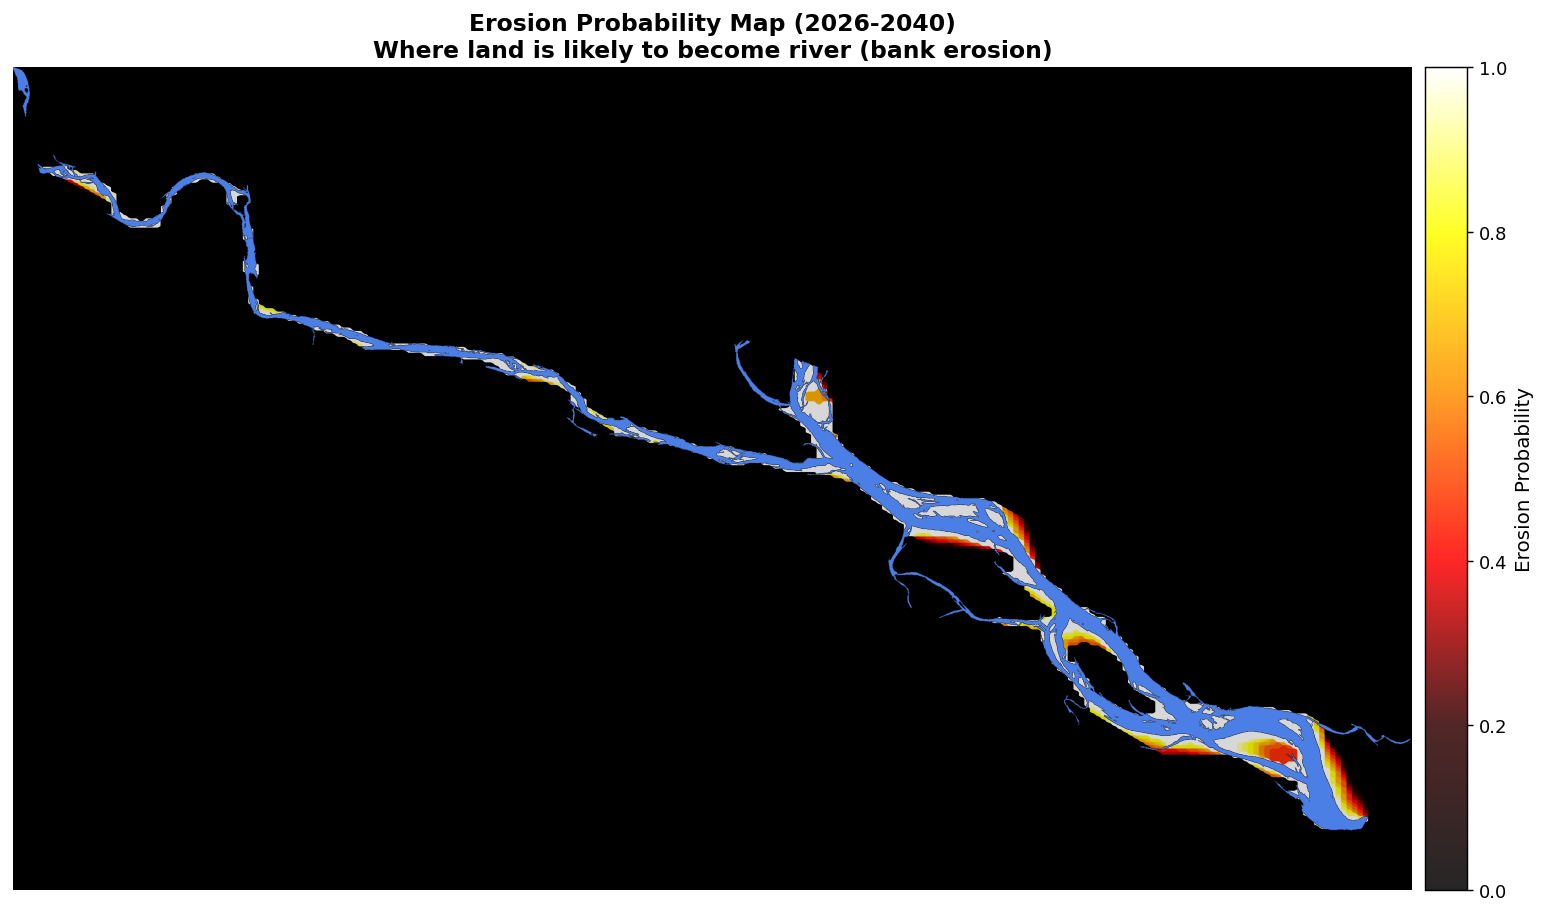


  3. ACCRETION PROBABILITY HEATMAP


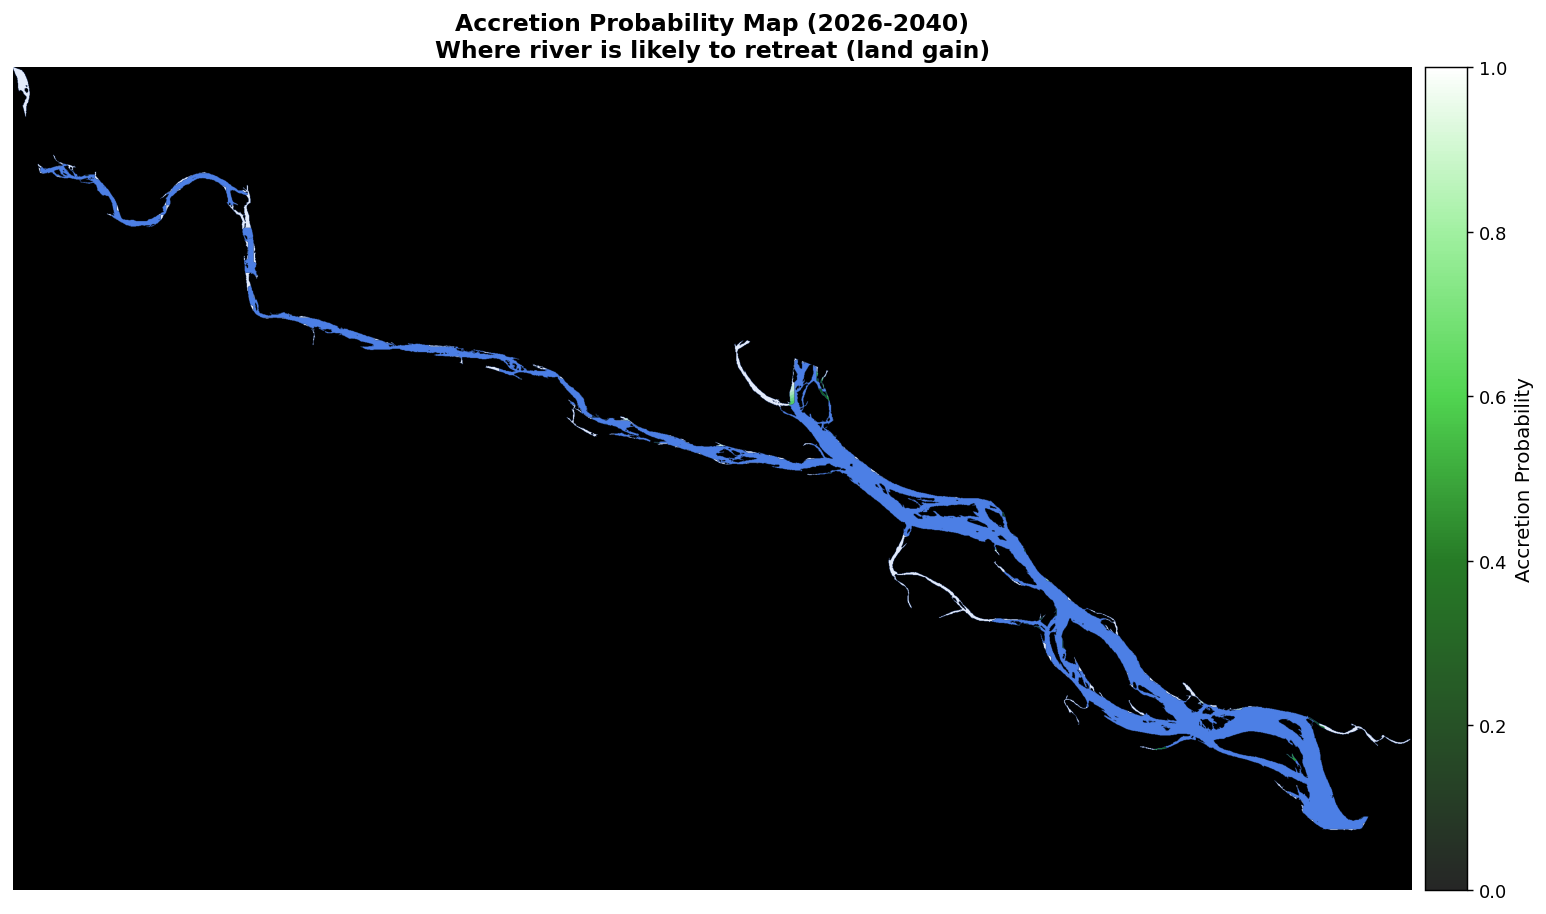


  4. COMBINED MORPHOLOGICAL RISK HEATMAP


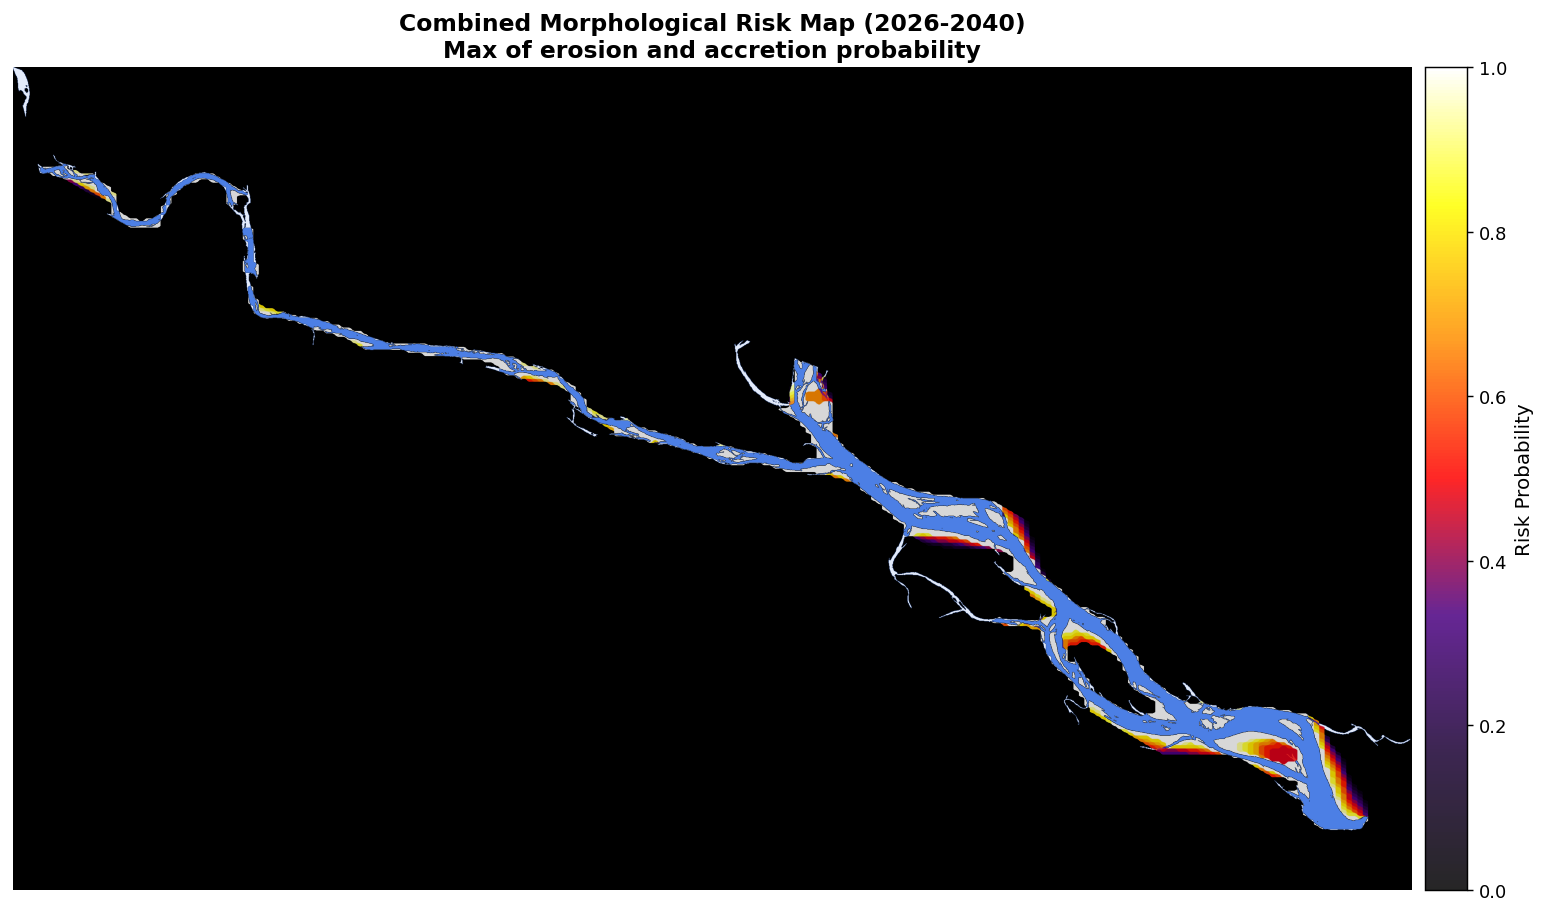


  5. DOT DENSITY RISK MAPS


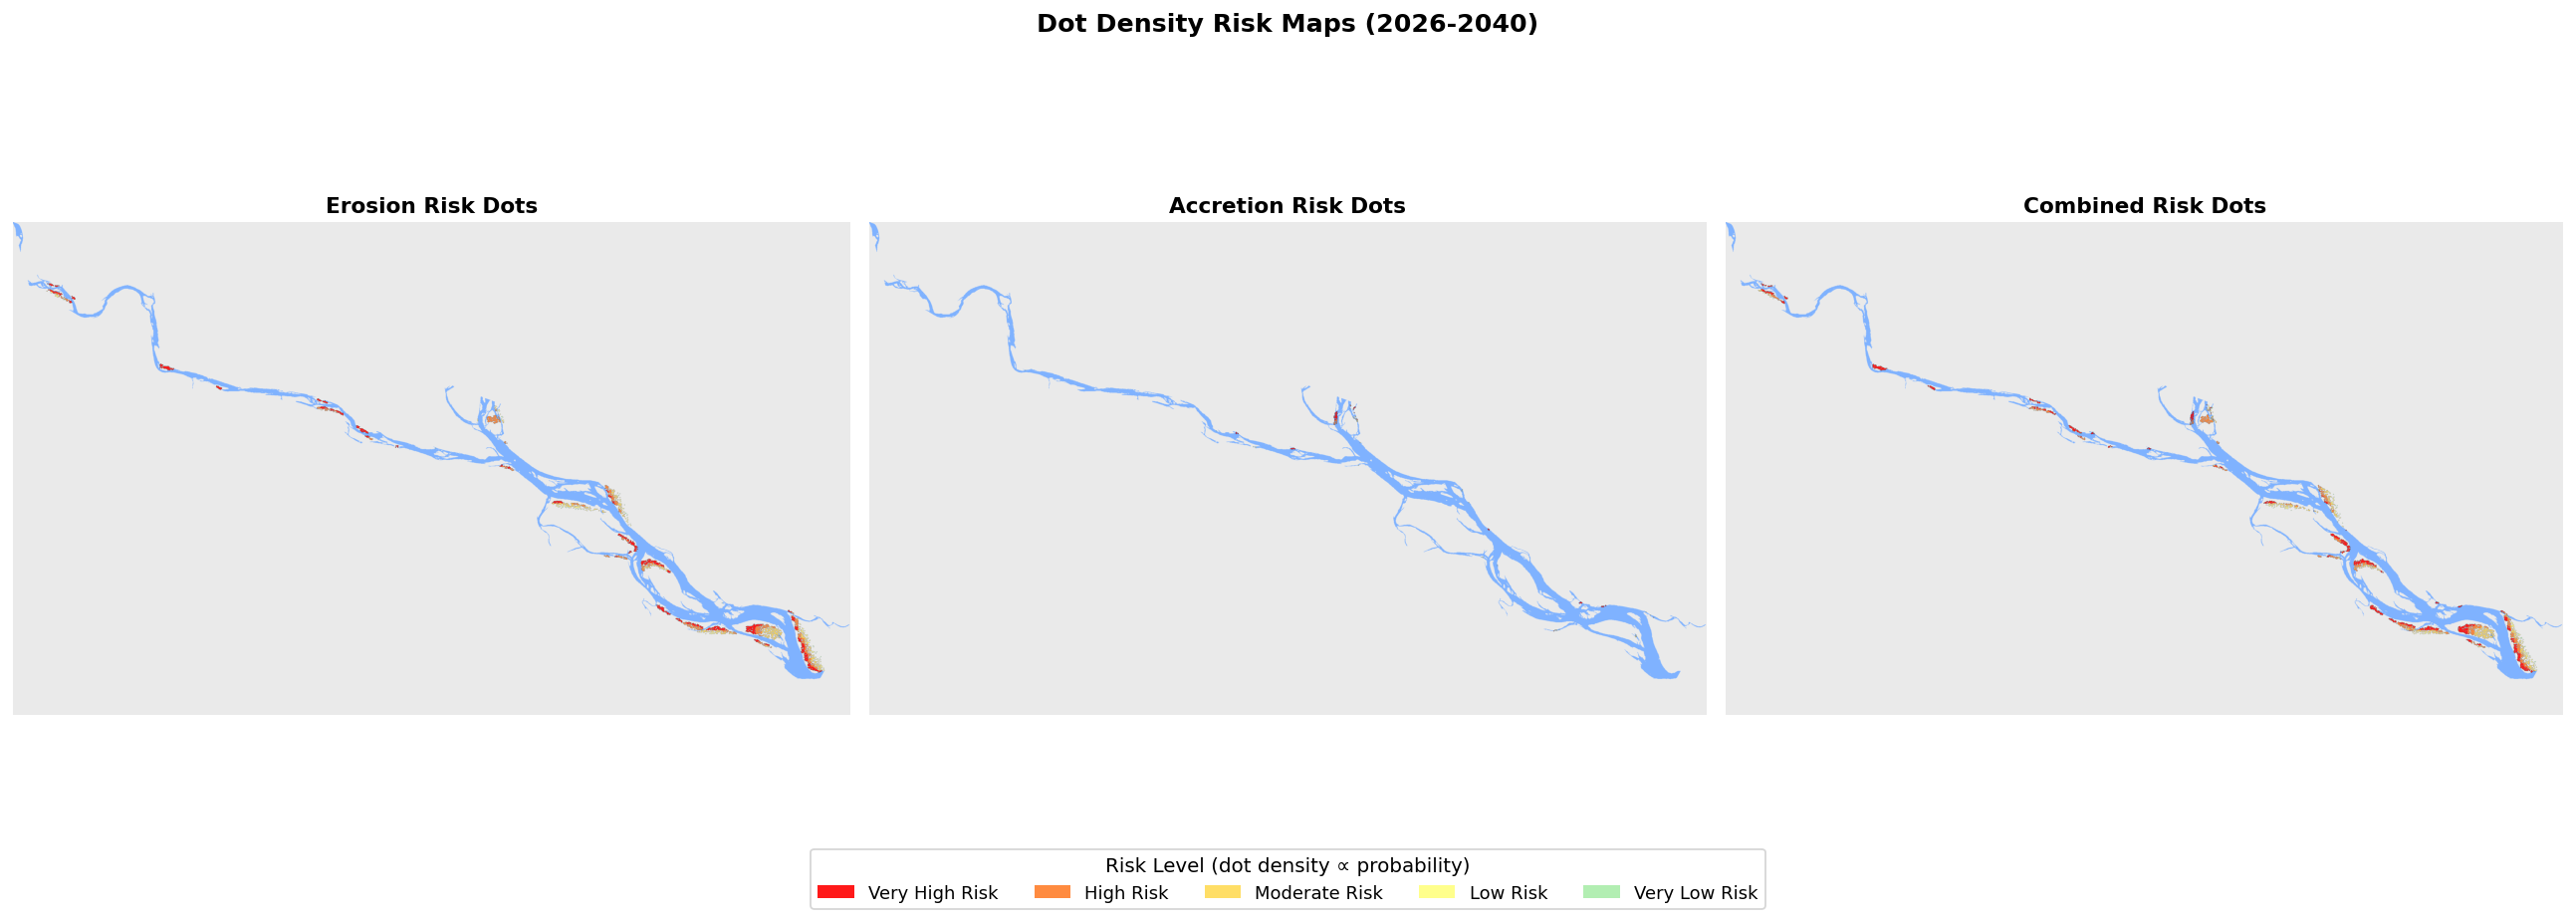


  6. CLASSIFIED RISK ZONES


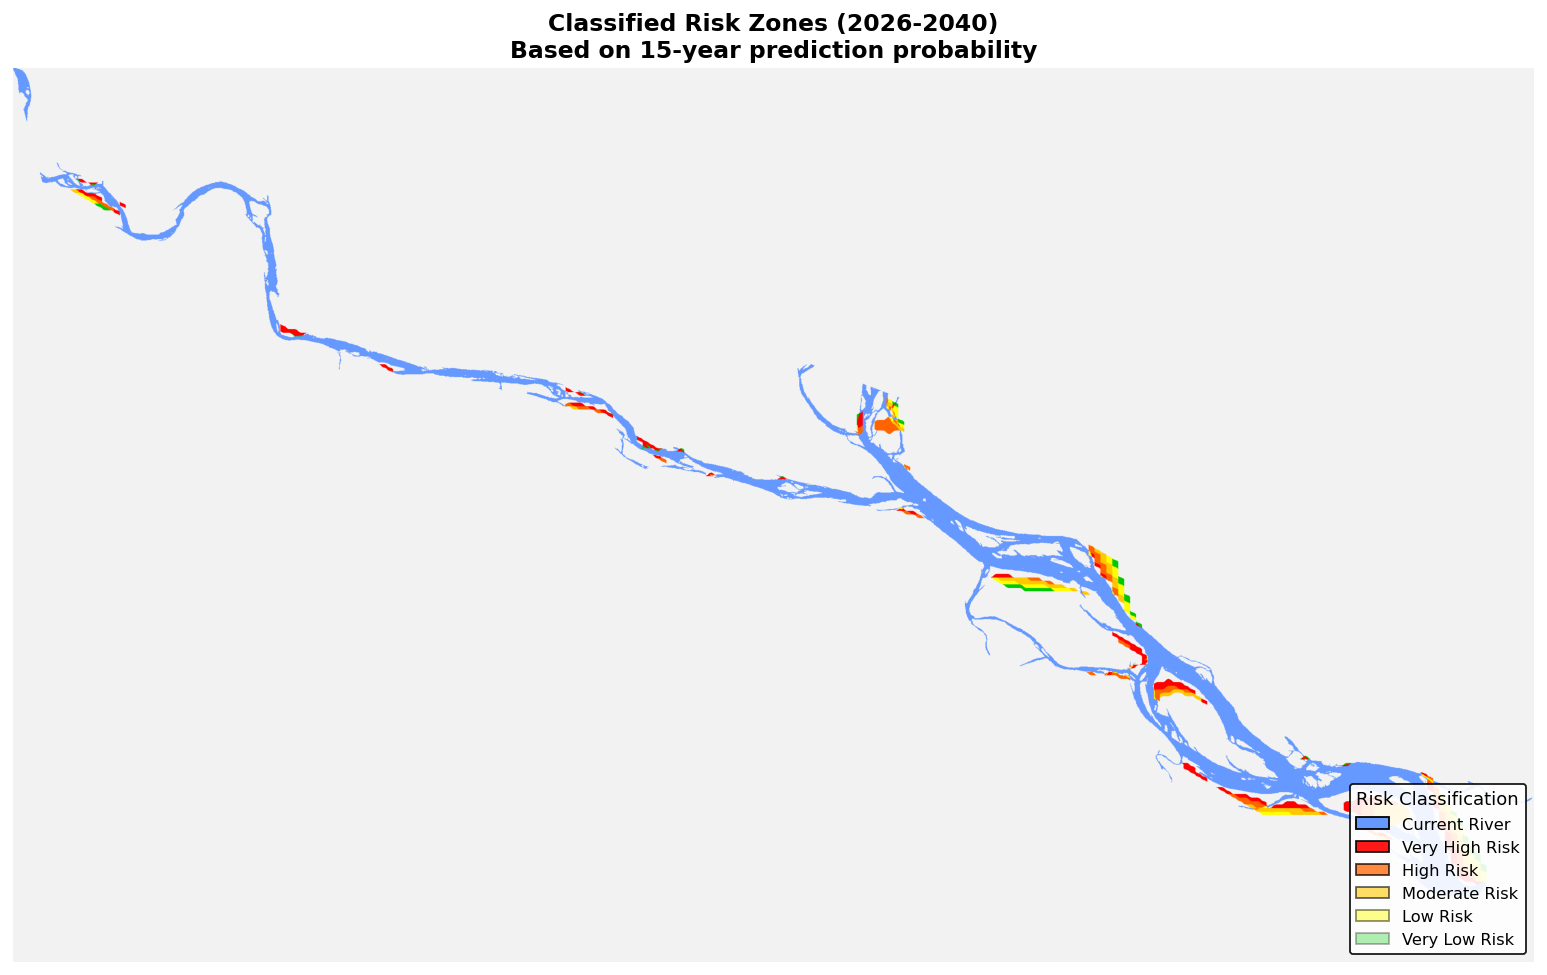


  7. EROSION vs ACCRETION SIDE-BY-SIDE


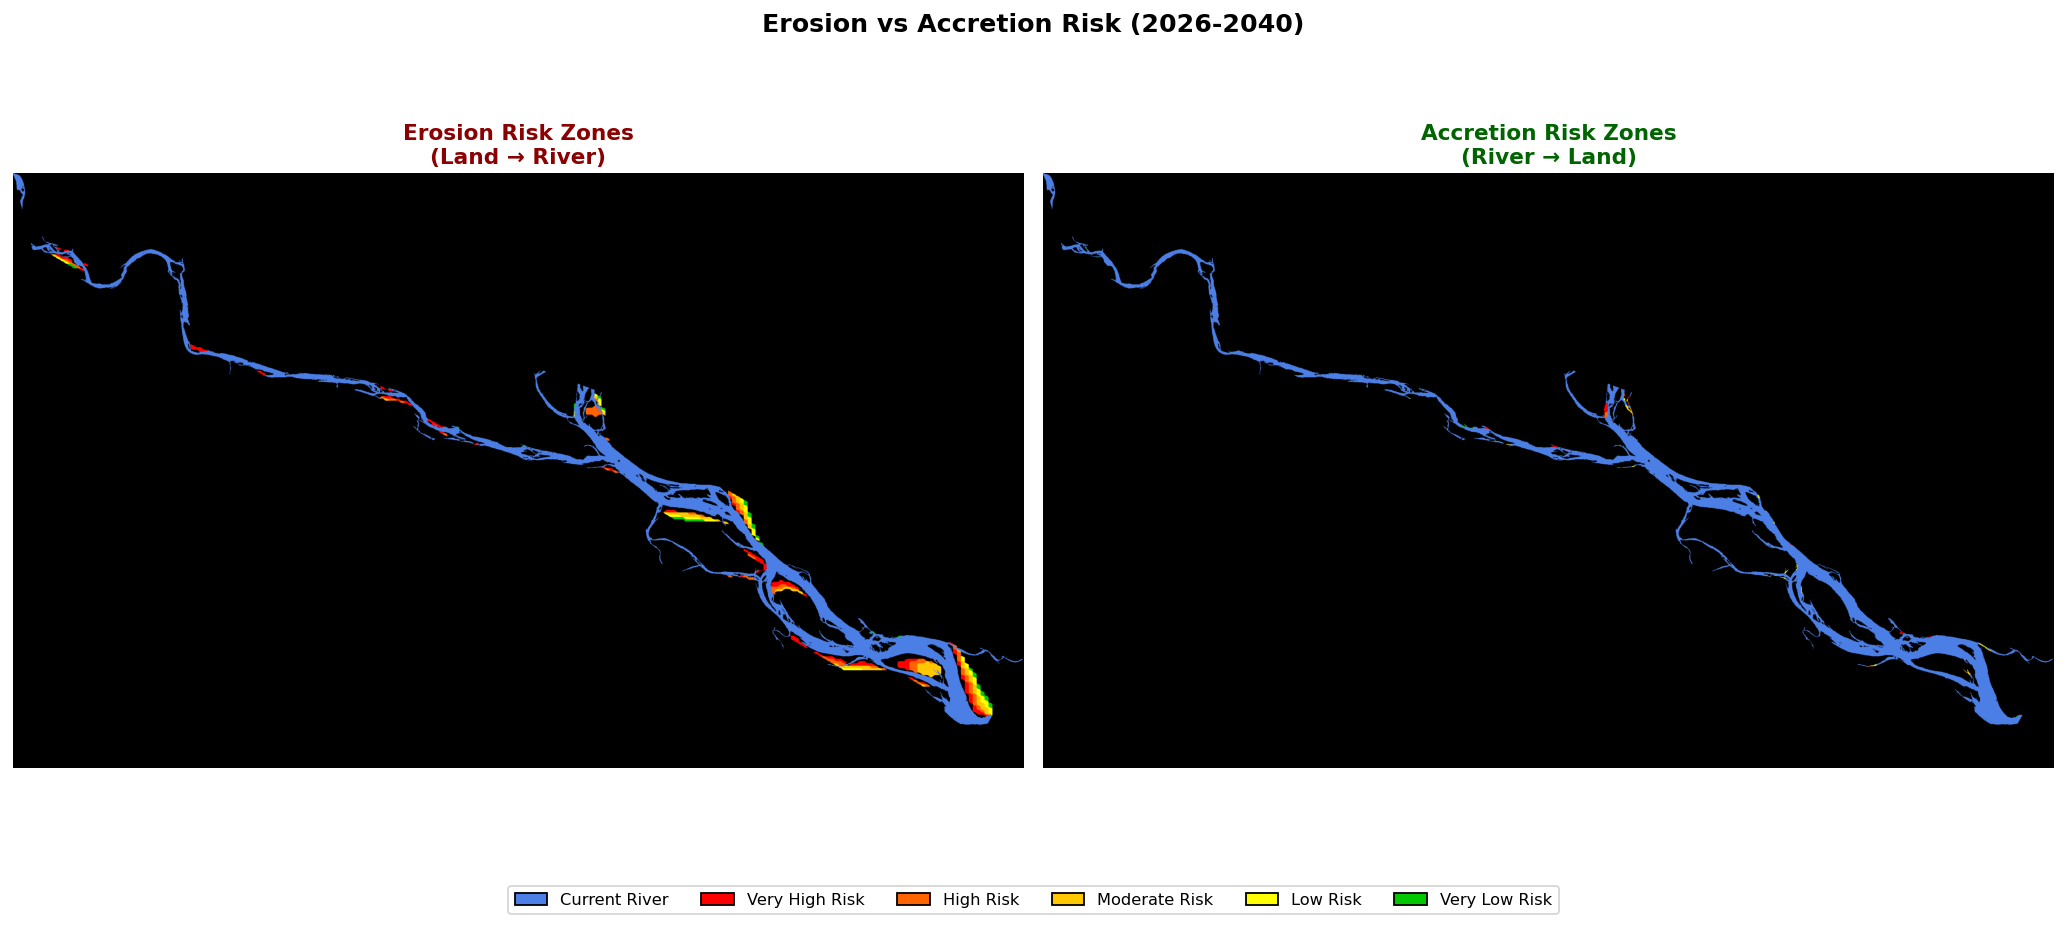


  8. YEAR-BY-YEAR CHANGE MAPS


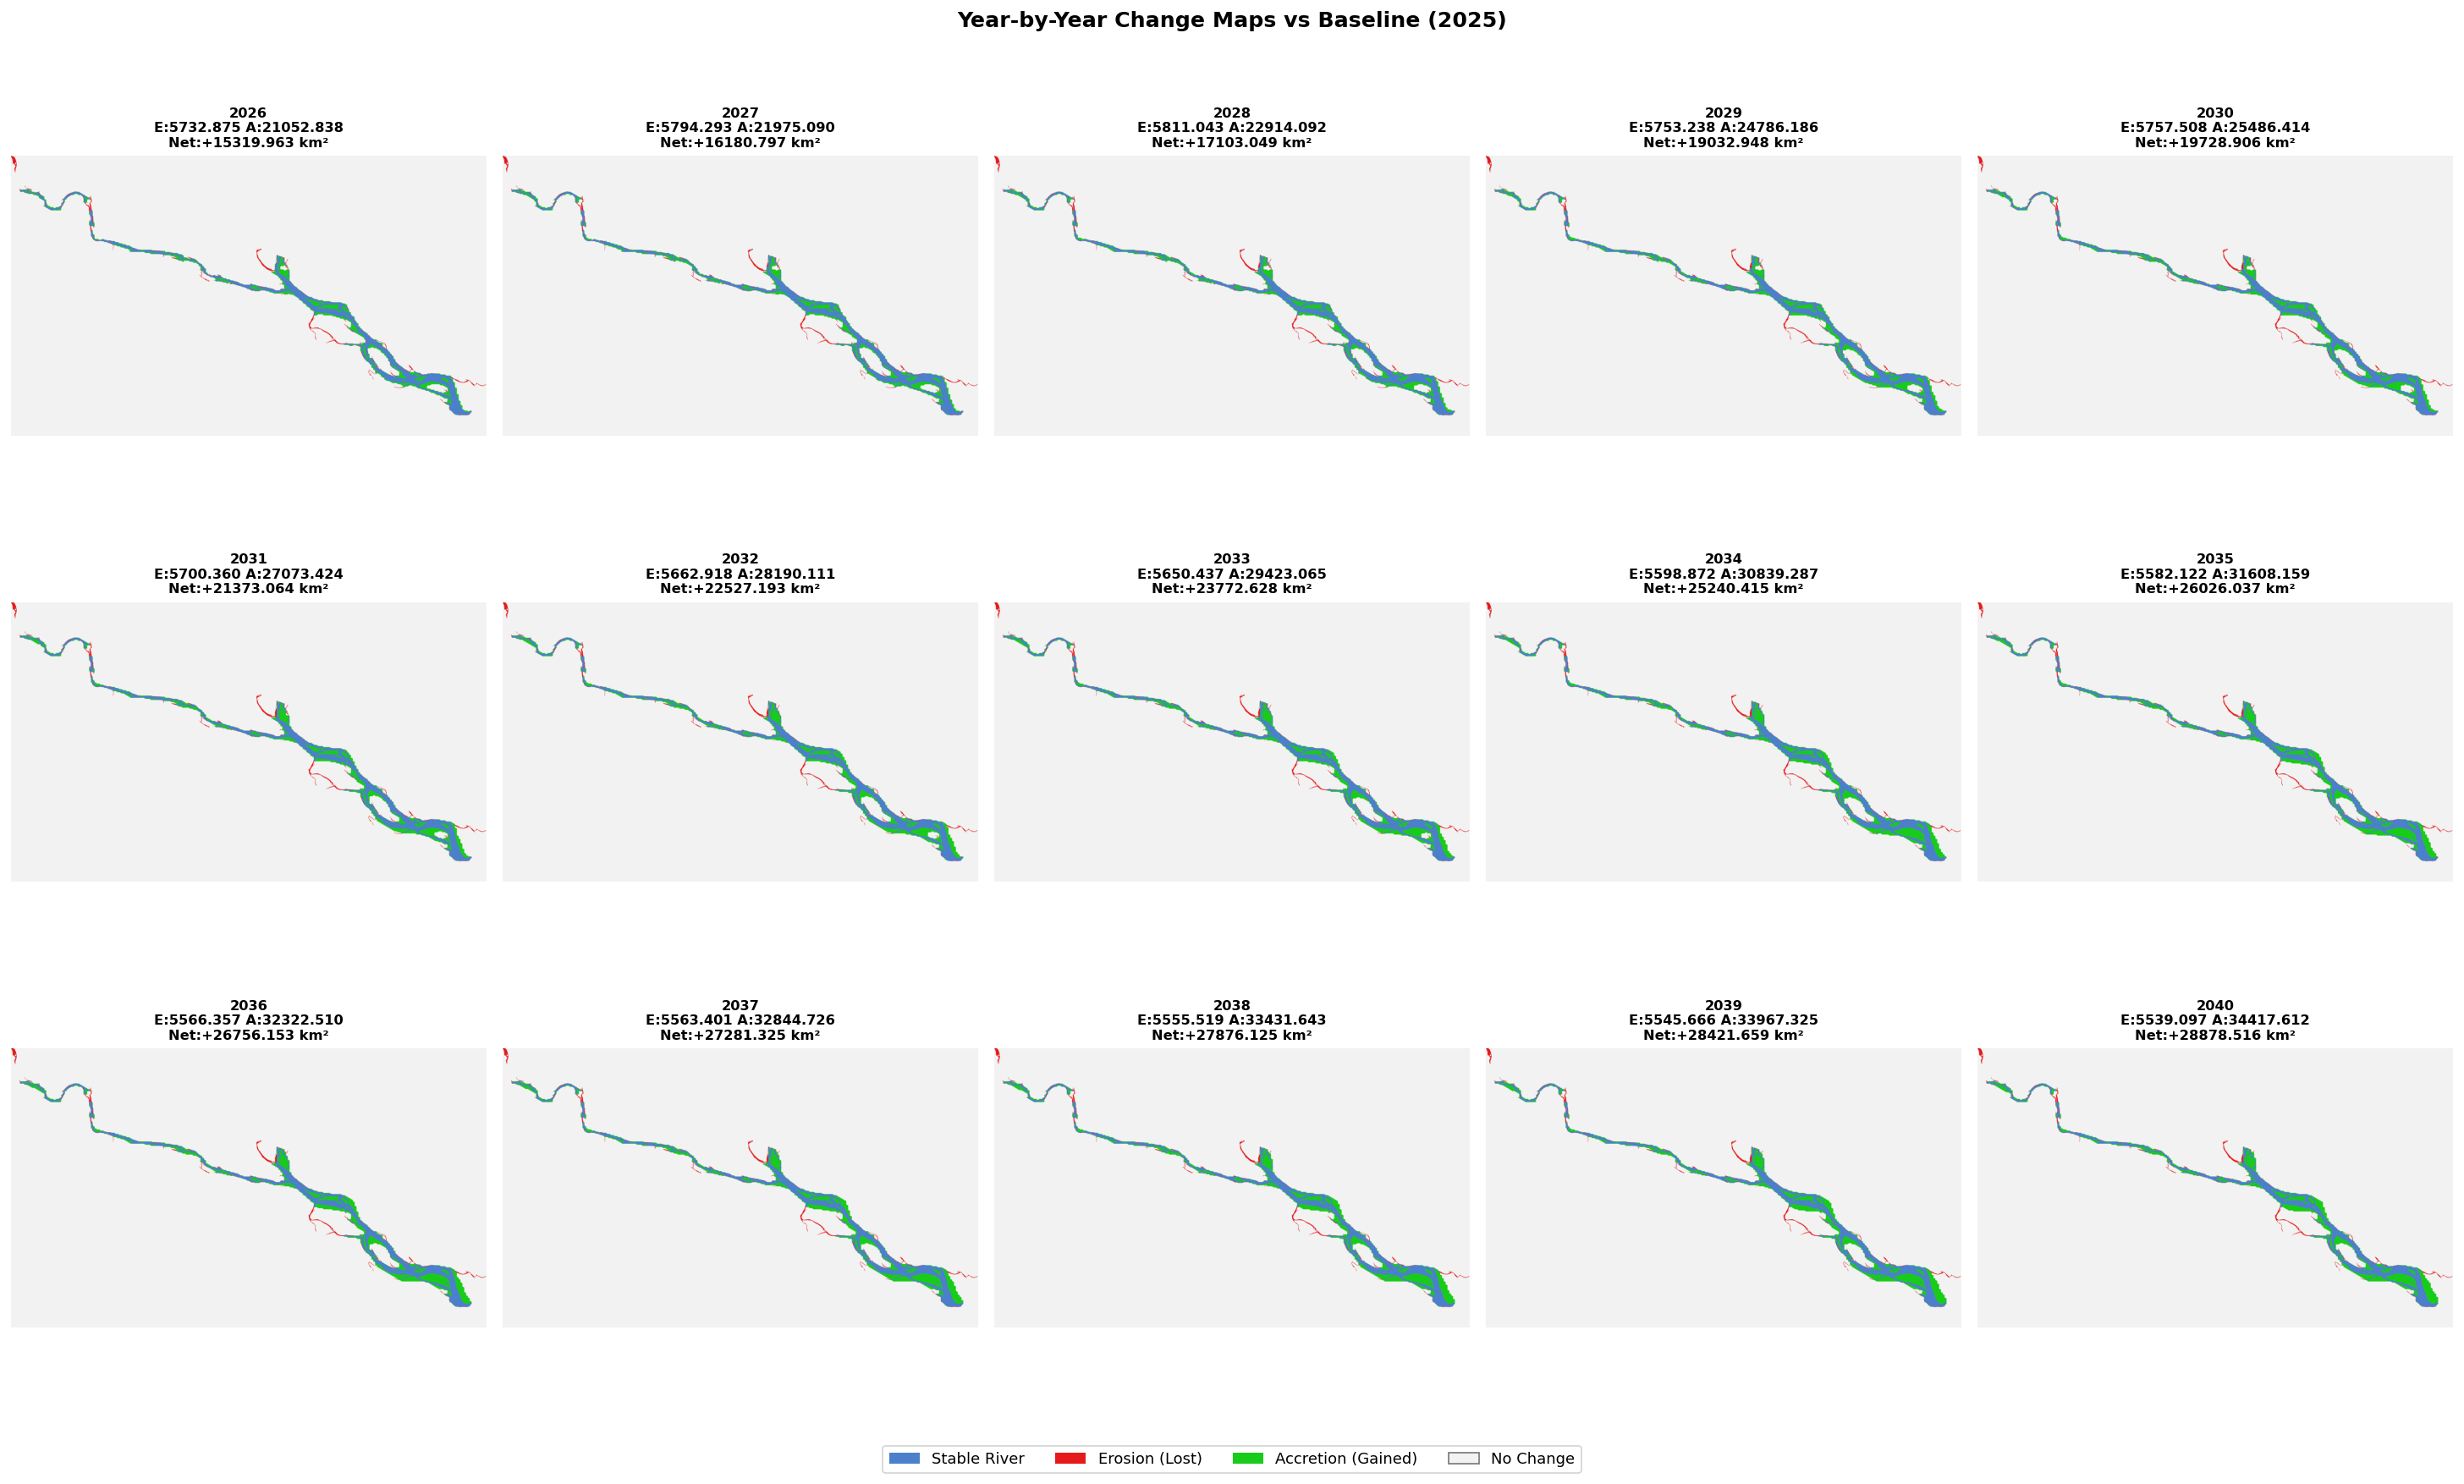


  9. CUMULATIVE EROSION RISK EVOLUTION


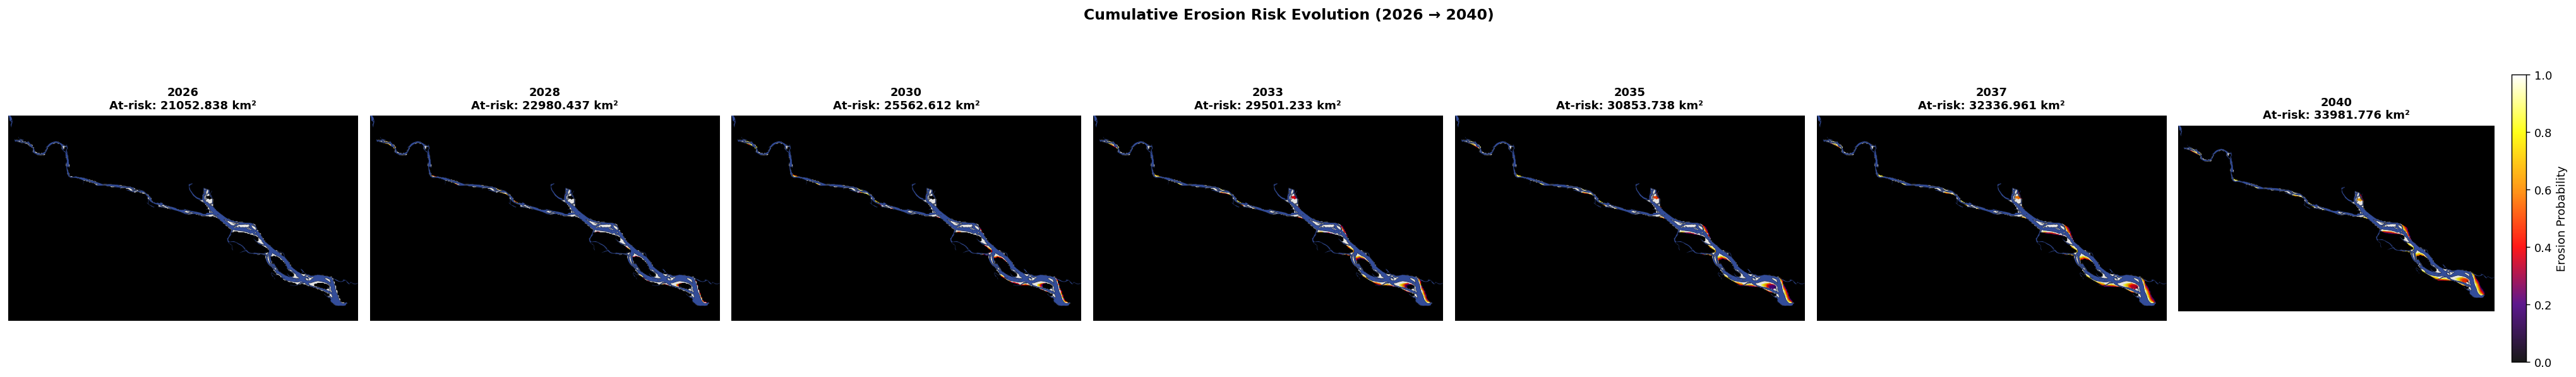


  10. RIVER FREQUENCY / STABILITY MAP


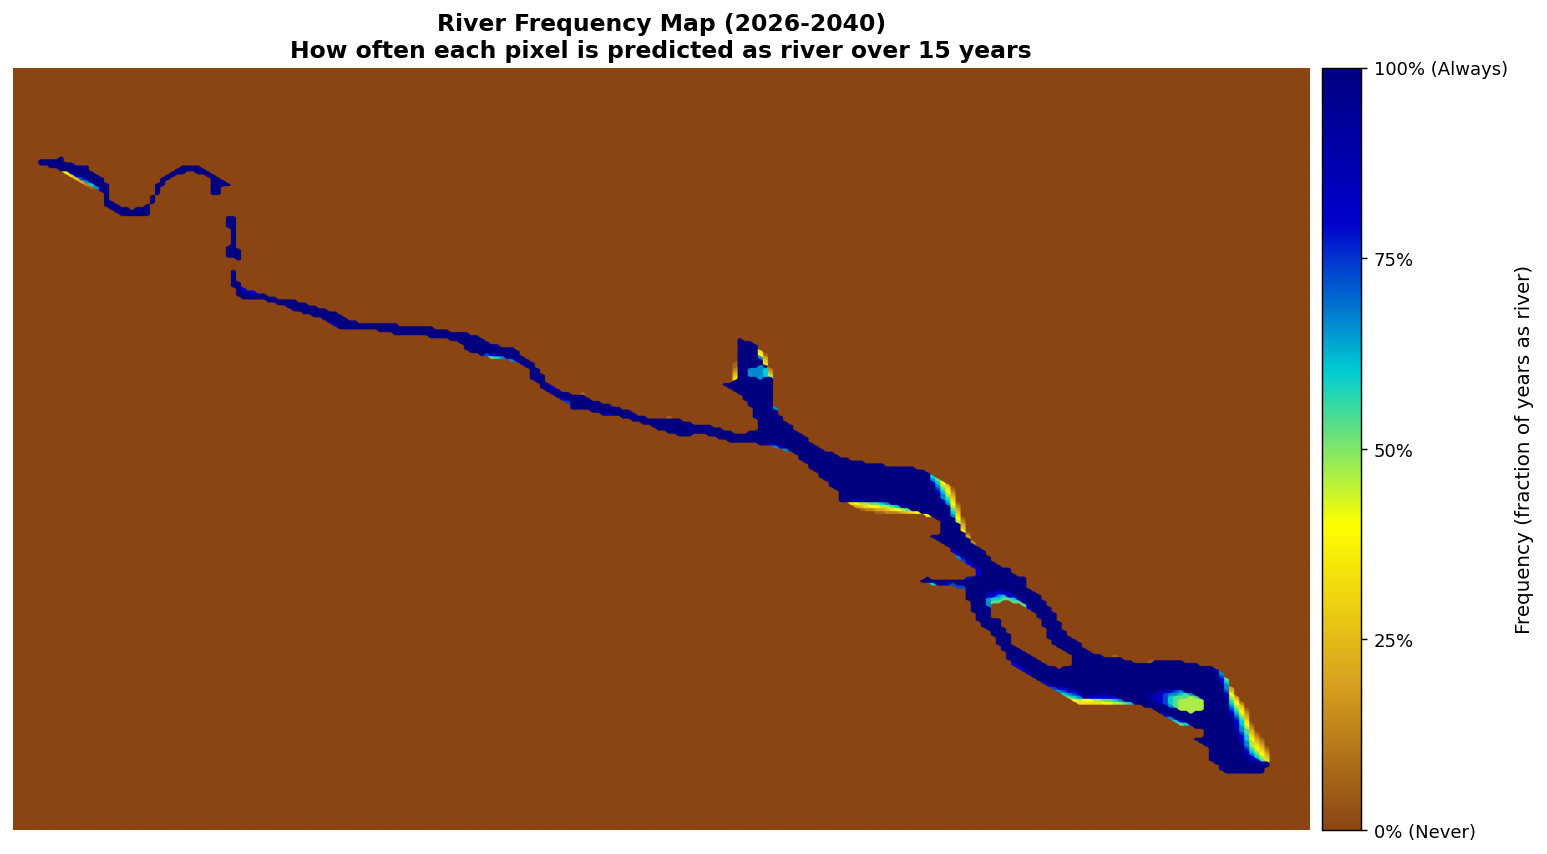


  11. PROBABILITY DOTS OVERLAID ON BASELINE


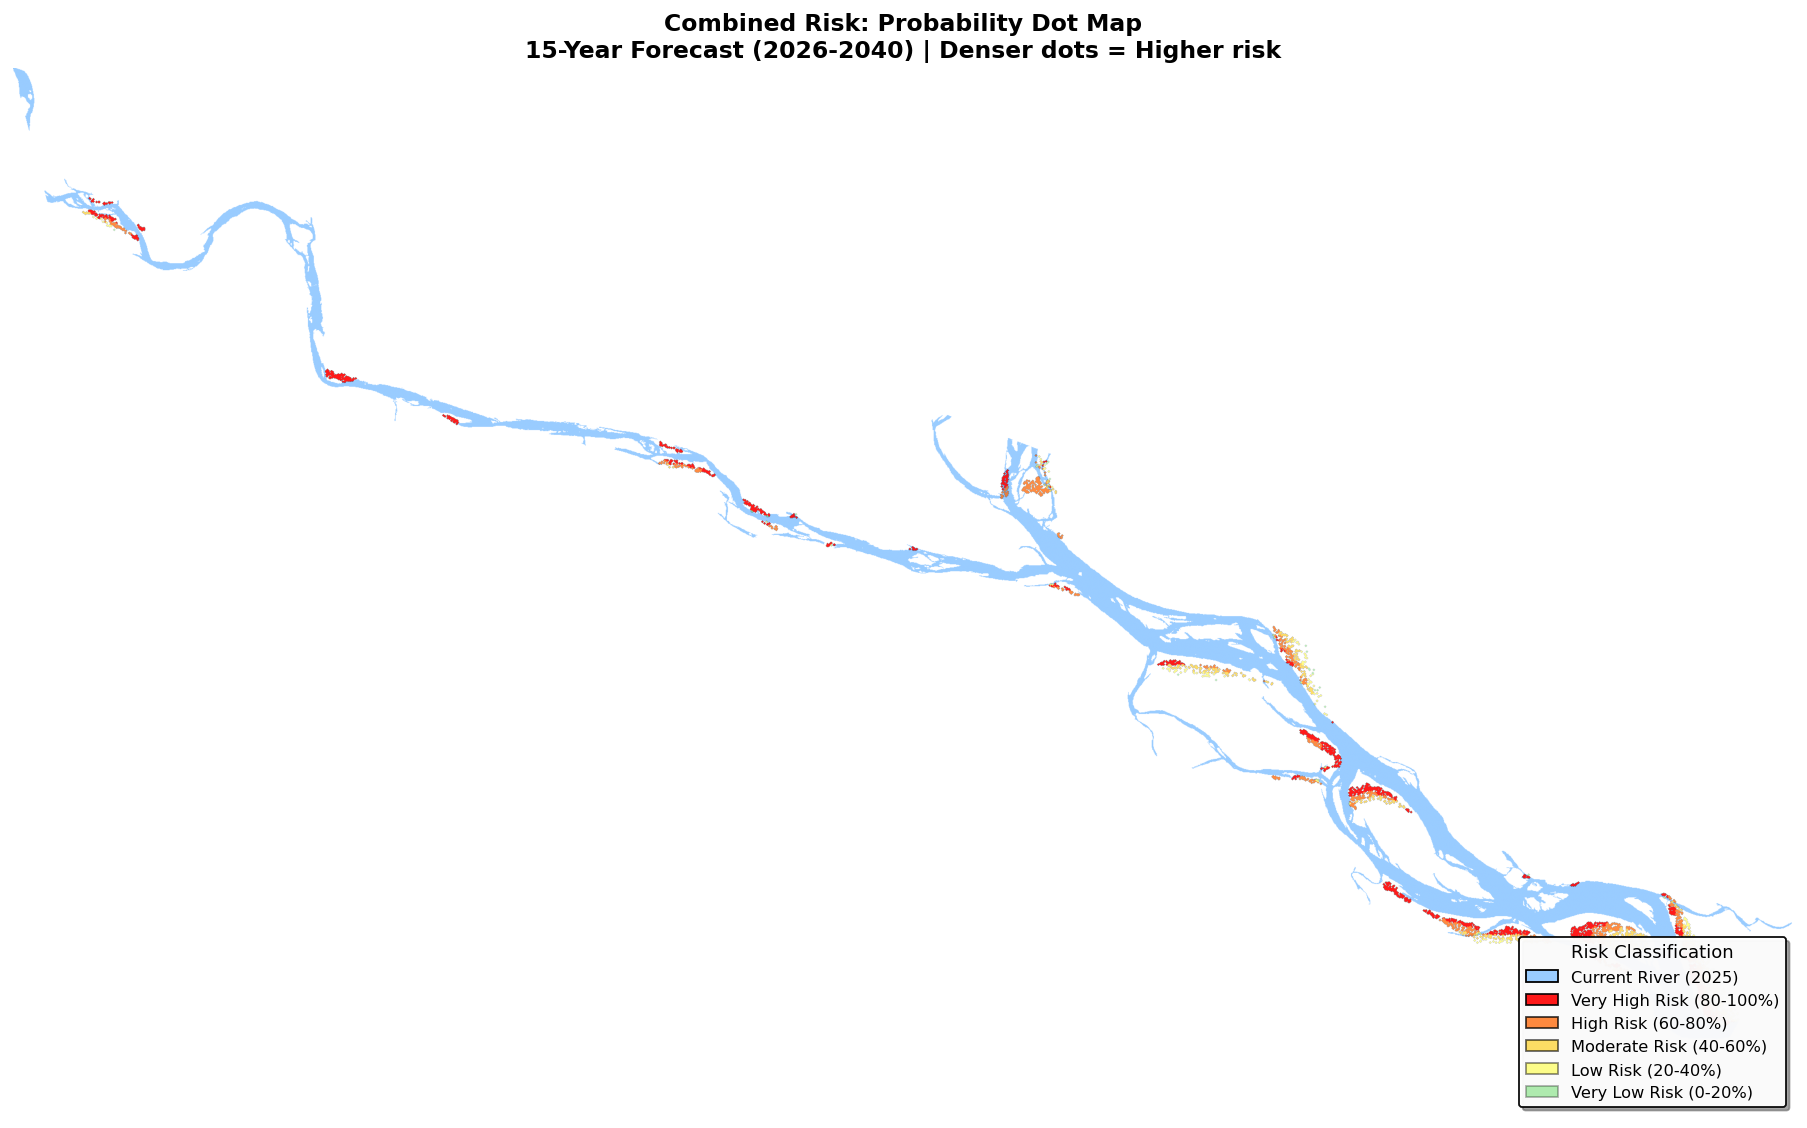


  12. RISK ZONE STATISTICS

  Risk Level           │     Pixels │   Area (km²) │ % of Total
  ────────────────────────────────────────────────────────────
  Very High Risk       │     12,211 │    4010.5491 │      28.3%
  High Risk            │     10,670 │    3504.4271 │      24.7%
  Moderate Risk        │     10,716 │    3519.5352 │      24.8%
  Low Risk             │      6,187 │    2032.0422 │      14.3%
  Very Low Risk        │      3,434 │    1127.8540 │       7.9%
  ────────────────────────────────────────────────────────────
  TOTAL RISK ZONE      │     43,218 │   14194.4077 │     100.0%

  Baseline river area: 51565.9862 km²
  Total at-risk area:  14194.4077 km²
  Risk/River ratio:    27.5%

  ✓ ALL 12 RISK MAPS DISPLAYED


In [6]:
# ============================================================================
# DISPLAY ALL RISK MAPS IN NOTEBOOK
# ============================================================================

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams['figure.dpi'] = 130
plt.rcParams['figure.facecolor'] = 'white'

# ============================================================================
# 1. BASELINE vs FINAL YEAR PREDICTION
# ============================================================================

print("=" * 70)
print("  1. BASELINE vs FINAL YEAR PREDICTION")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(last_known_binary_orig, cmap='Blues', vmin=0, vmax=1)
axes[0].set_title(f'Baseline River Mask ({last_known_year})\n'
                  f'Area: {calculate_area_km2(last_known_binary_orig, pixel_area_km2):.4f} km²',
                  fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(future_preds_original[-1], cmap='Blues', vmin=0, vmax=1)
axes[1].set_title(f'Predicted River Mask ({future_years[-1]})\n'
                  f'Area: {calculate_area_km2(future_preds_original[-1], pixel_area_km2):.4f} km²',
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Baseline vs Final Prediction (Original Resolution)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 2. EROSION PROBABILITY HEATMAP
# ============================================================================

print("\n" + "=" * 70)
print("  2. EROSION PROBABILITY HEATMAP")
print("=" * 70)

cmap_erosion = LinearSegmentedColormap.from_list(
    'erosion', ['#000000', '#330000', '#FF0000', '#FF8C00', '#FFFF00', '#FFFFFF'])

fig, ax = plt.subplots(figsize=(12, 8))

# Background: baseline river in blue
river_bg = np.zeros((*last_known_binary_orig.shape, 3))
river_bg[last_known_binary_orig > 0.5] = [0.3, 0.5, 0.9]
ax.imshow(river_bg)

# Overlay erosion probability
prob_masked = np.ma.masked_where(erosion_probability < 0.02, erosion_probability)
im = ax.imshow(prob_masked, cmap=cmap_erosion, vmin=0, vmax=1, alpha=0.85)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Erosion Probability', fontsize=11)

ax.set_title(f'Erosion Probability Map ({future_years[0]}-{future_years[-1]})\n'
             f'Where land is likely to become river (bank erosion)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

# ============================================================================
# 3. ACCRETION PROBABILITY HEATMAP
# ============================================================================

print("\n" + "=" * 70)
print("  3. ACCRETION PROBABILITY HEATMAP")
print("=" * 70)

cmap_accretion = LinearSegmentedColormap.from_list(
    'accretion', ['#000000', '#003300', '#006400', '#32CD32', '#90EE90', '#FFFFFF'])

fig, ax = plt.subplots(figsize=(12, 8))

river_bg = np.zeros((*last_known_binary_orig.shape, 3))
river_bg[last_known_binary_orig > 0.5] = [0.3, 0.5, 0.9]
ax.imshow(river_bg)

prob_masked = np.ma.masked_where(accretion_probability < 0.02, accretion_probability)
im = ax.imshow(prob_masked, cmap=cmap_accretion, vmin=0, vmax=1, alpha=0.85)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Accretion Probability', fontsize=11)

ax.set_title(f'Accretion Probability Map ({future_years[0]}-{future_years[-1]})\n'
             f'Where river is likely to retreat (land gain)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

# ============================================================================
# 4. COMBINED RISK HEATMAP
# ============================================================================

print("\n" + "=" * 70)
print("  4. COMBINED MORPHOLOGICAL RISK HEATMAP")
print("=" * 70)

cmap_combined = LinearSegmentedColormap.from_list(
    'combined', ['#000000', '#1a0033', '#4B0082', '#FF0000', '#FF8C00',
                 '#FFFF00', '#FFFFFF'])

fig, ax = plt.subplots(figsize=(12, 8))

river_bg = np.zeros((*last_known_binary_orig.shape, 3))
river_bg[last_known_binary_orig > 0.5] = [0.3, 0.5, 0.9]
ax.imshow(river_bg)

prob_masked = np.ma.masked_where(combined_risk < 0.02, combined_risk)
im = ax.imshow(prob_masked, cmap=cmap_combined, vmin=0, vmax=1, alpha=0.85)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Risk Probability', fontsize=11)

ax.set_title(f'Combined Morphological Risk Map ({future_years[0]}-{future_years[-1]})\n'
             f'Max of erosion and accretion probability',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

# ============================================================================
# 5. DOT DENSITY RISK MAPS
# ============================================================================

print("\n" + "=" * 70)
print("  5. DOT DENSITY RISK MAPS")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

titles = ['Erosion Risk Dots', 'Accretion Risk Dots', 'Combined Risk Dots']
dot_maps = [erosion_dots, accretion_dots, combined_dots]

for ax, title, dots in zip(axes, titles, dot_maps):
    # Gray background
    bg = np.ones((*last_known_binary_orig.shape, 3)) * 0.92
    bg[last_known_binary_orig > 0.5] = [0.5, 0.7, 1.0]
    ax.imshow(bg)

    # Overlay dots
    dot_float = dots.astype(np.float32) / 255.0
    ax.imshow(dot_float)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

# Shared legend
legend_patches = []
for level_name, params in RISK_LEVELS.items():
    color_norm = tuple(c / 255.0 for c in params['color'])
    legend_patches.append(
        Patch(facecolor=color_norm, label=level_name, alpha=params['alpha'])
    )
fig.legend(handles=legend_patches, loc='lower center', ncol=5,
           fontsize=10, bbox_to_anchor=(0.5, -0.02),
           title='Risk Level (dot density ∝ probability)',
           title_fontsize=11)

plt.suptitle(f'Dot Density Risk Maps ({future_years[0]}-{future_years[-1]})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 6. CLASSIFIED RISK ZONES
# ============================================================================

print("\n" + "=" * 70)
print("  6. CLASSIFIED RISK ZONES")
print("=" * 70)

fig, ax = plt.subplots(figsize=(12, 8))

# Build RGB from classified zones
zone_rgb = np.ones((original_height, original_width, 3)) * 0.95
zone_rgb[last_known_binary_orig > 0.5] = [0.4, 0.6, 1.0]  # River = blue

for level_idx, (level_name, params) in enumerate(RISK_LEVELS.items(), 1):
    mask = risk_classified == level_idx
    color_norm = tuple(c / 255.0 for c in params['color'])
    zone_rgb[mask] = color_norm

ax.imshow(zone_rgb)

# Legend
legend_patches = [
    Patch(facecolor=(0.4, 0.6, 1.0), label='Current River', edgecolor='black')
]
for level_name, params in RISK_LEVELS.items():
    color_norm = tuple(c / 255.0 for c in params['color'])
    legend_patches.append(
        Patch(facecolor=color_norm, label=level_name,
              alpha=params['alpha'], edgecolor='black')
    )
ax.legend(handles=legend_patches, loc='lower right', fontsize=9,
          title='Risk Classification', title_fontsize=10,
          framealpha=0.9, edgecolor='black')

ax.set_title(f'Classified Risk Zones ({future_years[0]}-{future_years[-1]})\n'
             f'Based on {FUTURE_YEARS_TO_PREDICT}-year prediction probability',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

# ============================================================================
# 7. EROSION vs ACCRETION SIDE-BY-SIDE
# ============================================================================

print("\n" + "=" * 70)
print("  7. EROSION vs ACCRETION SIDE-BY-SIDE")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Erosion
ax = axes[0]
erosion_rgb = np.zeros((*last_known_binary_orig.shape, 3))
erosion_rgb[last_known_binary_orig > 0.5] = [0.3, 0.5, 0.9]  # baseline river
for level_name, params in RISK_LEVELS.items():
    mask = (erosion_probability >= params['min']) & \
           (erosion_probability < params['max']) & \
           (erosion_probability > 0.02)
    color_norm = tuple(c / 255.0 for c in params['color'])
    erosion_rgb[mask] = color_norm

ax.imshow(erosion_rgb)
ax.set_title(f'Erosion Risk Zones\n(Land → River)',
             fontsize=12, fontweight='bold', color='darkred')
ax.axis('off')

# Accretion
ax = axes[1]
accretion_rgb = np.zeros((*last_known_binary_orig.shape, 3))
accretion_rgb[last_known_binary_orig > 0.5] = [0.3, 0.5, 0.9]
for level_name, params in RISK_LEVELS.items():
    mask = (accretion_probability >= params['min']) & \
           (accretion_probability < params['max']) & \
           (accretion_probability > 0.02)
    color_norm = tuple(c / 255.0 for c in params['color'])
    accretion_rgb[mask] = color_norm

ax.imshow(accretion_rgb)
ax.set_title(f'Accretion Risk Zones\n(River → Land)',
             fontsize=12, fontweight='bold', color='darkgreen')
ax.axis('off')

# Shared legend
legend_patches = [
    Patch(facecolor=(0.3, 0.5, 0.9), label='Current River', edgecolor='black')
]
for level_name, params in RISK_LEVELS.items():
    color_norm = tuple(c / 255.0 for c in params['color'])
    legend_patches.append(Patch(facecolor=color_norm, label=level_name,
                                edgecolor='black'))
fig.legend(handles=legend_patches, loc='lower center', ncol=6,
           fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.suptitle(f'Erosion vs Accretion Risk ({future_years[0]}-{future_years[-1]})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 8. YEAR-BY-YEAR CHANGE MAPS (ALL YEARS)
# ============================================================================

print("\n" + "=" * 70)
print("  8. YEAR-BY-YEAR CHANGE MAPS")
print("=" * 70)

n_future = len(future_years)
n_cols = 5
n_rows = int(np.ceil(n_future / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4.5 * n_rows))
axes_flat = axes.flatten()

for i in range(len(axes_flat)):
    ax = axes_flat[i]
    if i < n_future:
        year = future_years[i]
        pred = future_preds_original[i]

        change_rgb = np.ones((original_height, original_width, 3)) * 0.95
        stable = last_known_binary_orig * pred
        erosion = last_known_binary_orig * (1 - pred)
        accretion = (1 - last_known_binary_orig) * pred

        change_rgb[stable > 0.5] = [0.3, 0.5, 0.8]
        change_rgb[erosion > 0.5] = [0.9, 0.1, 0.1]
        change_rgb[accretion > 0.5] = [0.1, 0.8, 0.1]

        ax.imshow(change_rgb)

        e_area = np.sum(erosion > 0.5) * pixel_area_km2
        a_area = np.sum(accretion > 0.5) * pixel_area_km2
        net = a_area - e_area

        ax.set_title(f'{year}\nE:{e_area:.3f} A:{a_area:.3f}\n'
                     f'Net:{net:+.3f} km²',
                     fontsize=9, fontweight='bold')
    ax.axis('off')

legend_patches = [
    Patch(facecolor=(0.3, 0.5, 0.8), label='Stable River'),
    Patch(facecolor=(0.9, 0.1, 0.1), label='Erosion (Lost)'),
    Patch(facecolor=(0.1, 0.8, 0.1), label='Accretion (Gained)'),
    Patch(facecolor=(0.95, 0.95, 0.95), label='No Change', edgecolor='gray'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=10, bbox_to_anchor=(0.5, -0.01))

plt.suptitle(f'Year-by-Year Change Maps vs Baseline ({last_known_year})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 9. CUMULATIVE EROSION RISK EVOLUTION
# ============================================================================

print("\n" + "=" * 70)
print("  9. CUMULATIVE EROSION RISK EVOLUTION")
print("=" * 70)

milestone_idx = [0, 2, 4, 7, 9, 11, min(14, n_future - 1)]
milestone_idx = sorted(list(set([i for i in milestone_idx if i < n_future])))
n_milestones = len(milestone_idx)

cmap_hot = LinearSegmentedColormap.from_list(
    'risk_hot', ['#000000', '#4B0082', '#FF0000', '#FF8C00', '#FFFF00', '#FFFFFF'])

fig, axes = plt.subplots(1, n_milestones, figsize=(4.5 * n_milestones, 5))
if n_milestones == 1:
    axes = [axes]

for col, idx in enumerate(milestone_idx):
    ax = axes[col]
    year = future_years[idx]

    # Cumulative erosion probability up to this year
    cumul_river = np.mean(future_preds_original[:idx + 1], axis=0)
    cumul_erosion = (1 - last_known_binary_orig) * cumul_river

    # Background
    bg = np.zeros((*last_known_binary_orig.shape, 3))
    bg[last_known_binary_orig > 0.5] = [0.2, 0.3, 0.6]
    ax.imshow(bg)

    # Overlay
    prob_masked = np.ma.masked_where(cumul_erosion < 0.03, cumul_erosion)
    im = ax.imshow(prob_masked, cmap=cmap_hot, vmin=0, vmax=1, alpha=0.9)

    risk_pixels = np.sum(cumul_erosion > 0.1)
    risk_area = risk_pixels * pixel_area_km2

    ax.set_title(f'{year}\nAt-risk: {risk_area:.3f} km²',
                 fontsize=10, fontweight='bold')
    ax.axis('off')

plt.colorbar(im, ax=axes[-1], label='Erosion Probability',
             shrink=0.8, fraction=0.046)
plt.suptitle(f'Cumulative Erosion Risk Evolution '
             f'({future_years[0]} → {future_years[-1]})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 10. RIVER FREQUENCY MAP (Stability Analysis)
# ============================================================================

print("\n" + "=" * 70)
print("  10. RIVER FREQUENCY / STABILITY MAP")
print("=" * 70)

cmap_freq = LinearSegmentedColormap.from_list(
    'freq', ['#8B4513', '#DAA520', '#FFFF00', '#00CED1', '#0000CD', '#000080'])

fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(river_frequency, cmap=cmap_freq, vmin=0, vmax=1)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Frequency (fraction of years as river)', fontsize=11)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0% (Never)', '25%', '50%', '75%', '100% (Always)'])

ax.set_title(f'River Frequency Map ({future_years[0]}-{future_years[-1]})\n'
             f'How often each pixel is predicted as river over '
             f'{FUTURE_YEARS_TO_PREDICT} years',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

# ============================================================================
# 11. OVERLAY: DOTS ON BASELINE RIVER
# ============================================================================

print("\n" + "=" * 70)
print("  11. PROBABILITY DOTS OVERLAID ON BASELINE")
print("=" * 70)

fig, ax = plt.subplots(figsize=(14, 9))

# White background
bg = np.ones((original_height, original_width, 3))

# Baseline river in light blue
bg[last_known_binary_orig > 0.5] = [0.6, 0.8, 1.0]

# Show background
ax.imshow(bg)

# Overlay combined dots
dot_float = combined_dots.astype(np.float32) / 255.0
ax.imshow(dot_float)

# Legend
legend_patches = [
    Patch(facecolor=(0.6, 0.8, 1.0), label=f'Current River ({last_known_year})',
          edgecolor='black')
]
for level_name, params in RISK_LEVELS.items():
    color_norm = tuple(c / 255.0 for c in params['color'])
    legend_patches.append(
        Patch(facecolor=color_norm, label=f'{level_name} '
              f'({int(params["min"]*100)}-{int(params["max"]*100)}%)',
              alpha=params['alpha'], edgecolor='black')
    )
ax.legend(handles=legend_patches, loc='lower right', fontsize=9,
          title='Risk Classification', title_fontsize=10,
          framealpha=0.95, edgecolor='black',
          fancybox=True, shadow=True)

ax.set_title(f'Combined Risk: Probability Dot Map\n'
             f'{FUTURE_YEARS_TO_PREDICT}-Year Forecast '
             f'({future_years[0]}-{future_years[-1]}) | '
             f'Denser dots = Higher risk',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

# ============================================================================
# 12. SUMMARY STATISTICS TABLE (inline)
# ============================================================================

print("\n" + "=" * 70)
print("  12. RISK ZONE STATISTICS")
print("=" * 70)

print(f"\n  {'Risk Level':<20s} │ {'Pixels':>10s} │ {'Area (km²)':>12s} │ "
      f"{'% of Total':>10s}")
print("  " + "─" * 60)

total_risk = np.sum(risk_classified > 0)
for level_idx, (level_name, params) in enumerate(RISK_LEVELS.items(), 1):
    n_px = np.sum(risk_classified == level_idx)
    area = n_px * pixel_area_km2
    pct = (n_px / total_risk * 100) if total_risk > 0 else 0
    color_str = f"({params['color'][0]:>3d},{params['color'][1]:>3d},{params['color'][2]:>3d})"
    print(f"  {level_name:<20s} │ {n_px:>10,} │ {area:>12.4f} │ {pct:>9.1f}%")

print("  " + "─" * 60)
total_area = total_risk * pixel_area_km2
print(f"  {'TOTAL RISK ZONE':<20s} │ {total_risk:>10,} │ {total_area:>12.4f} │ "
      f"{'100.0':>9s}%")

baseline_area = calculate_area_km2(last_known_binary_orig, pixel_area_km2)
print(f"\n  Baseline river area: {baseline_area:.4f} km²")
print(f"  Total at-risk area:  {total_area:.4f} km²")
print(f"  Risk/River ratio:    {total_area/baseline_area*100:.1f}%")

print("\n" + "=" * 70)
print("  ✓ ALL 12 RISK MAPS DISPLAYED")
print("=" * 70)

  BUILDING INTERACTIVE RISK MAP (Folium)
  Center: (23.760260, 89.625006)
  Bounds: N=24.288469 S=23.232050 E=90.523231 W=88.726780

  Creating overlay images...
  ✓ Combined risk overlay
  ✓ Erosion probability overlay
  ✓ Accretion probability overlay
  ✓ Baseline river overlay
  ✓ Classified zones overlay
  ✓ River frequency overlay
  ✓ Change map 2026 overlay
  ✓ Change map 2030 overlay
  ✓ Change map 2035 overlay
  ✓ Change map 2040 overlay
  ✓ Dot density overlay

  Building interactive map...

  ✓ Saved: georeferenced_risk_maps/interactive_risk_map.html (0.89 MB)
  ✓ Open this HTML file in any browser for full interactive map

  DISPLAYING INTERACTIVE MAP IN NOTEBOOK

  Controls:
  • Layer panel (top-right) → Toggle layers ON/OFF
  • 🛰️ Switch between Satellite / OpenStreetMap / Hybrid
  • 🔴 Combined Risk shows erosion+accretion probability
  • 📅 Change Maps show erosion(red) / accretion(green) per year
  • Zoom in/out to explore specific zones
  • Click study area border for in


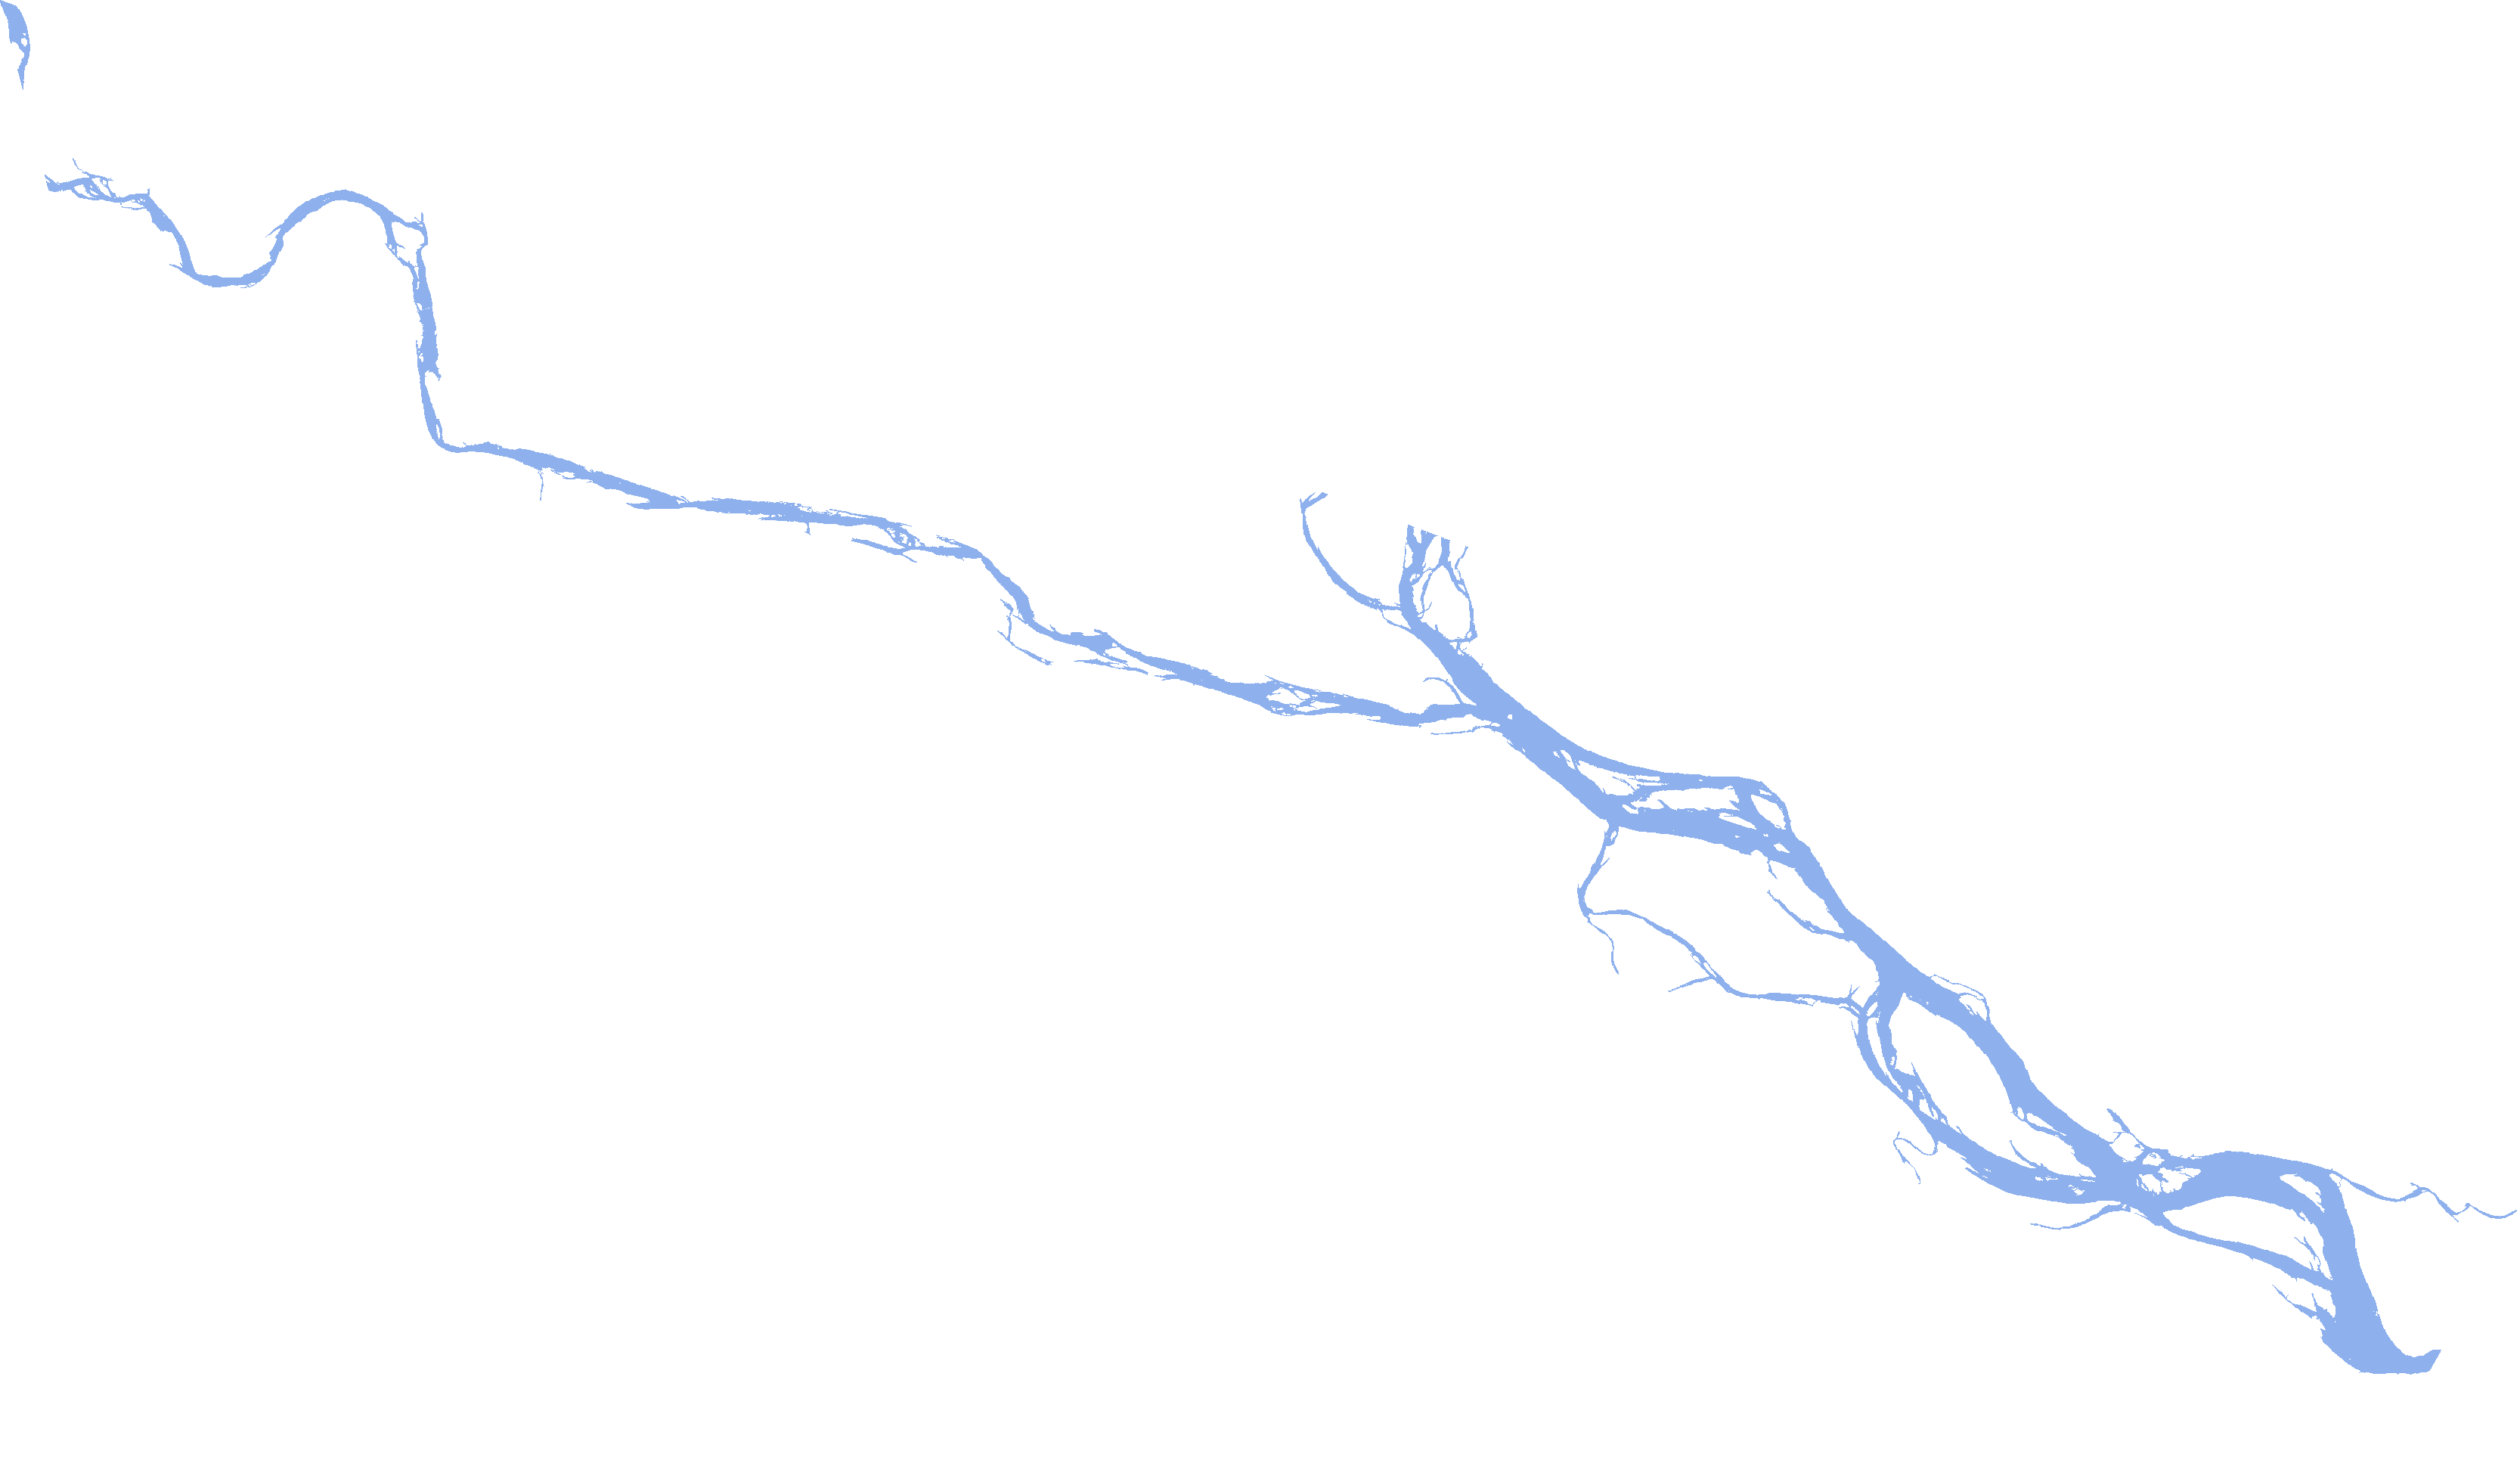
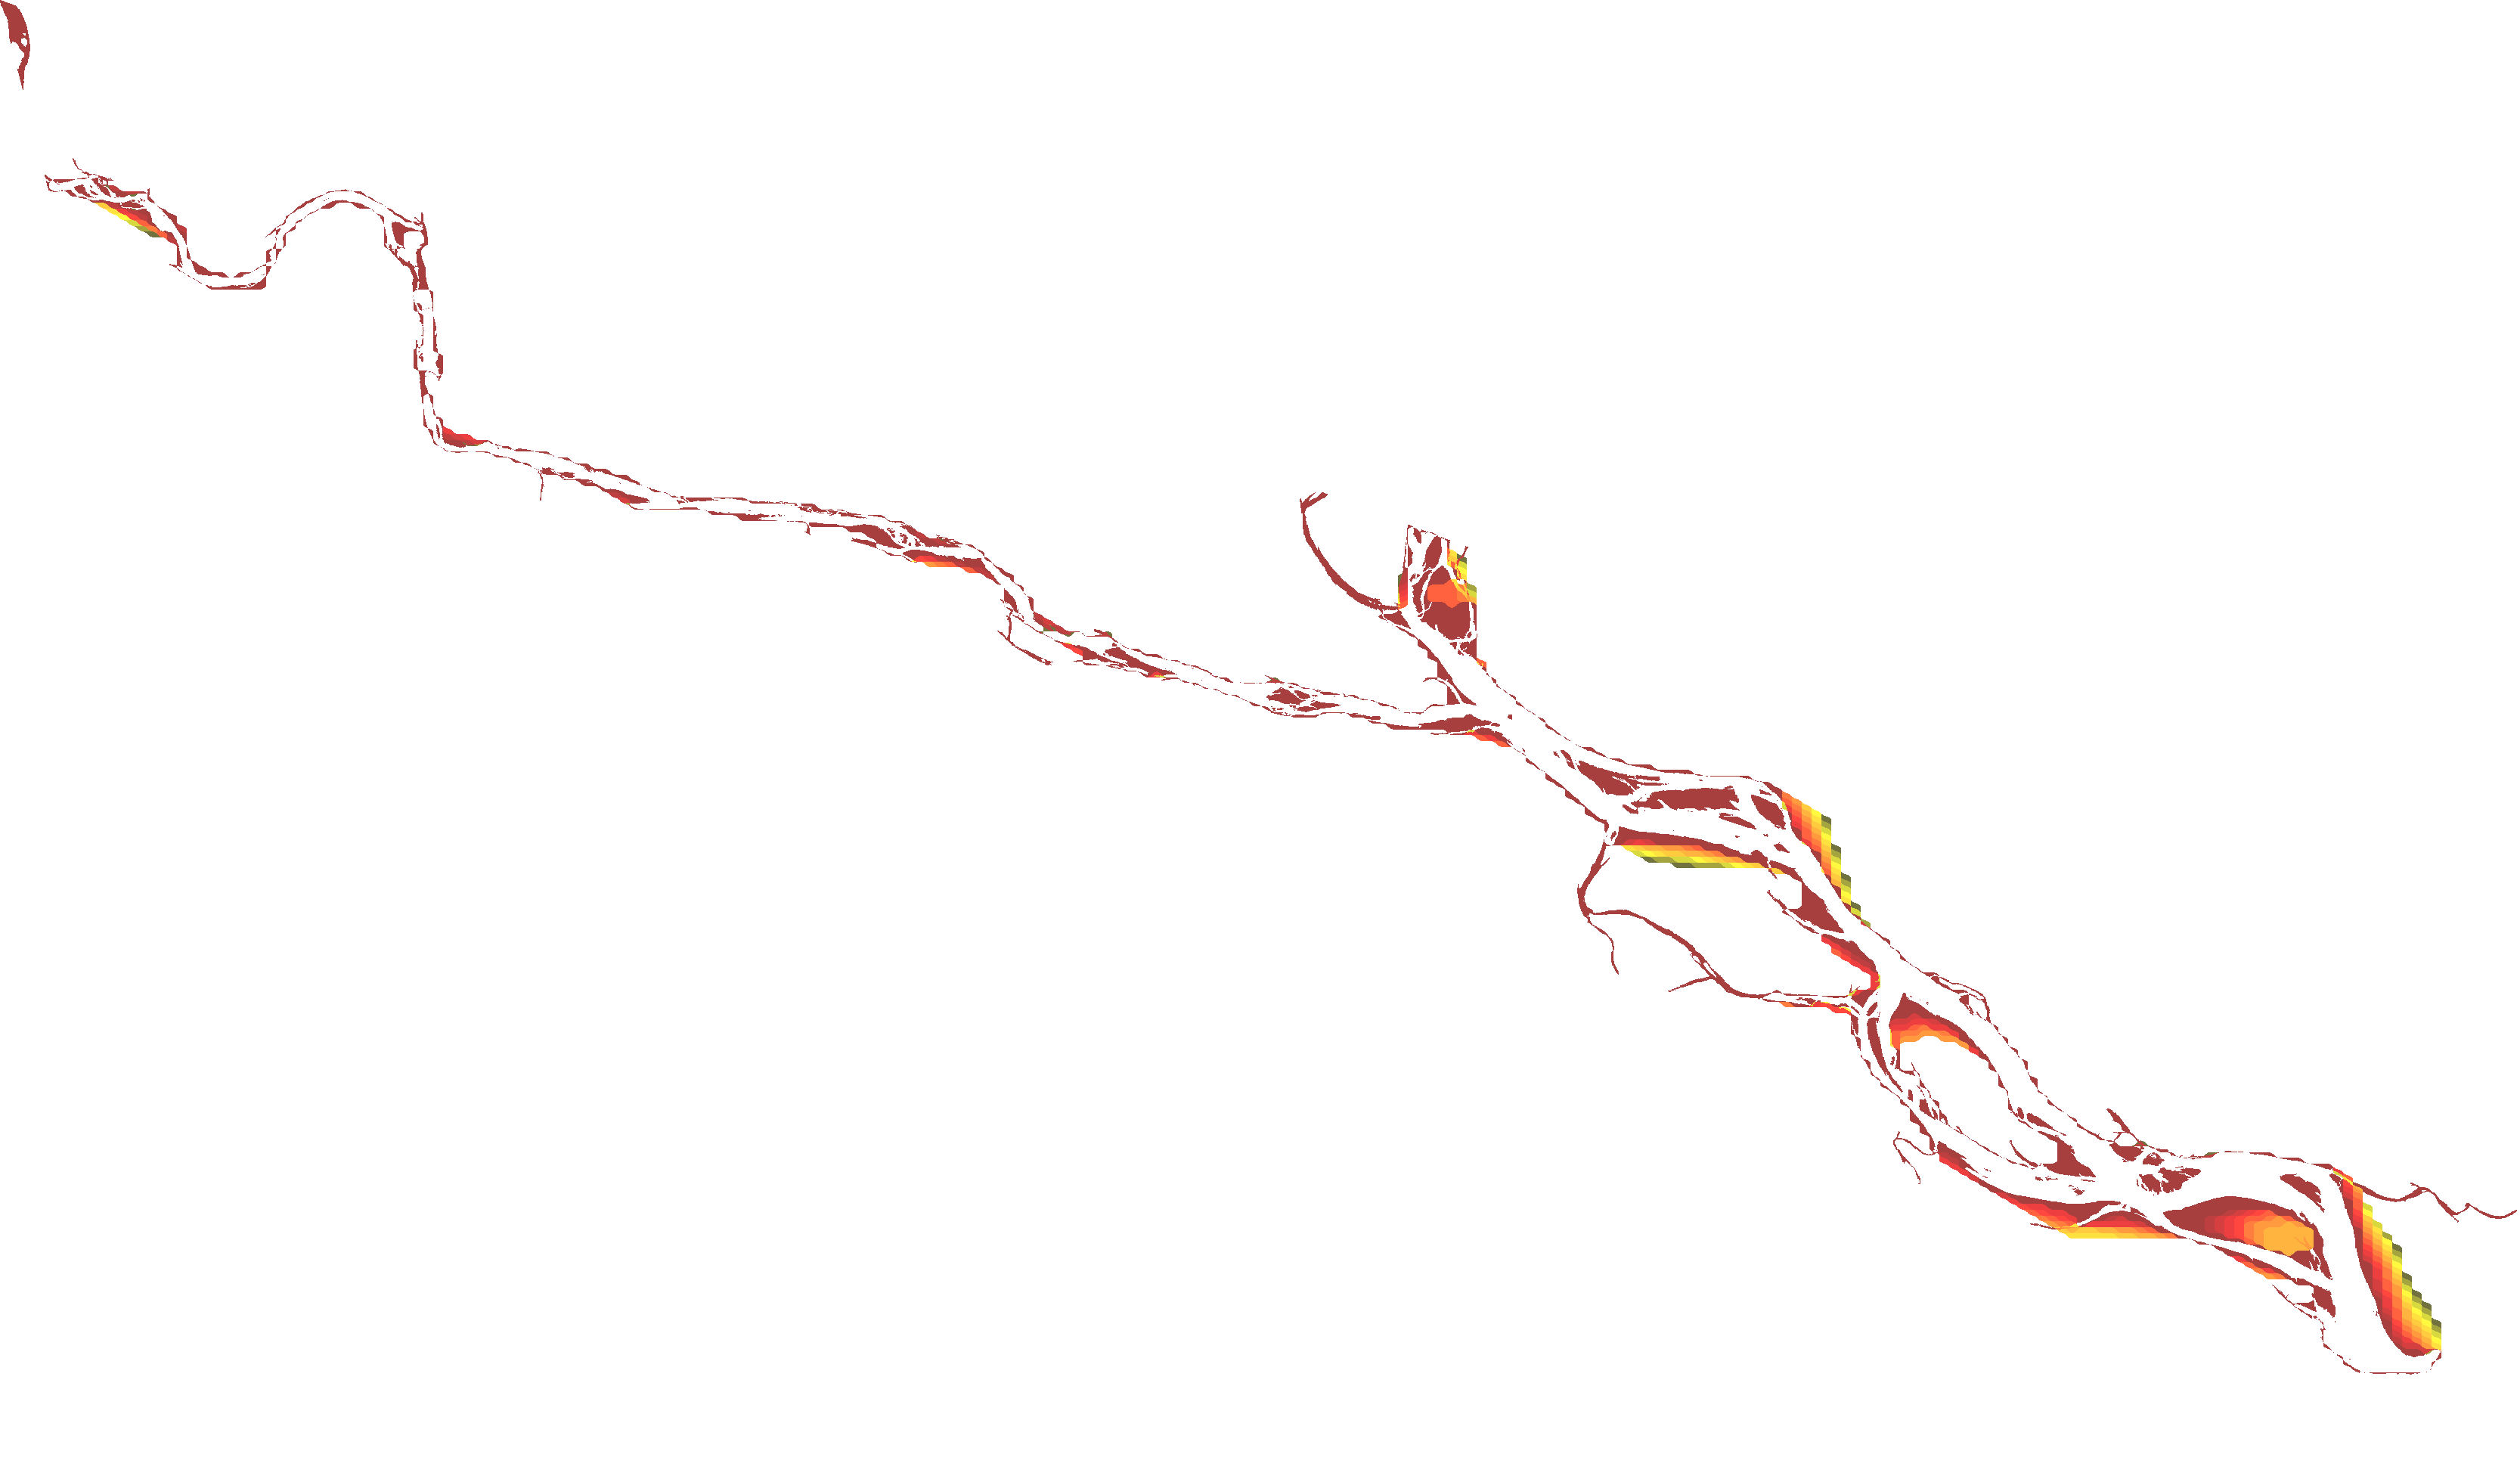
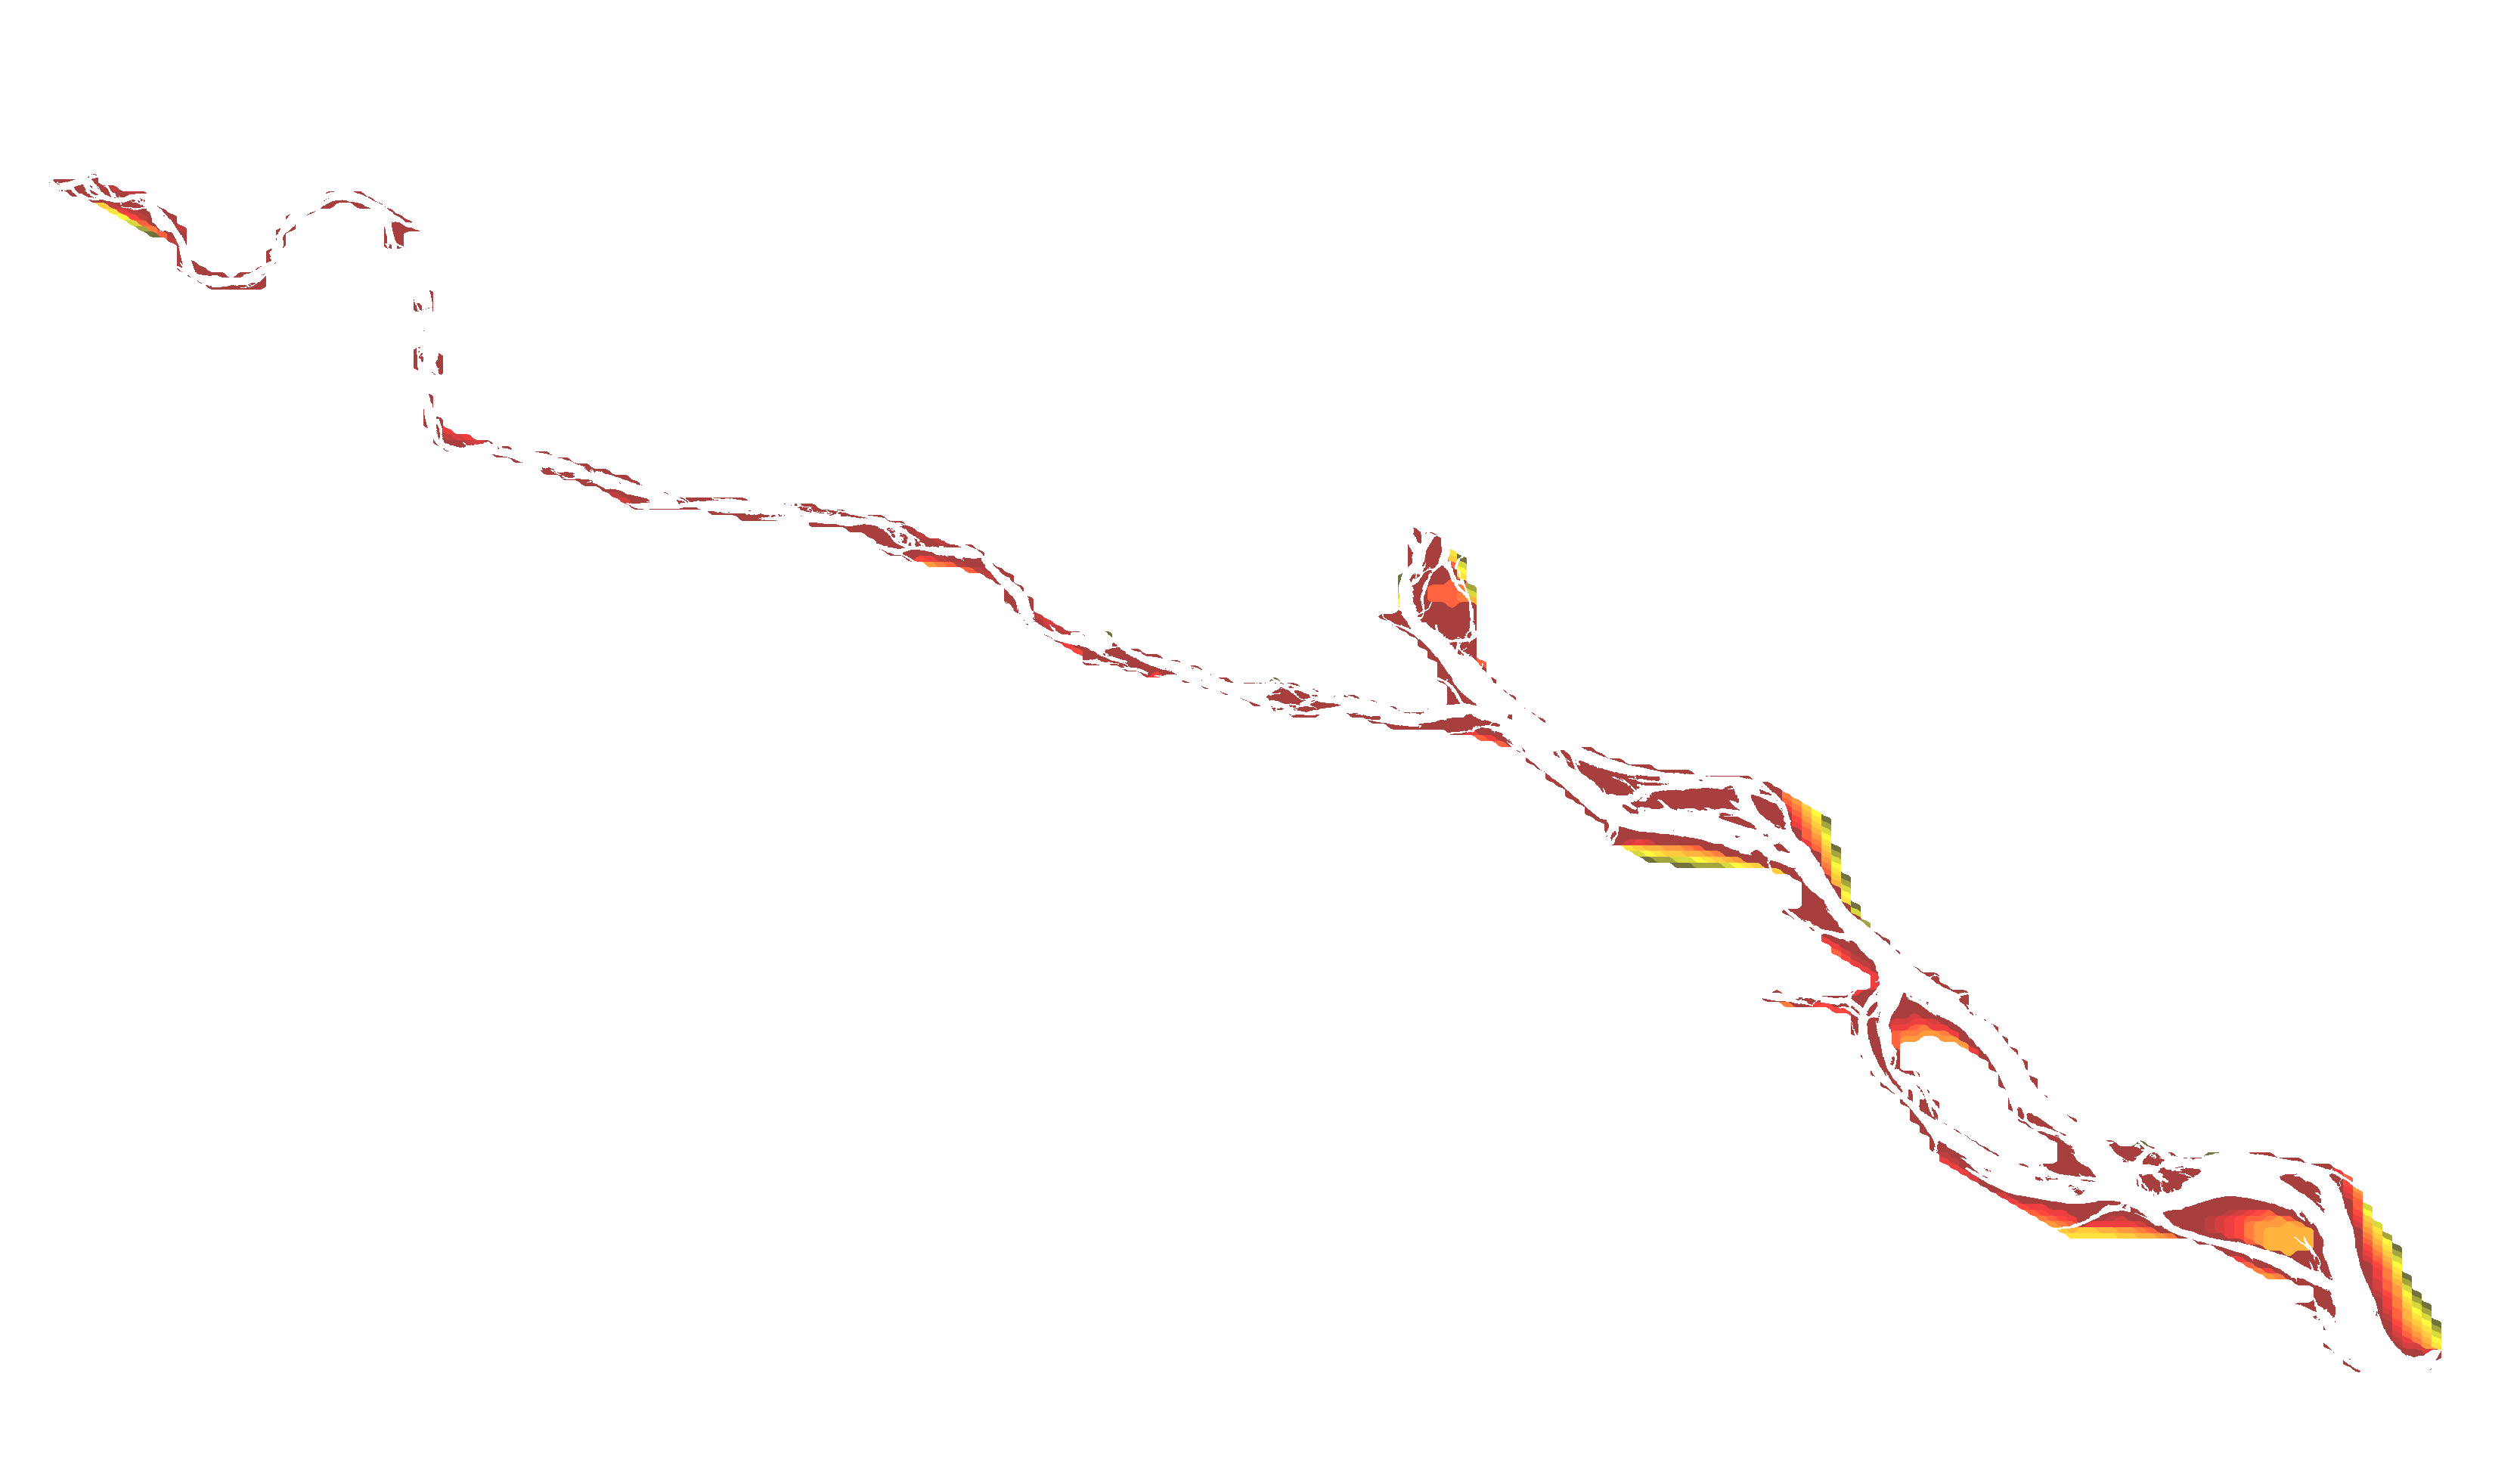
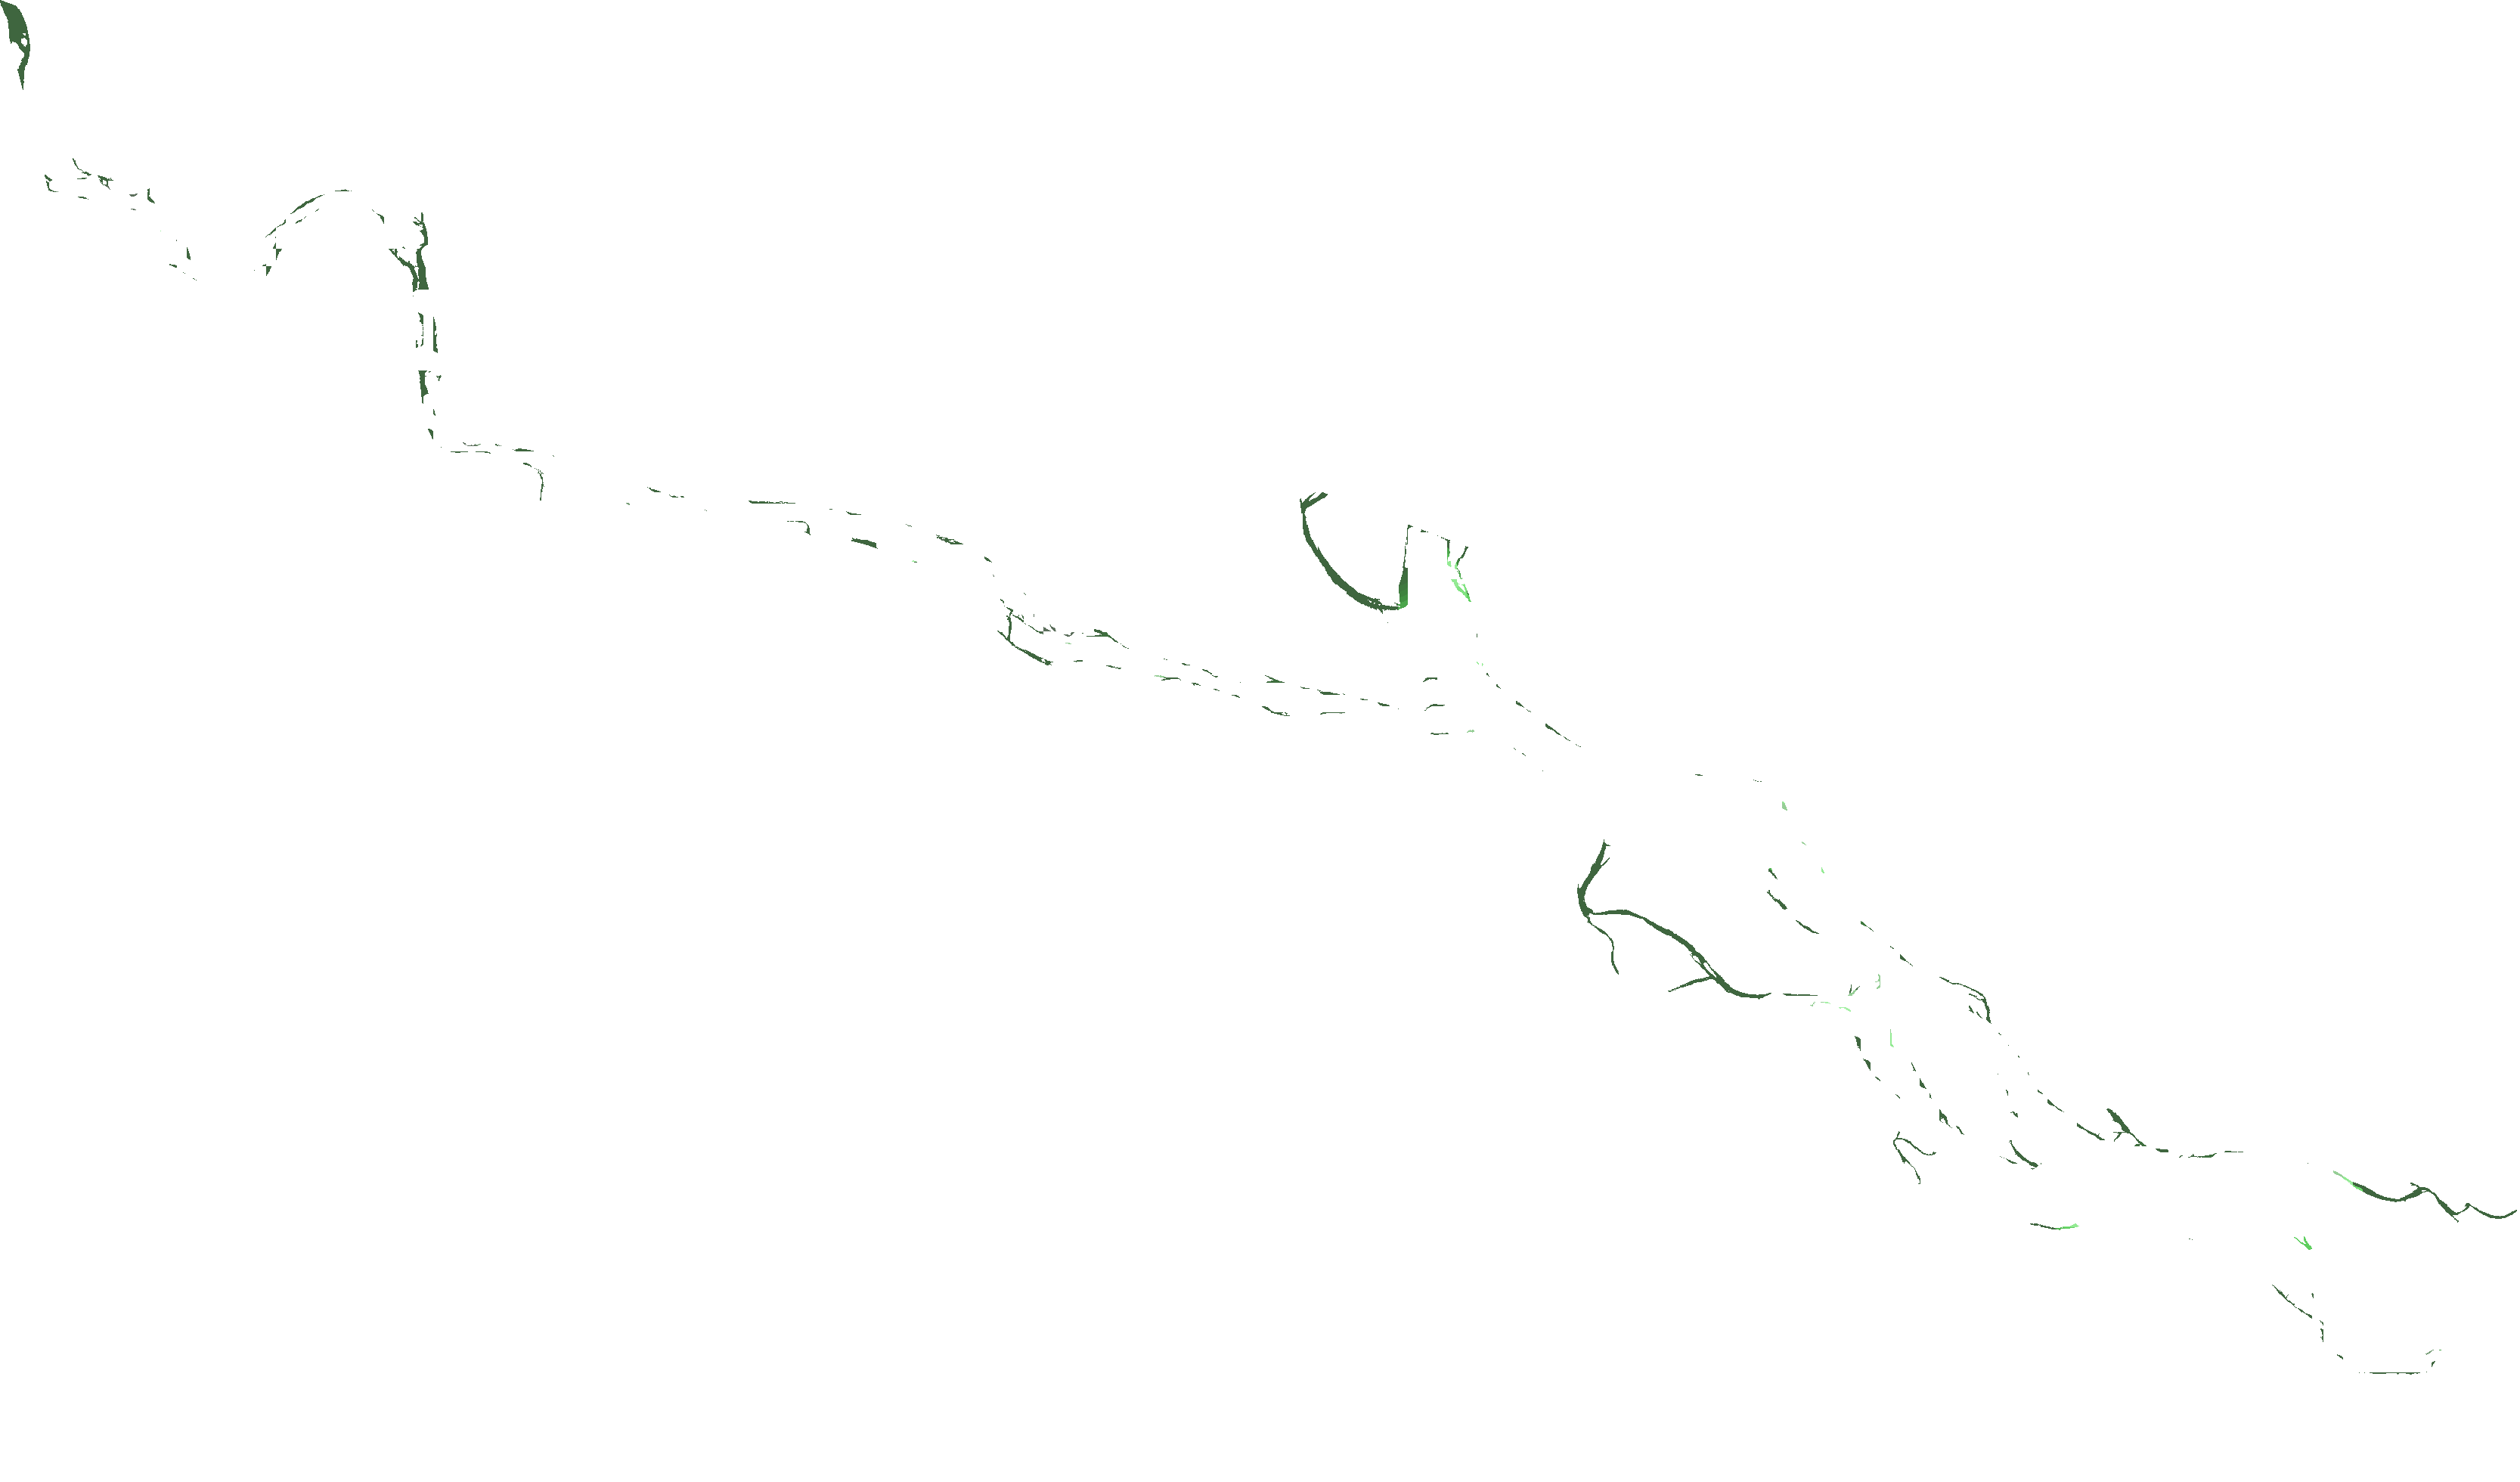
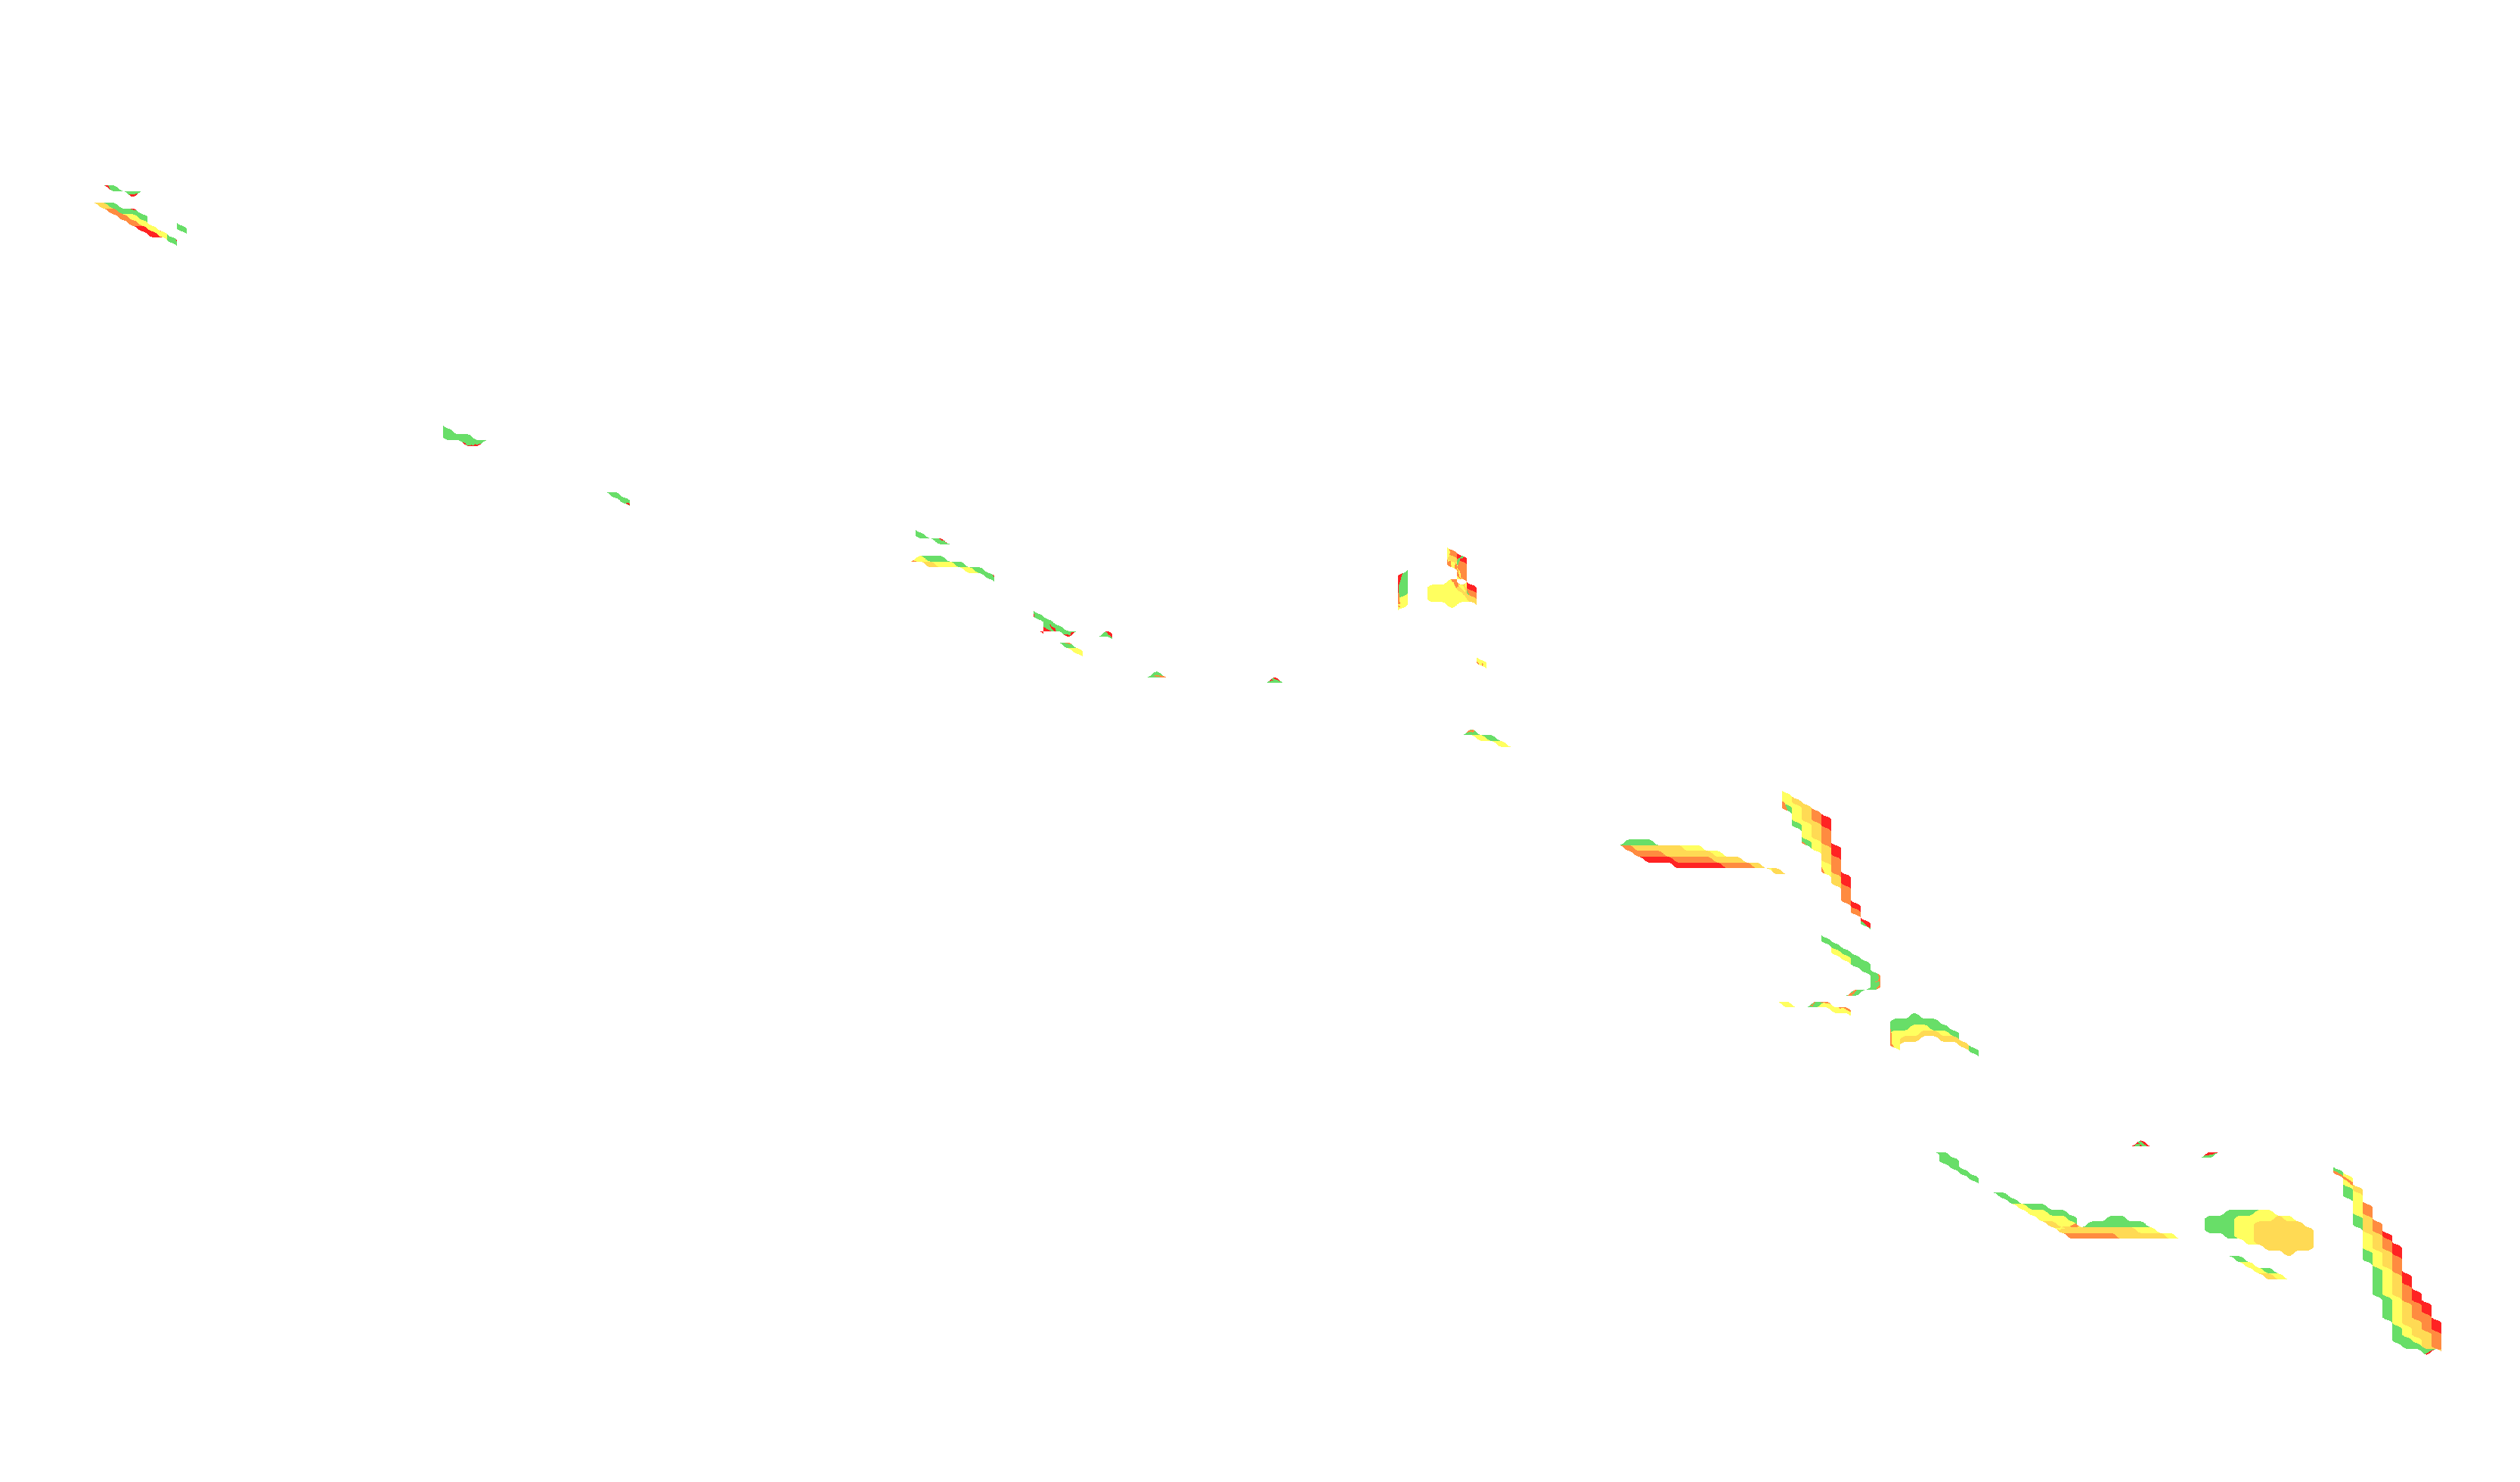
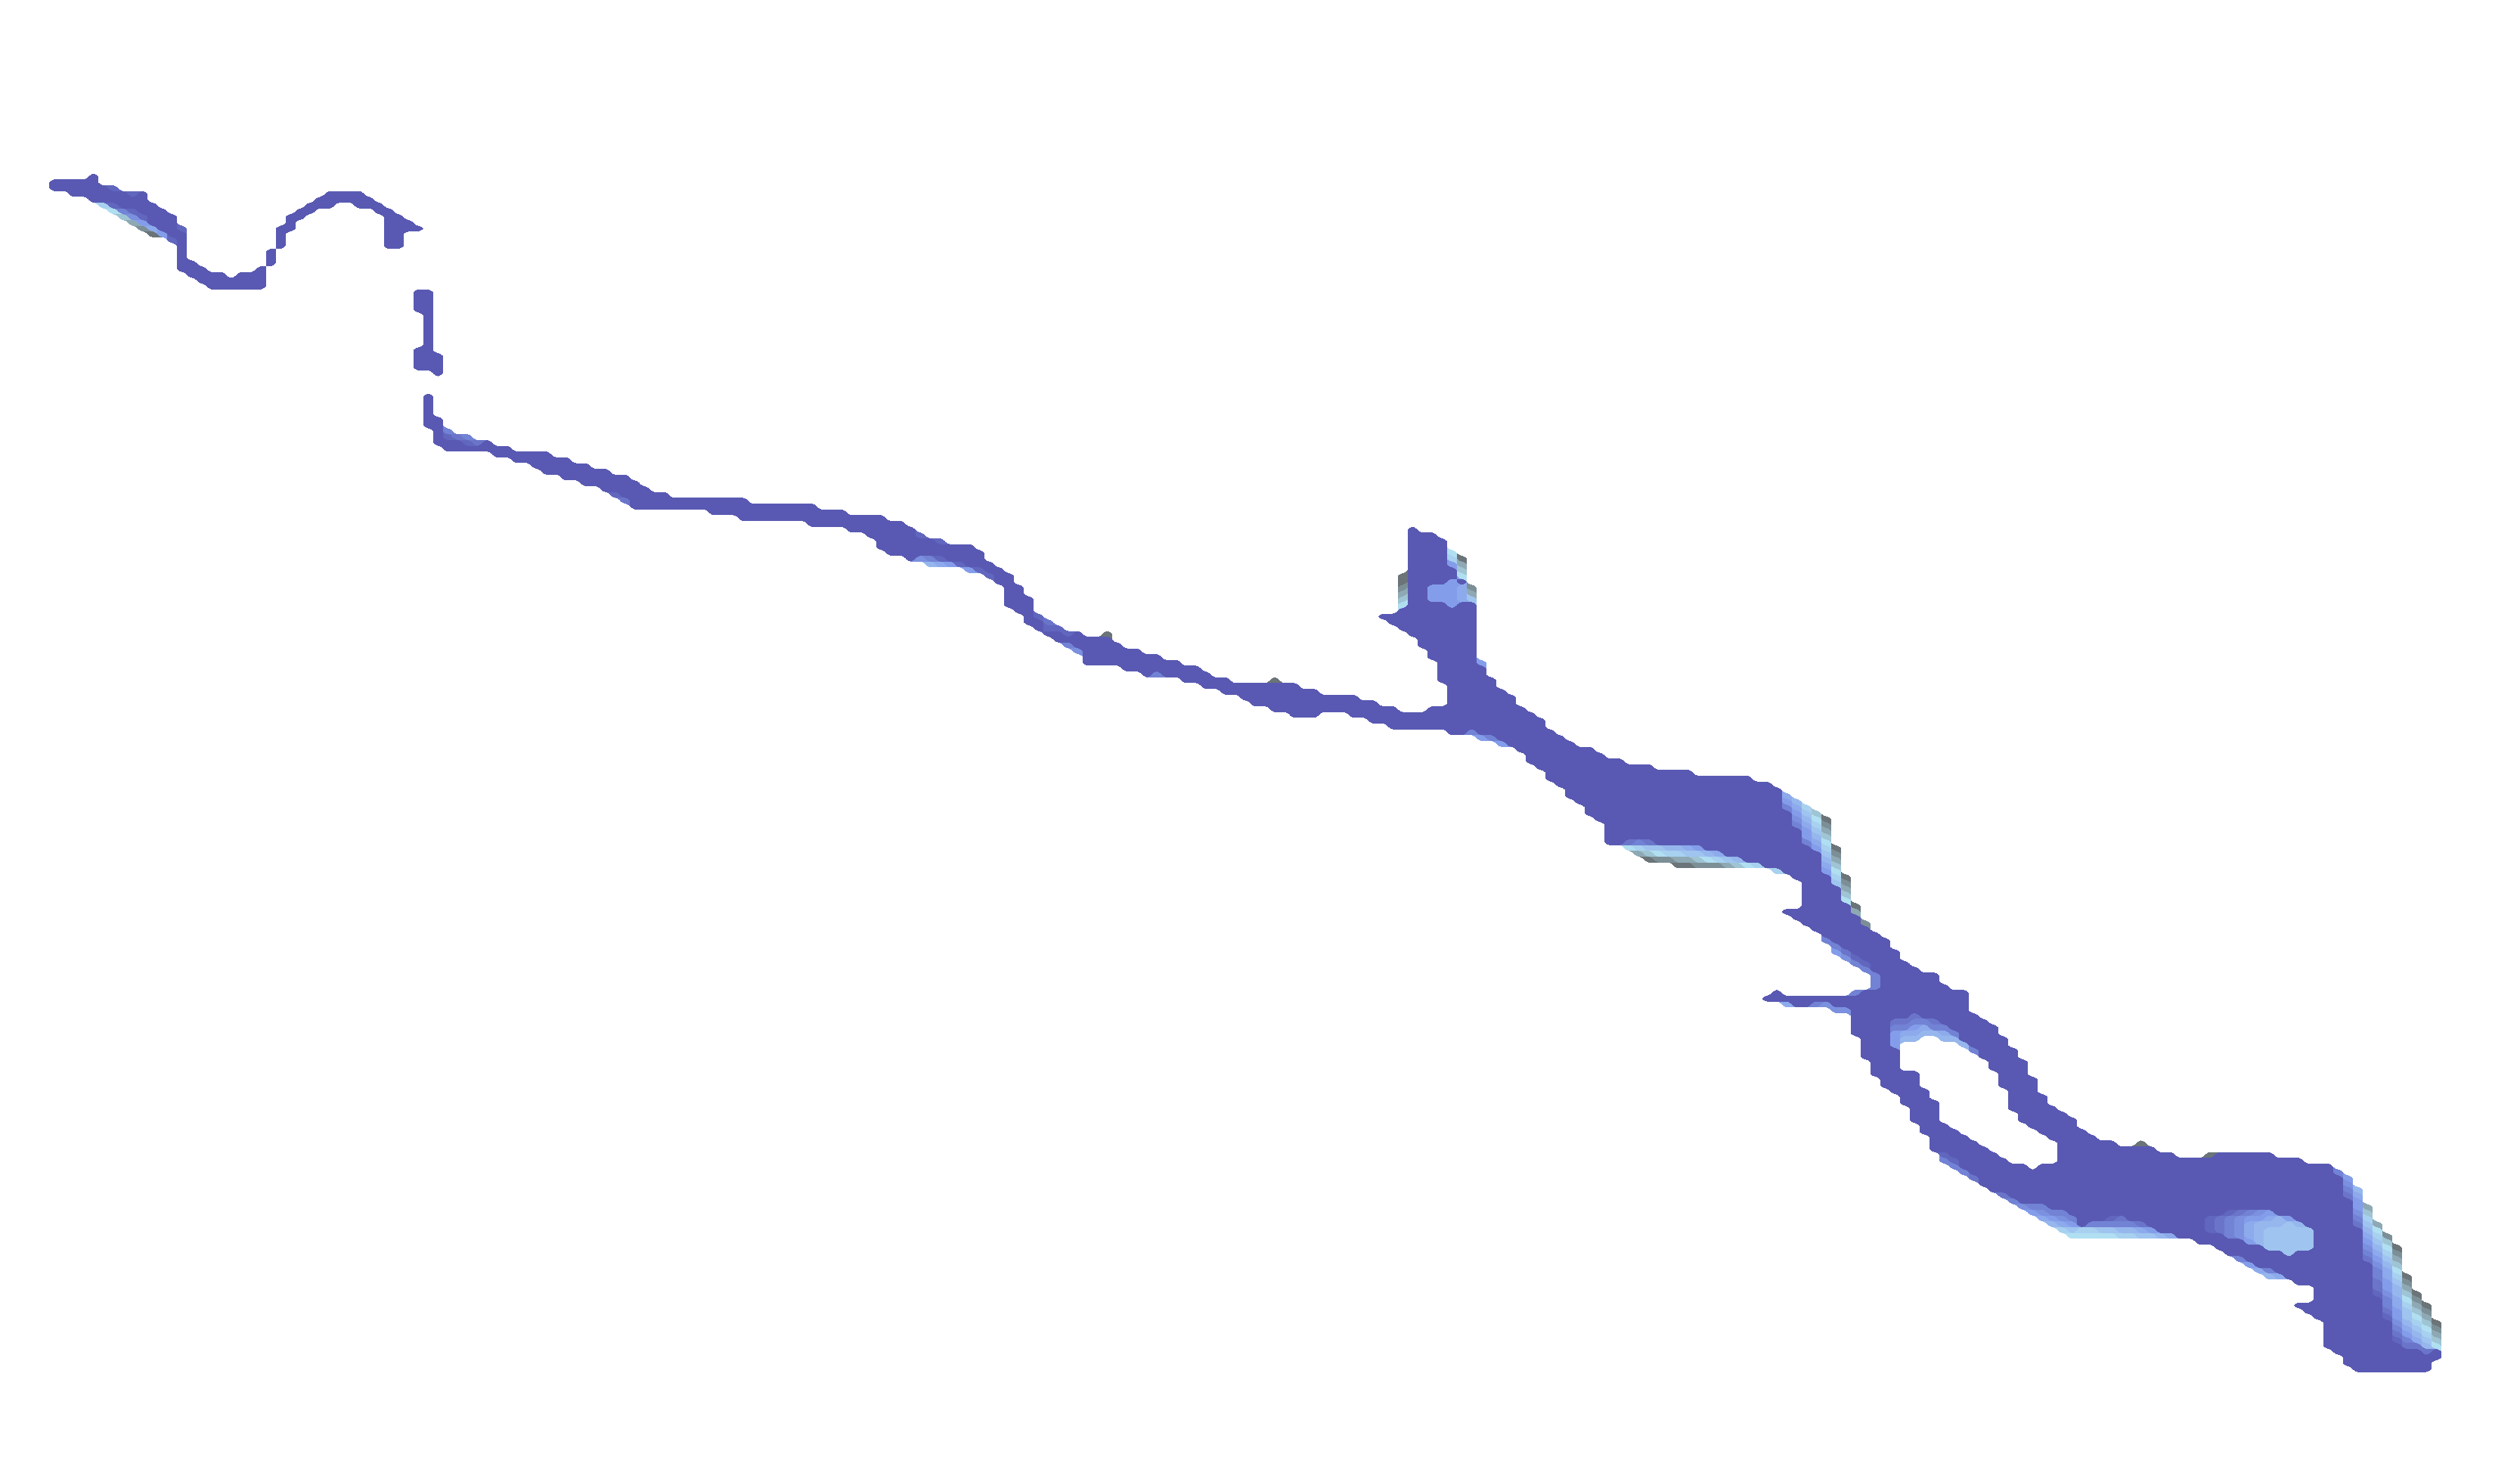
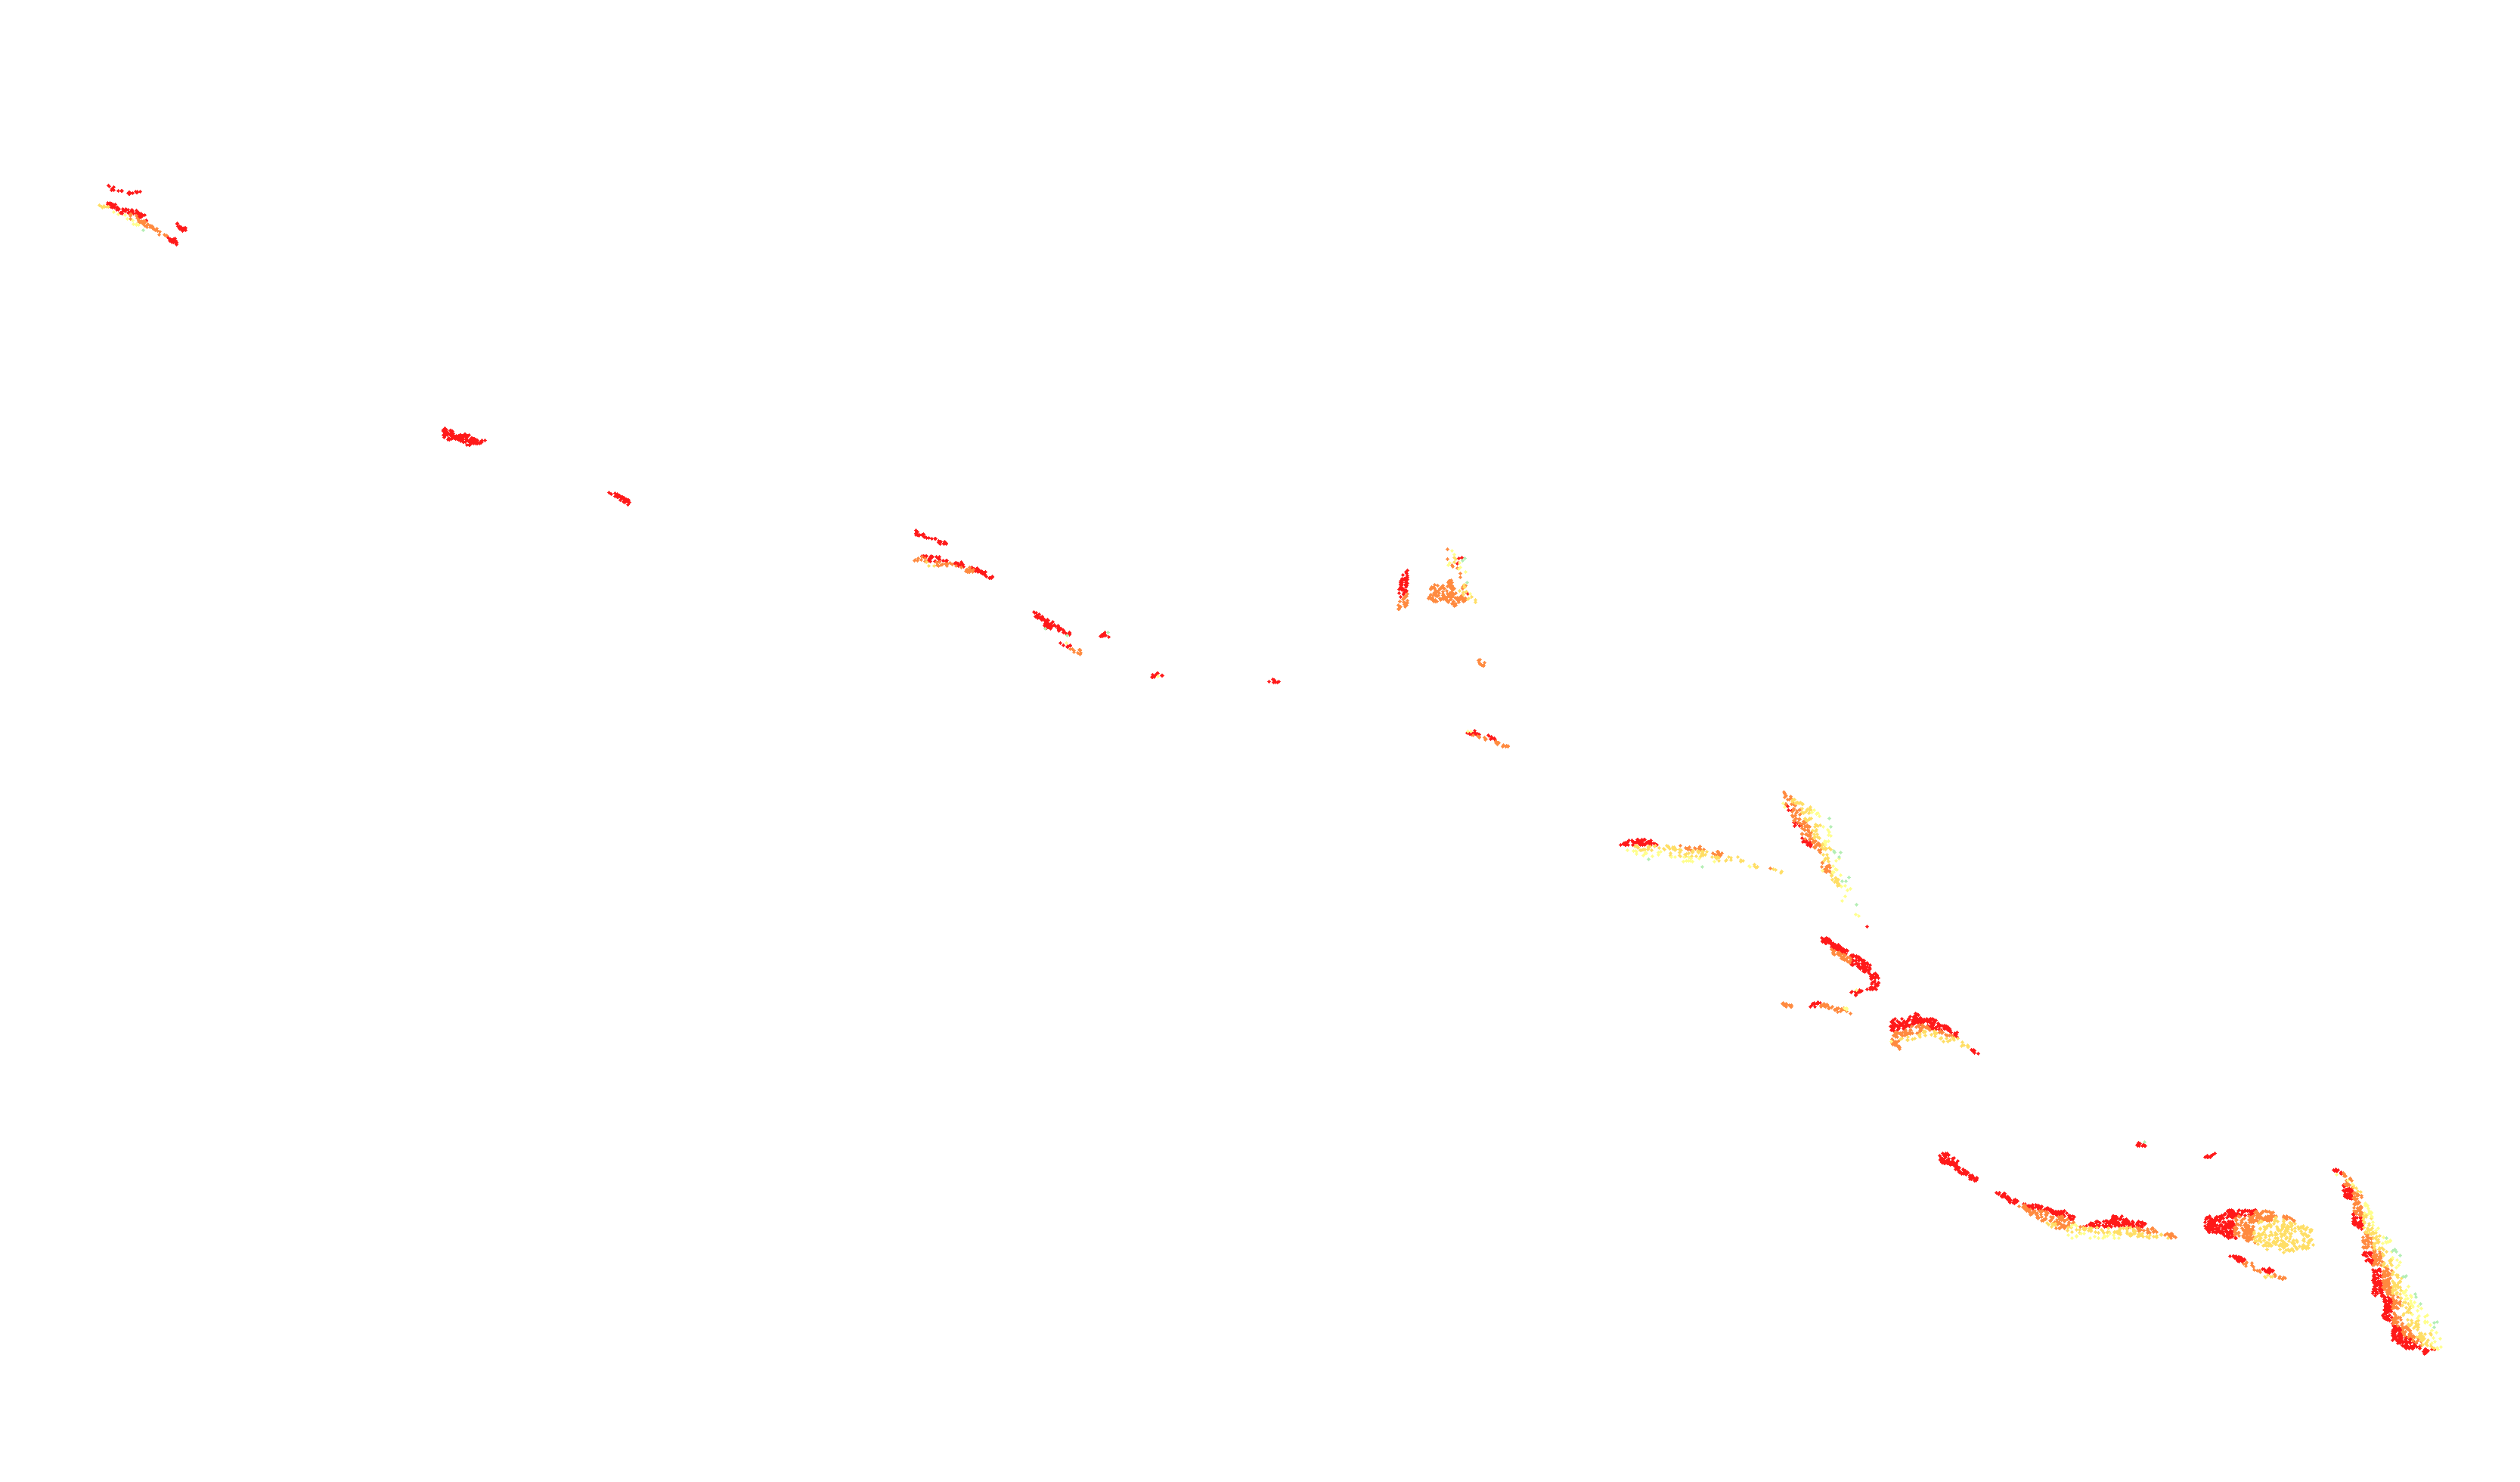
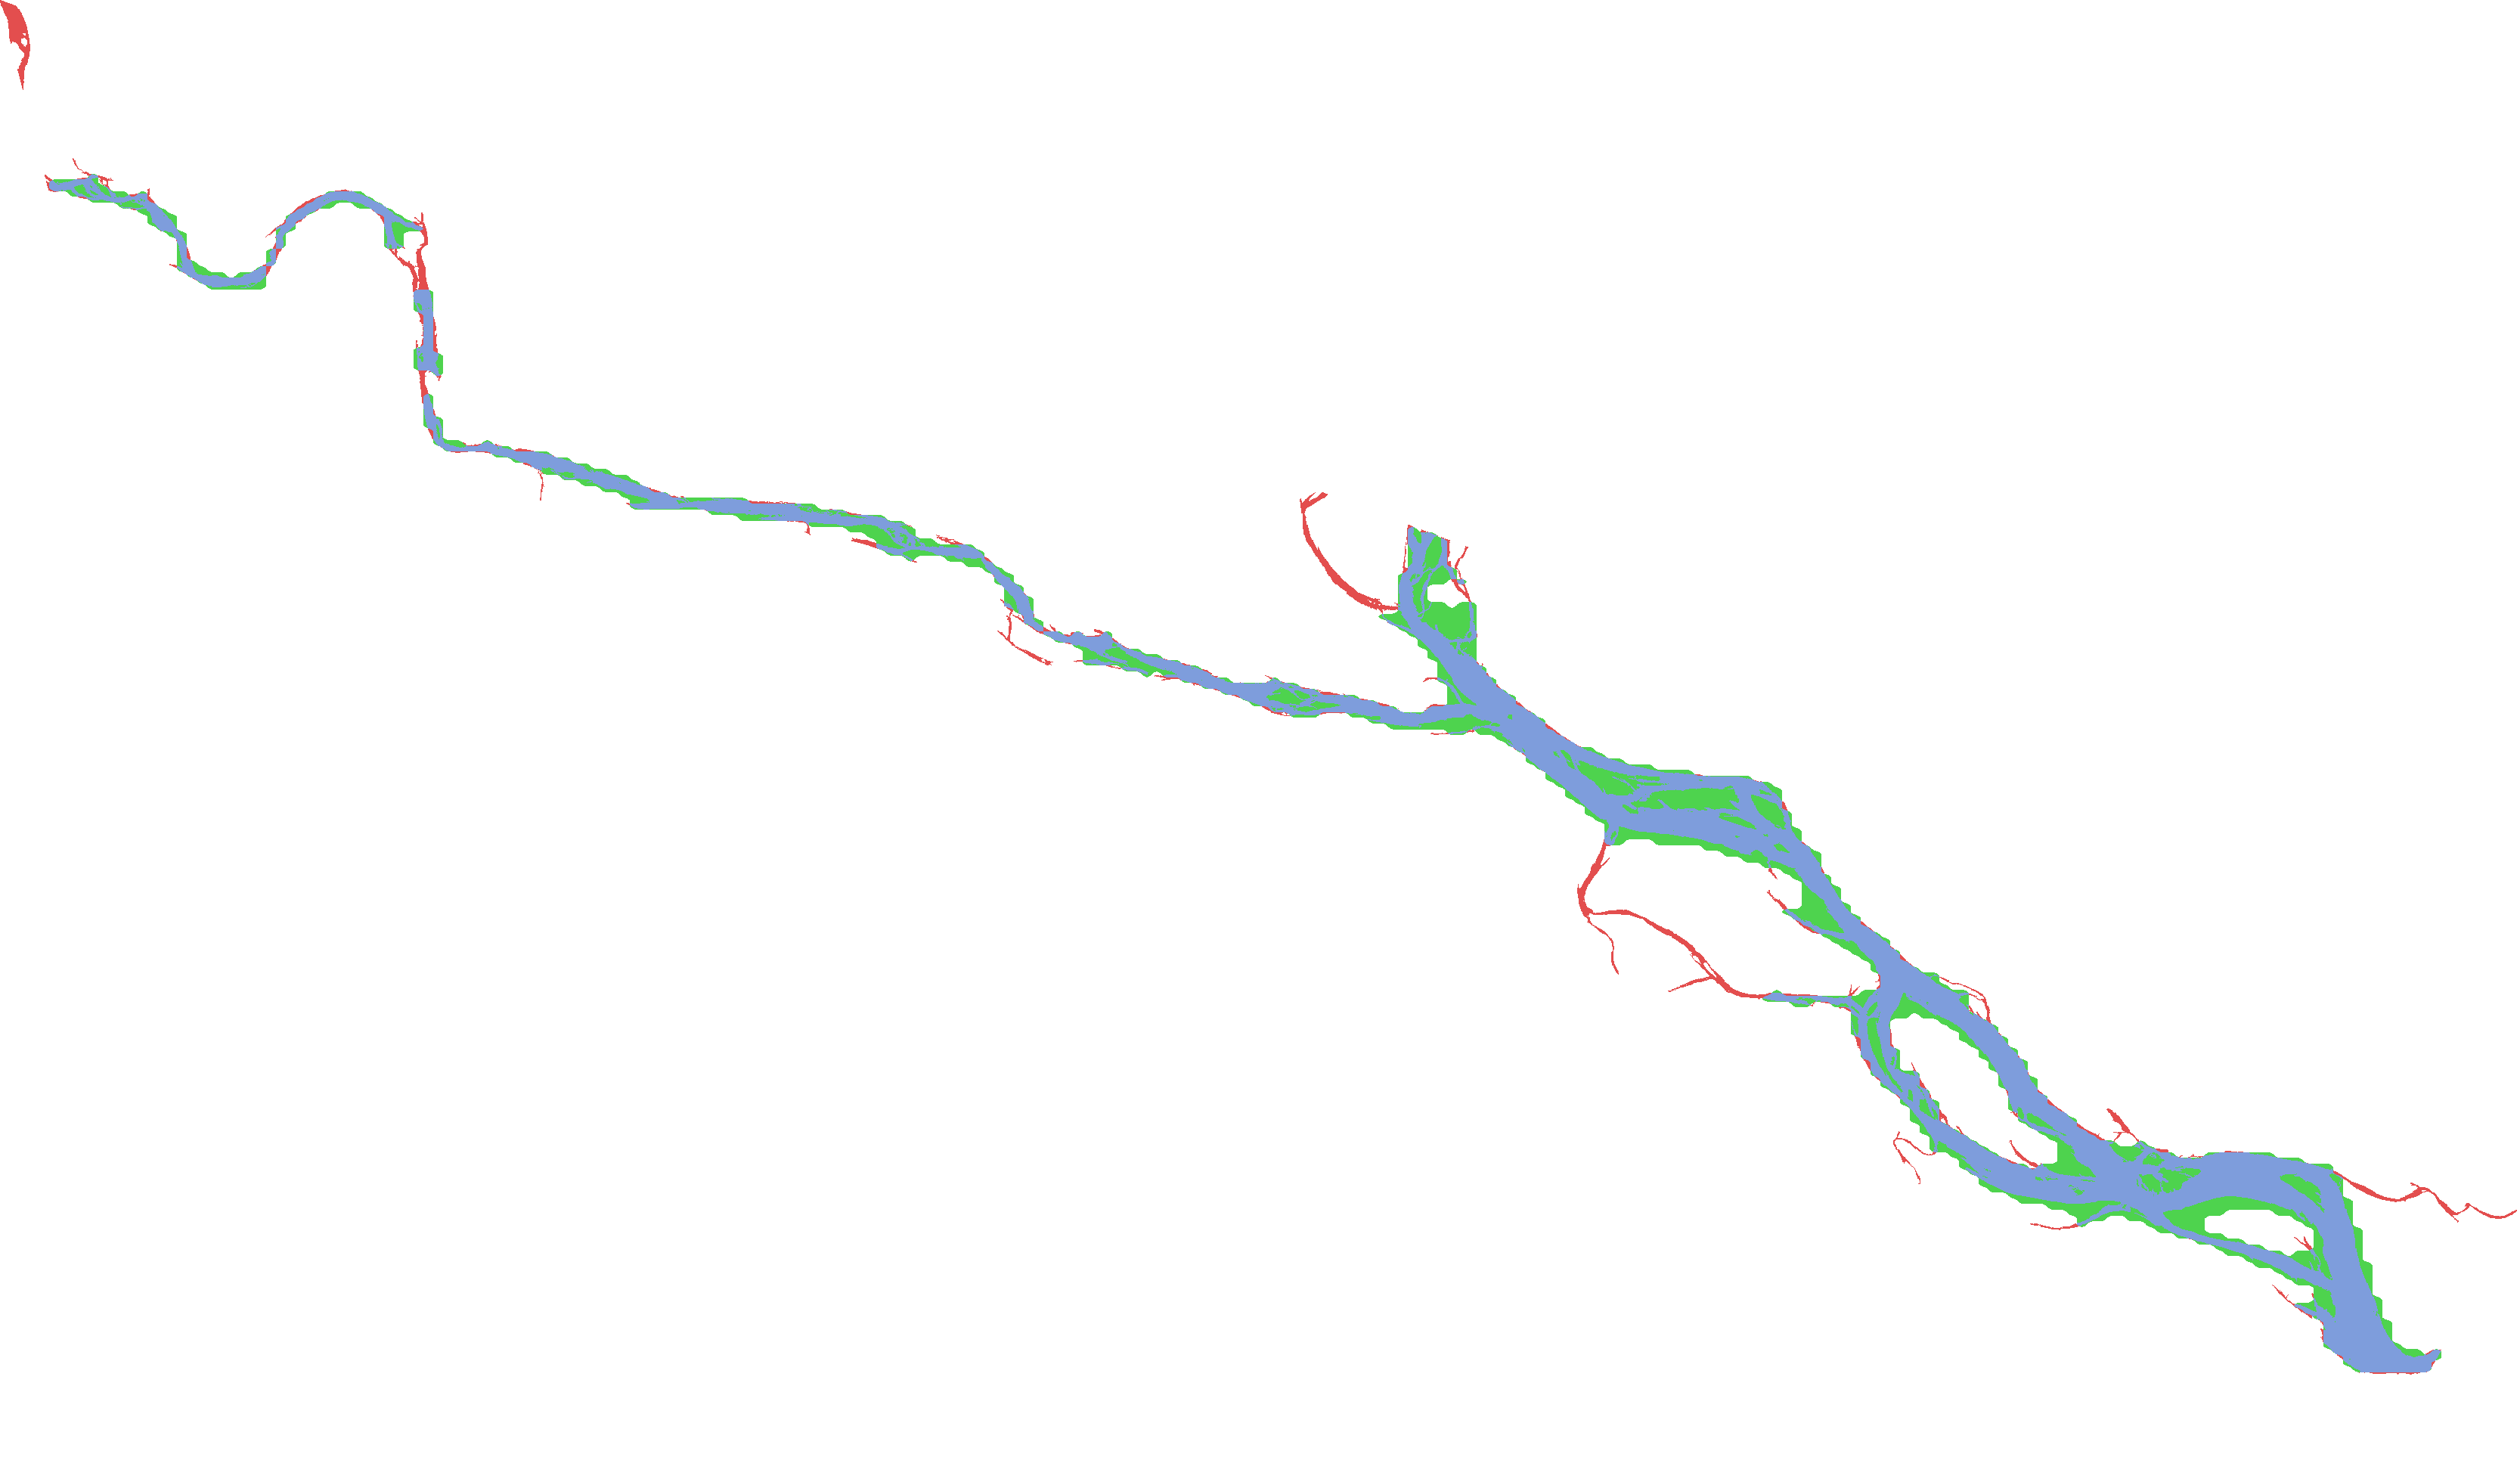
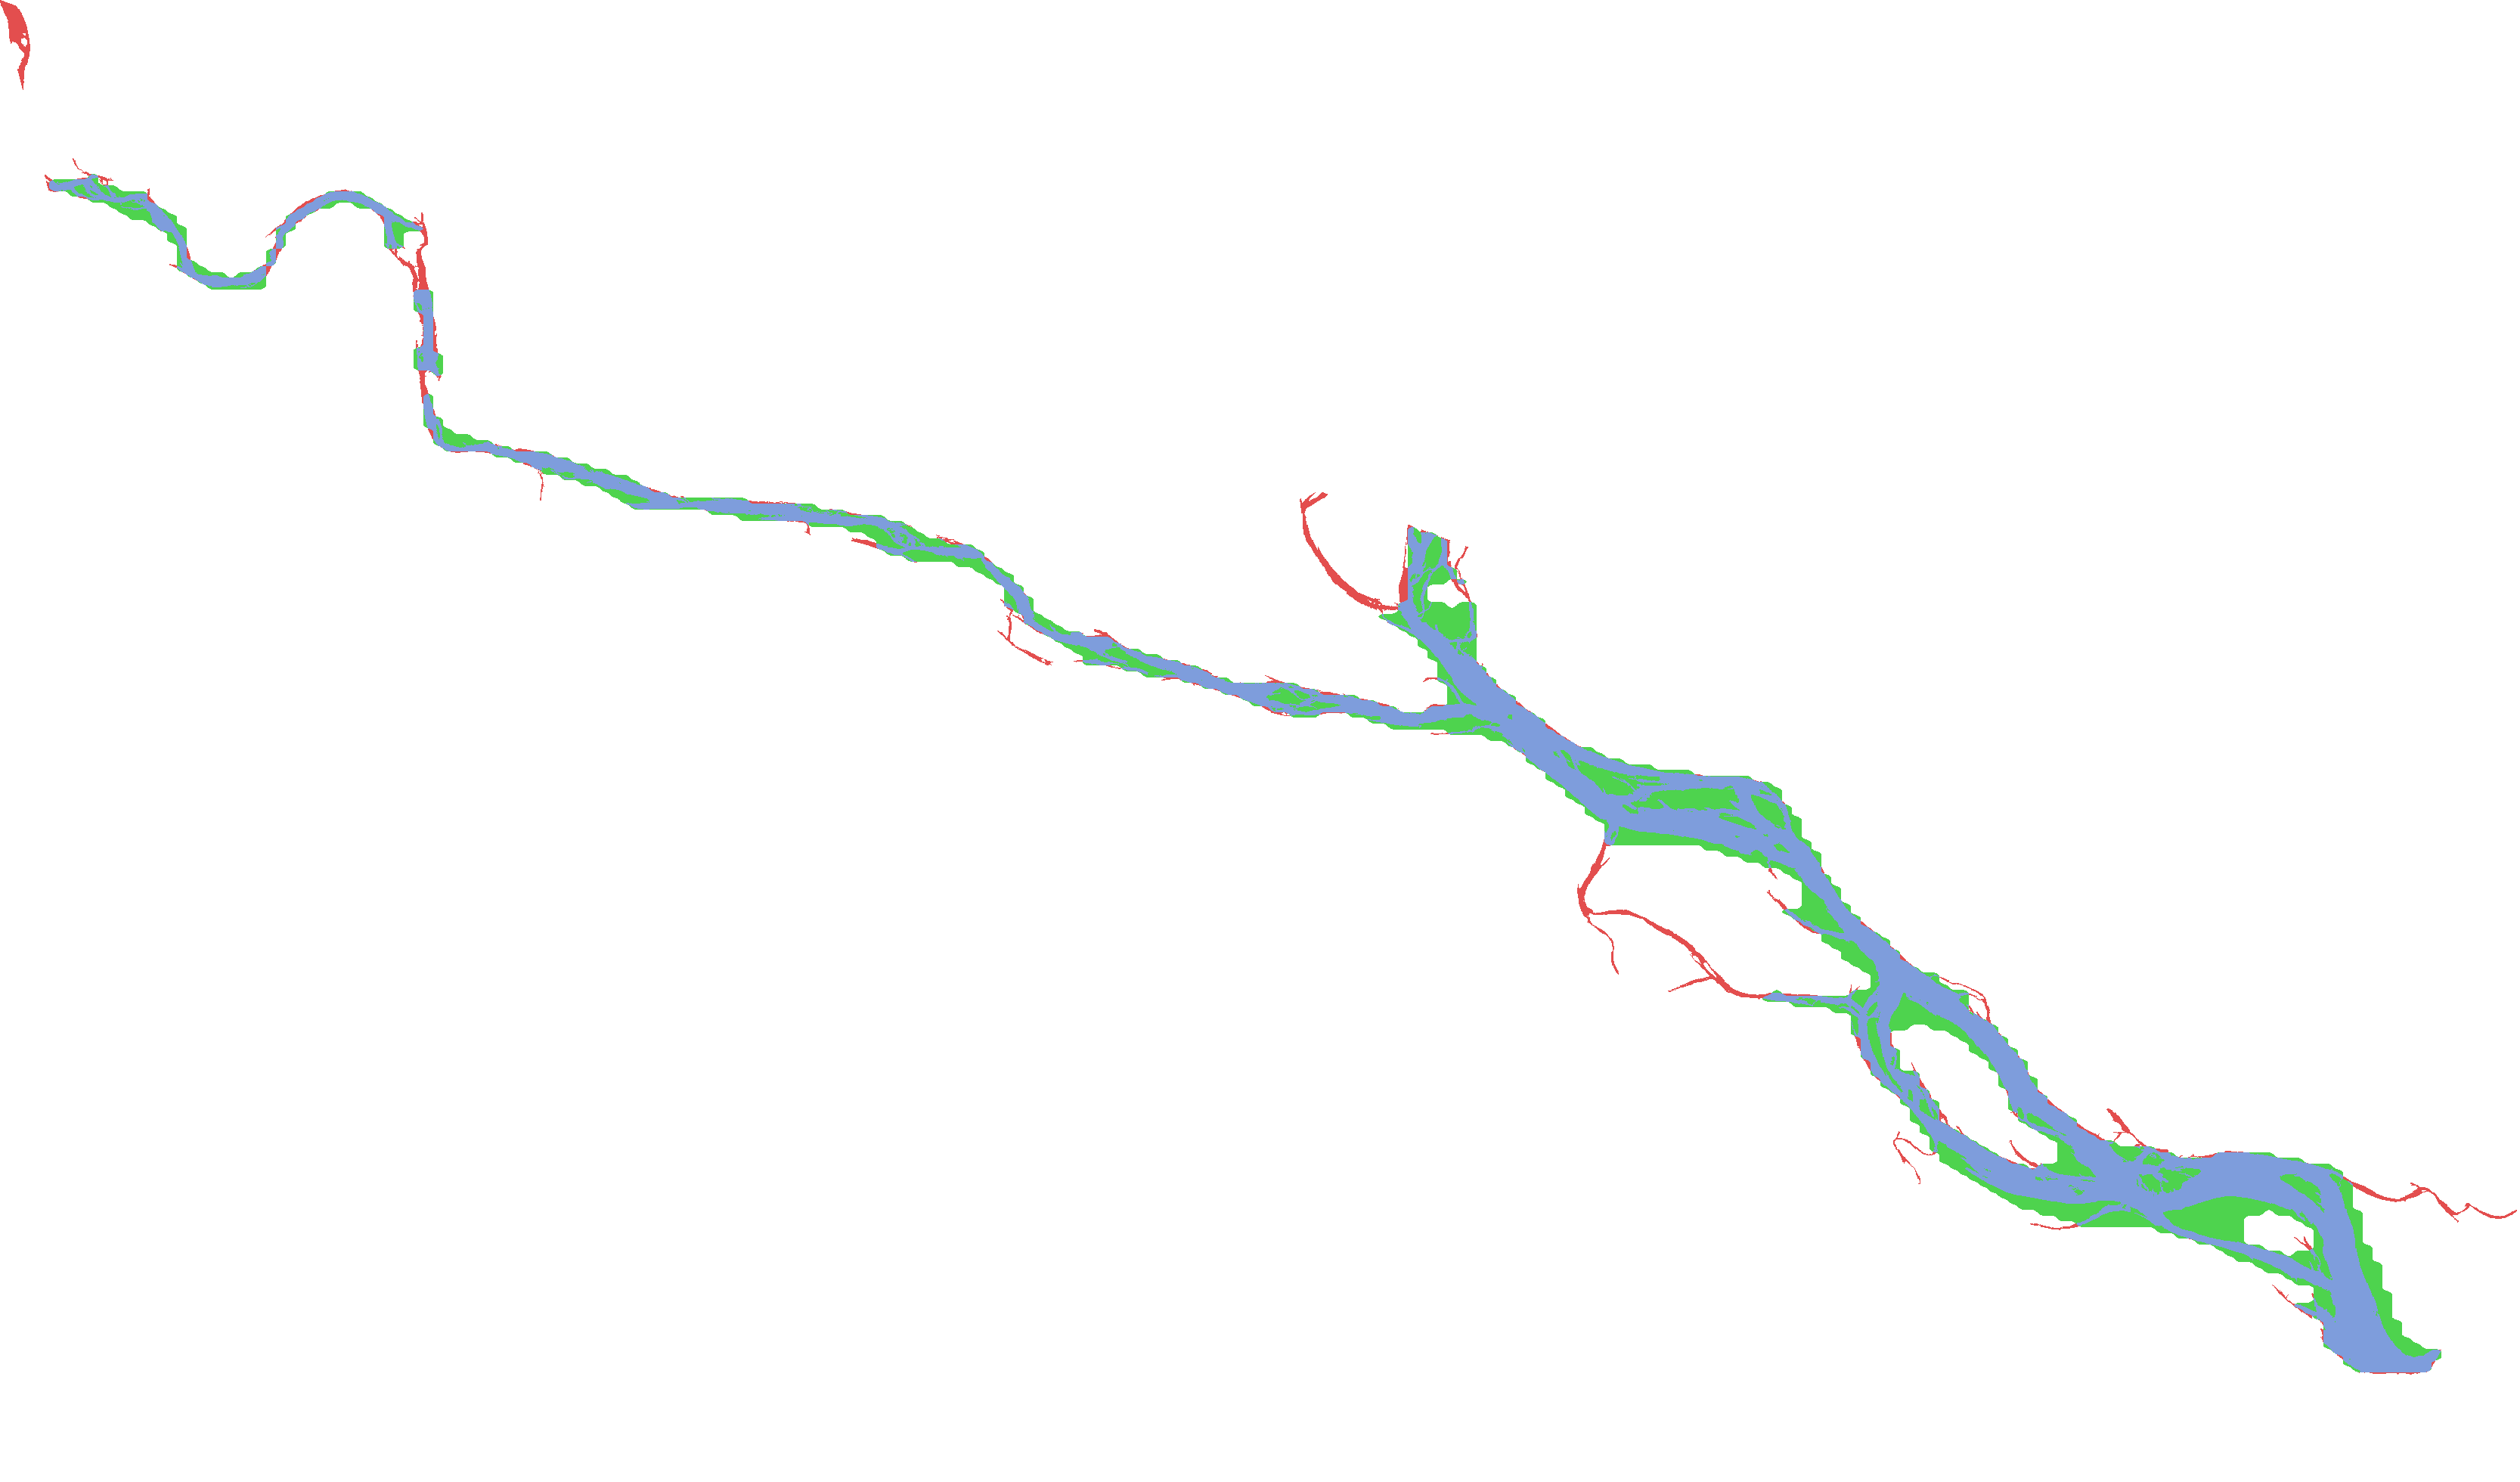
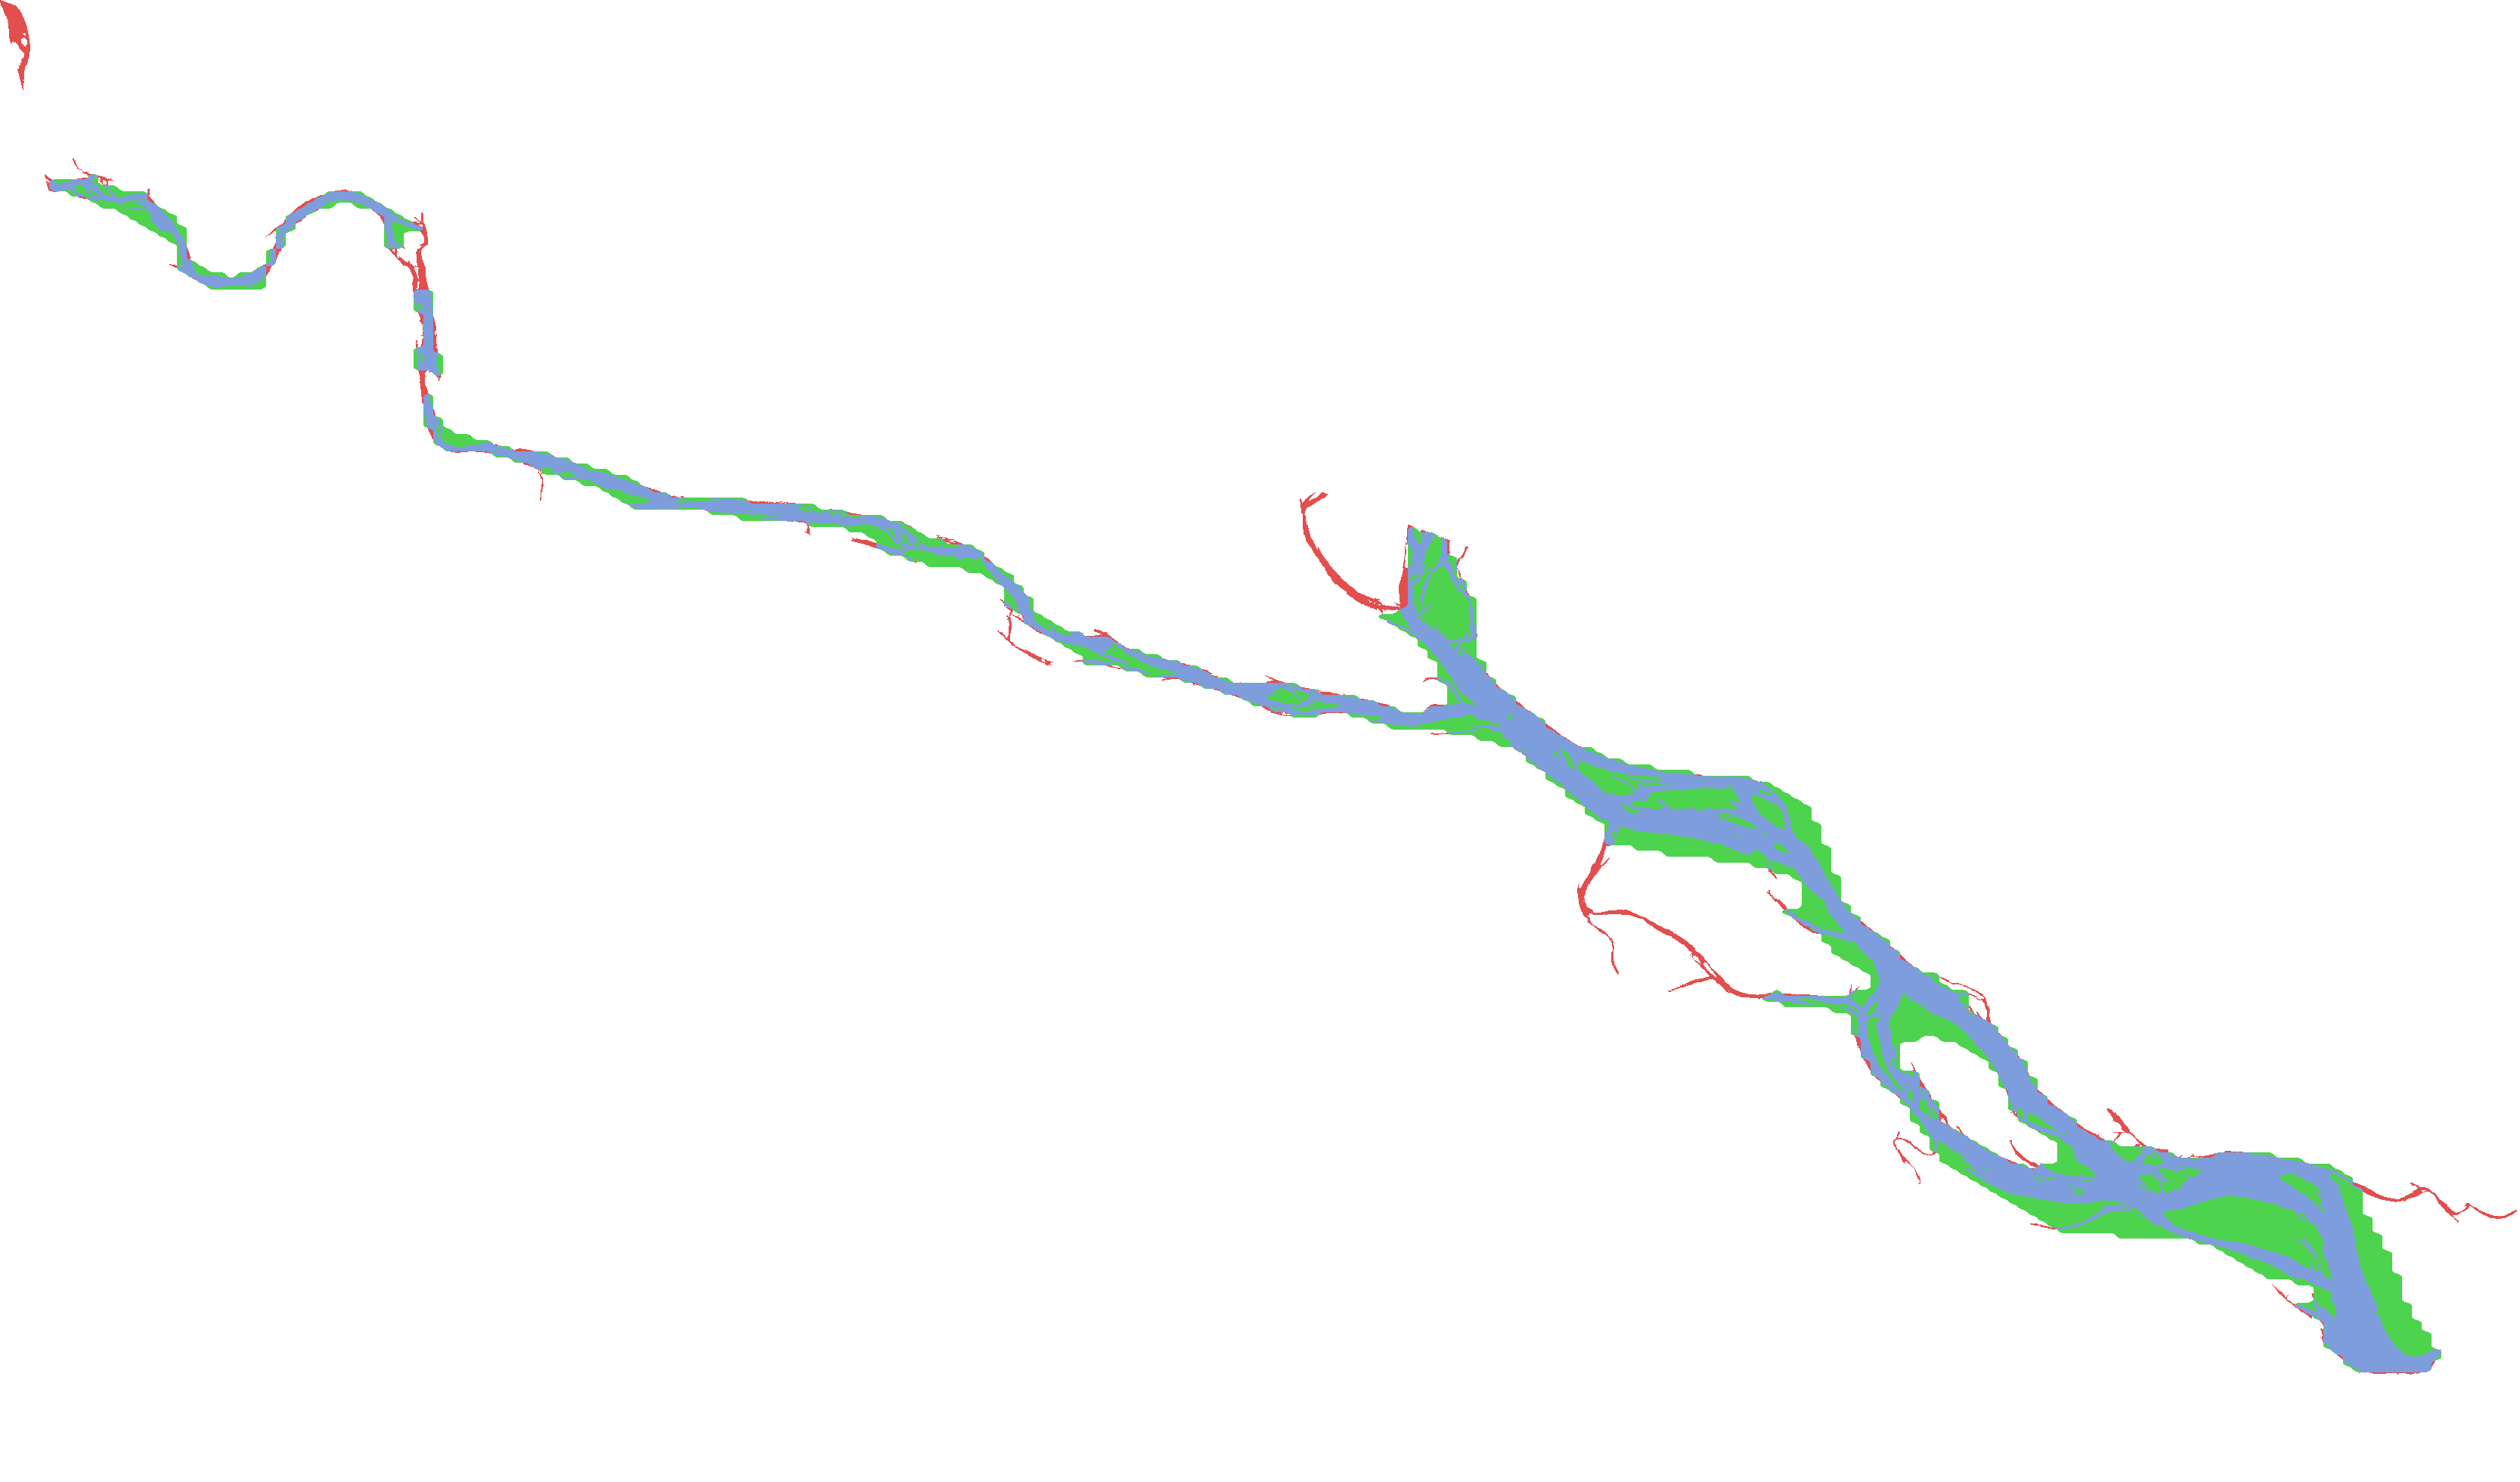
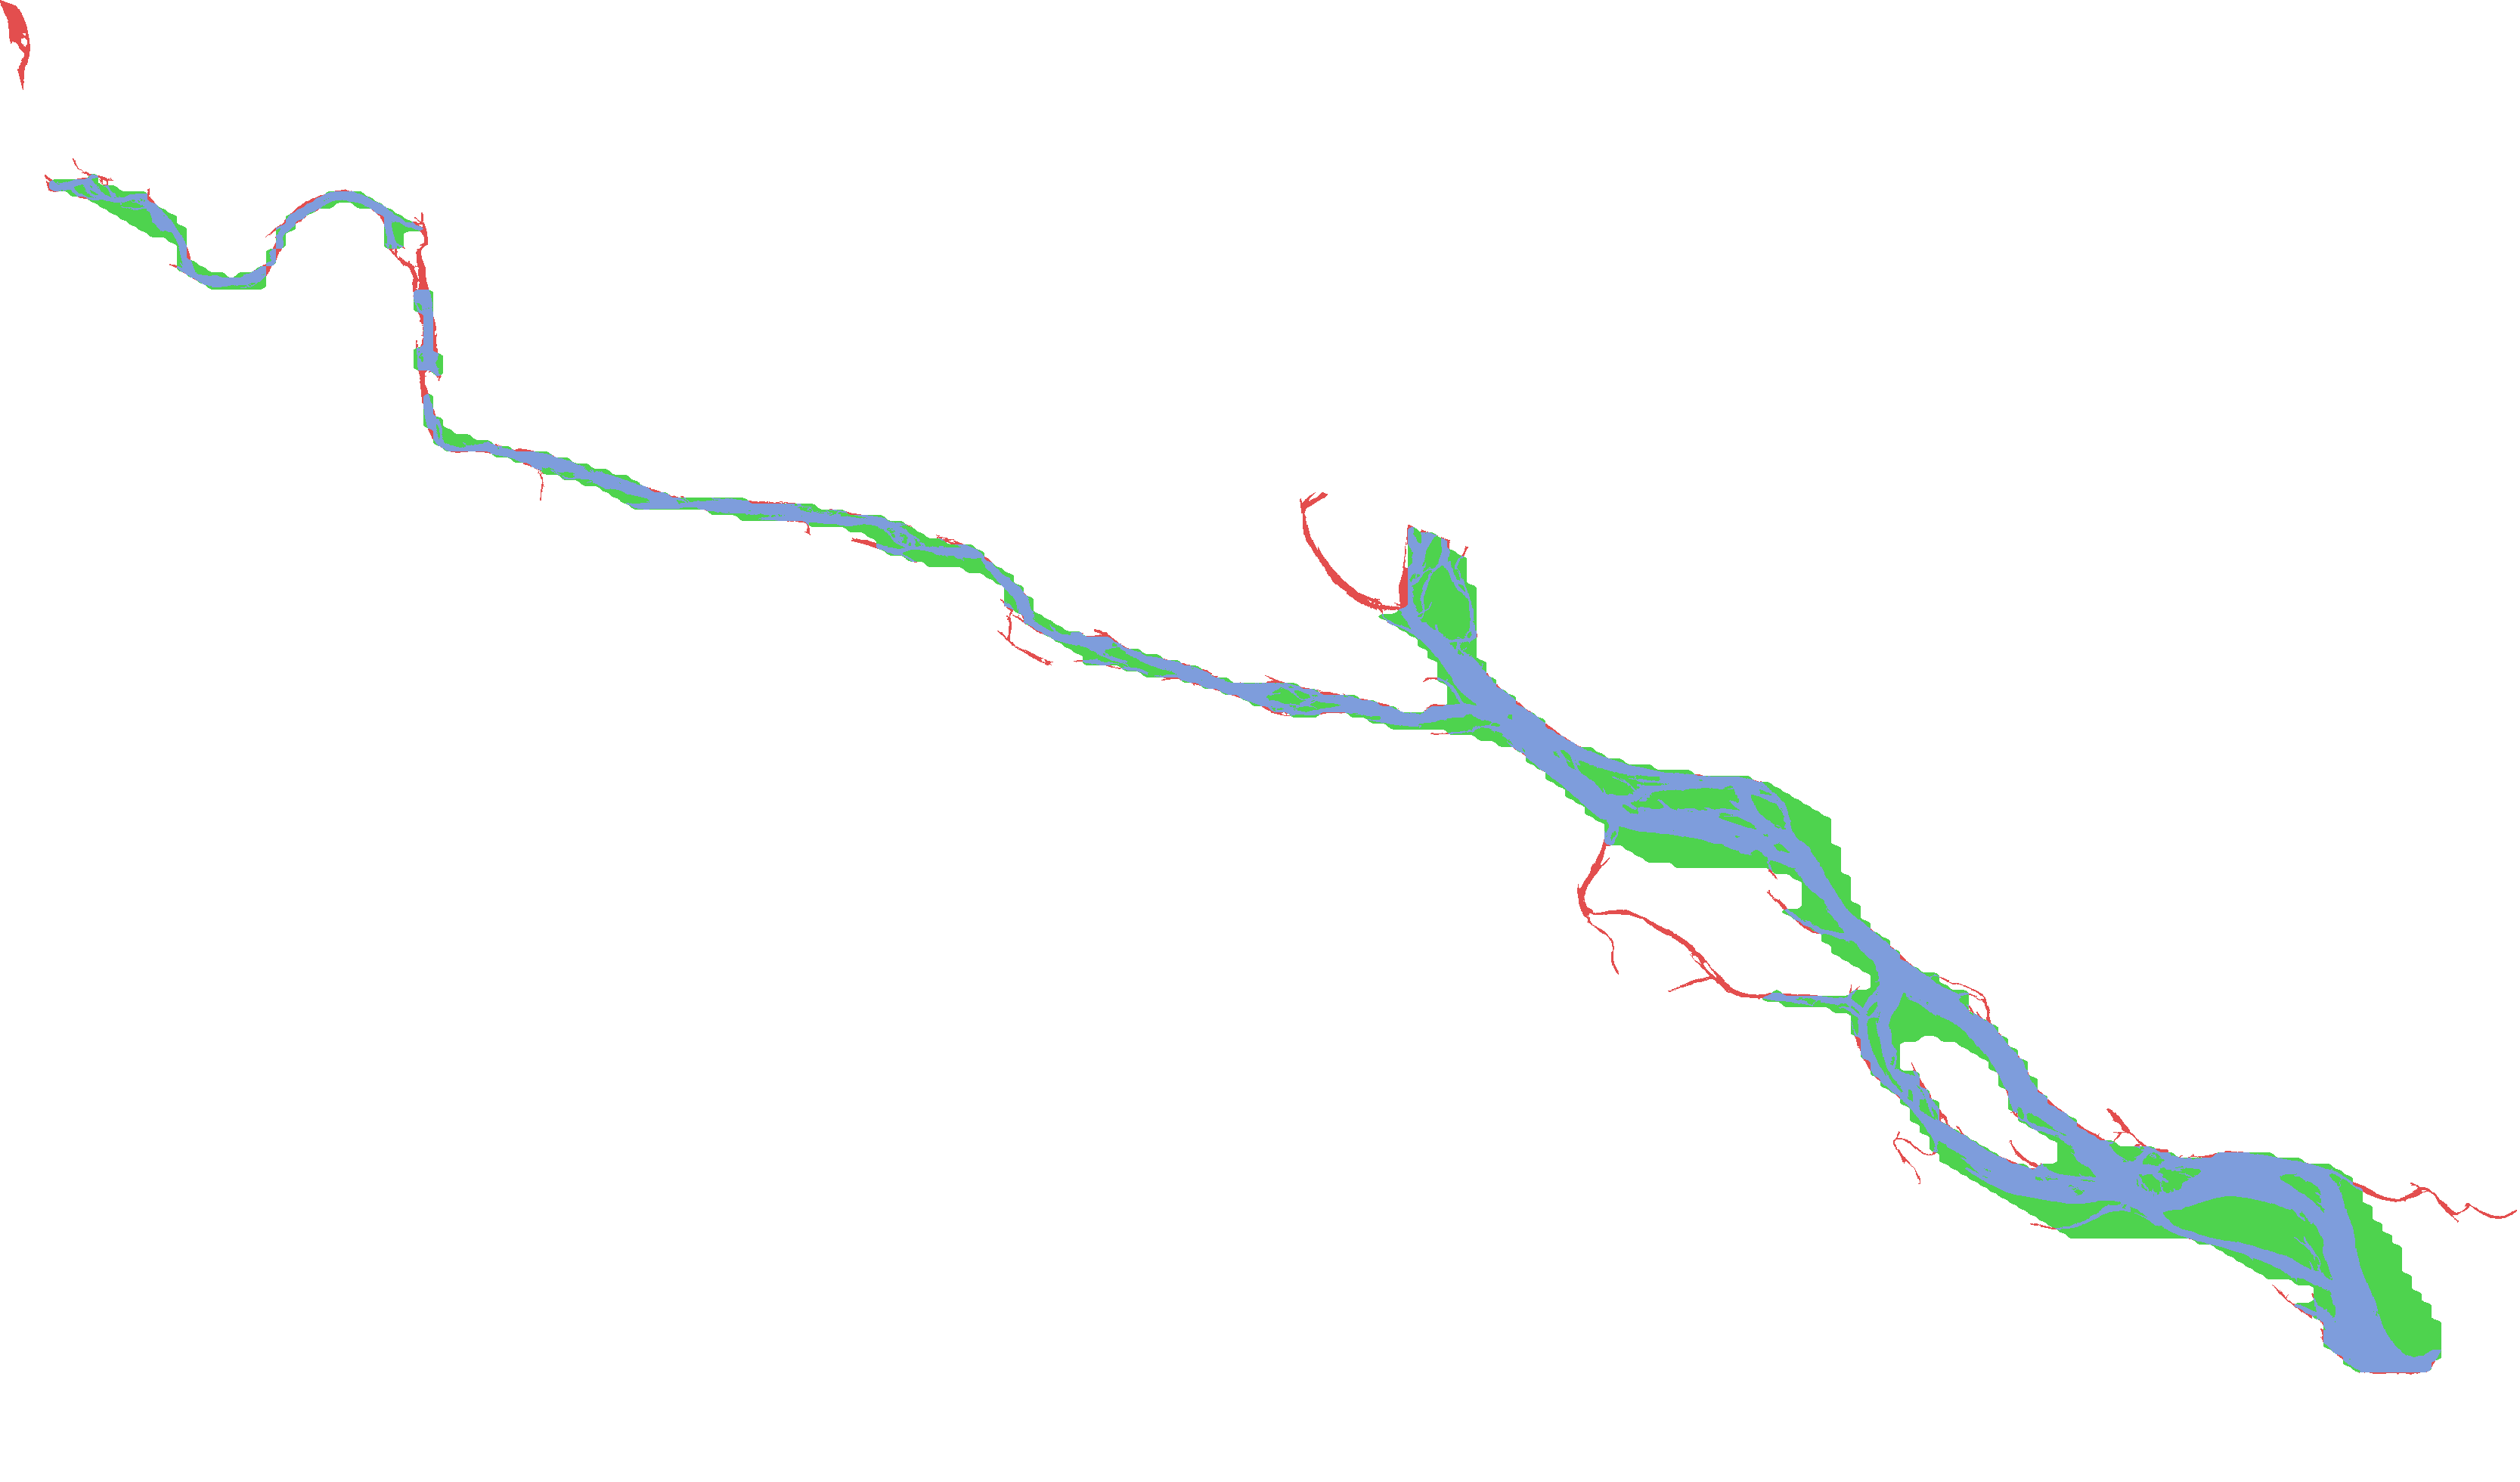

In [8]:
# ============================================================================
# DISPLAY RISK MAPS ON INTERACTIVE MAP — FOLIUM ONLY (No geemap/EE needed)
# Works on Kaggle, Colab, Local — Zero authentication required
# ============================================================================

import os
import io
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import rasterio

# ── Install folium if needed ──
try:
    import folium
    from folium.raster_layers import ImageOverlay
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'folium', '-q'])
    import folium
    from folium.raster_layers import ImageOverlay

from PIL import Image

RISK_DIR = 'georeferenced_risk_maps'

# ============================================================================
# STEP 1: GET MAP CENTER FROM GeoTIFF
# ============================================================================

print("=" * 70)
print("  BUILDING INTERACTIVE RISK MAP (Folium)")
print("=" * 70)

combined_risk_tif = os.path.join(RISK_DIR, 'combined_risk.tif')

with rasterio.open(combined_risk_tif) as src:
    bounds = src.bounds
    center_lat = (bounds.top + bounds.bottom) / 2
    center_lon = (bounds.left + bounds.right) / 2
    crs = src.crs

img_bounds = [[bounds.bottom, bounds.left], [bounds.top, bounds.right]]

print(f"  Center: ({center_lat:.6f}, {center_lon:.6f})")
print(f"  Bounds: N={bounds.top:.6f} S={bounds.bottom:.6f} "
      f"E={bounds.right:.6f} W={bounds.left:.6f}")

# ============================================================================
# STEP 2: HELPER — Convert numpy array to transparent PNG for overlay
# ============================================================================

def array_to_overlay_png(data, cmap_name, vmin=0, vmax=1,
                         alpha=0.7, mask_below=0.02, save_path=None):
    """Convert a 2D numpy array to a transparent PNG suitable for map overlay."""
    h, w = data.shape

    # Get colormap
    if isinstance(cmap_name, str):
        cmap = plt.get_cmap(cmap_name)
    else:
        cmap = cmap_name

    # Normalize
    norm_data = np.clip((data - vmin) / (vmax - vmin + 1e-10), 0, 1)

    # Apply colormap → RGBA
    rgba = cmap(norm_data)
    rgba = (rgba * 255).astype(np.uint8)

    # Make low-value pixels transparent
    rgba[data < mask_below, 3] = 0

    # Set overall alpha for visible pixels
    visible = data >= mask_below
    rgba[visible, 3] = int(alpha * 255)

    img = Image.fromarray(rgba, mode='RGBA')

    if save_path:
        img.save(save_path)

    return img


def binary_mask_to_overlay_png(mask, color_rgb, alpha=0.5, save_path=None):
    """Convert a binary mask to a colored transparent PNG."""
    h, w = mask.shape
    rgba = np.zeros((h, w, 4), dtype=np.uint8)
    active = mask > 0.5
    rgba[active, 0] = color_rgb[0]
    rgba[active, 1] = color_rgb[1]
    rgba[active, 2] = color_rgb[2]
    rgba[active, 3] = int(alpha * 255)

    img = Image.fromarray(rgba, mode='RGBA')
    if save_path:
        img.save(save_path)
    return img


def change_map_to_overlay_png(baseline, prediction, save_path=None):
    """Create erosion/accretion/stable change overlay."""
    h, w = baseline.shape
    rgba = np.zeros((h, w, 4), dtype=np.uint8)

    stable = (baseline > 0.5) & (prediction > 0.5)
    erosion = (baseline > 0.5) & (prediction < 0.5)
    accretion = (baseline < 0.5) & (prediction > 0.5)

    # Blue = stable, Red = erosion, Green = accretion
    rgba[stable, :] = [50, 100, 200, 160]
    rgba[erosion, :] = [220, 30, 30, 200]
    rgba[accretion, :] = [30, 200, 30, 200]

    img = Image.fromarray(rgba, mode='RGBA')
    if save_path:
        img.save(save_path)
    return img

# ============================================================================
# STEP 3: CREATE ALL OVERLAY PNGs
# ============================================================================

print("\n  Creating overlay images...")

overlay_dir = os.path.join(RISK_DIR, 'overlays')
os.makedirs(overlay_dir, exist_ok=True)

# Custom colormaps
cmap_erosion = LinearSegmentedColormap.from_list(
    'erosion_r', ['#00000000', '#FFFF00', '#FF8C00', '#FF0000', '#8B0000'])
cmap_accretion = LinearSegmentedColormap.from_list(
    'accretion_g', ['#00000000', '#90EE90', '#32CD32', '#006400', '#003300'])
cmap_combined = LinearSegmentedColormap.from_list(
    'combined_hot', ['#00000000', '#FFFF00', '#FF8C00', '#FF0000', '#8B0000'])
cmap_river = LinearSegmentedColormap.from_list(
    'river_blue', ['#00000000', '#0066CC', '#003399'])

# A) Combined risk
combined_path = os.path.join(overlay_dir, 'combined_risk.png')
array_to_overlay_png(combined_risk, cmap_combined, alpha=0.75,
                     mask_below=0.03, save_path=combined_path)
print(f"  ✓ Combined risk overlay")

# B) Erosion probability
erosion_path = os.path.join(overlay_dir, 'erosion_prob.png')
array_to_overlay_png(erosion_probability, cmap_erosion, alpha=0.75,
                     mask_below=0.03, save_path=erosion_path)
print(f"  ✓ Erosion probability overlay")

# C) Accretion probability
accretion_path = os.path.join(overlay_dir, 'accretion_prob.png')
array_to_overlay_png(accretion_probability, cmap_accretion, alpha=0.75,
                     mask_below=0.03, save_path=accretion_path)
print(f"  ✓ Accretion probability overlay")

# D) Baseline river
baseline_path = os.path.join(overlay_dir, 'baseline_river.png')
binary_mask_to_overlay_png(last_known_binary_orig, [30, 100, 220],
                           alpha=0.5, save_path=baseline_path)
print(f"  ✓ Baseline river overlay")

# E) Classified risk zones
classified_path = os.path.join(overlay_dir, 'classified_zones.png')
classified_rgba = np.zeros((original_height, original_width, 4), dtype=np.uint8)
zone_colors = {
    1: [0, 200, 0, 150],      # Very Low = Green
    2: [255, 255, 0, 160],     # Low = Yellow
    3: [255, 200, 0, 170],     # Moderate = Orange-Yellow
    4: [255, 100, 0, 190],     # High = Orange
    5: [255, 0, 0, 220],       # Very High = Red
}
for level, color in zone_colors.items():
    classified_rgba[risk_classified == level] = color
Image.fromarray(classified_rgba, 'RGBA').save(classified_path)
print(f"  ✓ Classified zones overlay")

# F) River frequency
freq_path = os.path.join(overlay_dir, 'river_frequency.png')
cmap_freq = LinearSegmentedColormap.from_list(
    'freq', ['#00000000', '#87CEEB', '#4169E1', '#00008B'])
array_to_overlay_png(river_frequency, cmap_freq, alpha=0.65,
                     mask_below=0.05, save_path=freq_path)
print(f"  ✓ River frequency overlay")

# G) Per-year change maps (milestones)
milestone_indices = [0, 4, 9, min(14, len(future_years)-1)]
milestone_indices = sorted(list(set([i for i in milestone_indices
                                      if i < len(future_years)])))

for idx in milestone_indices:
    year = future_years[idx]
    change_path = os.path.join(overlay_dir, f'change_{year}.png')
    change_map_to_overlay_png(last_known_binary_orig,
                              future_preds_original[idx],
                              save_path=change_path)
    print(f"  ✓ Change map {year} overlay")

# H) Dot density overlay
dots_path = os.path.join(overlay_dir, 'combined_dots.png')
Image.fromarray(combined_dots, 'RGBA').save(dots_path)
print(f"  ✓ Dot density overlay")

# ============================================================================
# STEP 4: BUILD FOLIUM MAP WITH ALL LAYERS
# ============================================================================

print("\n  Building interactive map...")

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=13,
    control_scale=True,
    tiles=None
)

# ── Basemap layers ──
folium.TileLayer(
    tiles='OpenStreetMap',
    name='OpenStreetMap',
    control=True
).add_to(m)

folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
    attr='Google Satellite',
    name='🛰️ Satellite',
    control=True
).add_to(m)

folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}',
    attr='Google Hybrid',
    name='🗺️ Hybrid',
    control=True
).add_to(m)

# ── Risk overlay layers ──
layer_configs = [
    (baseline_path,    f'🔵 Baseline River ({last_known_year})', True),
    (combined_path,    '🔴 Combined Risk Probability', True),
    (erosion_path,     '🟥 Erosion Probability', False),
    (accretion_path,   '🟩 Accretion Probability', False),
    (classified_path,  '🎯 Classified Risk Zones', False),
    (freq_path,        '🌊 River Frequency', False),
    (dots_path,        '⚫ Risk Dot Density', False),
]

for filepath, name, show in layer_configs:
    if os.path.exists(filepath):
        ImageOverlay(
            image=filepath,
            bounds=img_bounds,
            opacity=0.8,
            name=name,
            interactive=True,
            show=show,
        ).add_to(m)

# ── Per-year change maps ──
for idx in milestone_indices:
    year = future_years[idx]
    change_path = os.path.join(overlay_dir, f'change_{year}.png')
    if os.path.exists(change_path):
        ImageOverlay(
            image=change_path,
            bounds=img_bounds,
            opacity=0.75,
            name=f'📅 Change Map {year}',
            interactive=True,
            show=False,
        ).add_to(m)

# ── Study area boundary ──
folium.Rectangle(
    bounds=img_bounds,
    color='white', weight=2, fill=False,
    dash_array='8', opacity=0.8,
    popup=folium.Popup(
        f'<b>Study Area</b><br>'
        f'Lat: {bounds.bottom:.4f}° to {bounds.top:.4f}°<br>'
        f'Lon: {bounds.left:.4f}° to {bounds.right:.4f}°<br>'
        f'Prediction: {future_years[0]}-{future_years[-1]}',
        max_width=250
    )
).add_to(m)

# ── Risk Legend (HTML) ──
legend_html = f'''
<div style="position: fixed; bottom: 25px; left: 25px; z-index: 1000;
            background: rgba(255,255,255,0.95); padding: 14px 18px;
            border-radius: 10px; border: 2px solid #333;
            font-family: Arial, sans-serif; font-size: 12px;
            box-shadow: 3px 3px 8px rgba(0,0,0,0.3); max-width: 220px;">
    <b style="font-size: 14px; display:block; margin-bottom:8px;">
    🗺️ Risk Map Legend</b>

    <div style="margin-bottom:6px;">
    <b>Probability Overlays:</b></div>

    <div style="display:flex; align-items:center; margin:3px 0;">
      <span style="background:#8B0000; width:14px; height:14px;
            display:inline-block; border-radius:50%; margin-right:6px;"></span>
      Very High (80-100%)</div>
    <div style="display:flex; align-items:center; margin:3px 0;">
      <span style="background:#FF4500; width:14px; height:14px;
            display:inline-block; border-radius:50%; margin-right:6px;"></span>
      High (60-80%)</div>
    <div style="display:flex; align-items:center; margin:3px 0;">
      <span style="background:#FFC800; width:14px; height:14px;
            display:inline-block; border-radius:50%; margin-right:6px;"></span>
      Moderate (40-60%)</div>
    <div style="display:flex; align-items:center; margin:3px 0;">
      <span style="background:#FFFF00; width:14px; height:14px;
            display:inline-block; border-radius:50%; margin-right:6px;"></span>
      Low (20-40%)</div>
    <div style="display:flex; align-items:center; margin:3px 0;">
      <span style="background:#00C800; width:14px; height:14px;
            display:inline-block; border-radius:50%; margin-right:6px;"></span>
      Very Low (0-20%)</div>

    <hr style="margin:8px 0; border:none; border-top:1px solid #ccc;">

    <div style="margin-bottom:4px;">
    <b>Change Maps:</b></div>

    <div style="display:flex; align-items:center; margin:3px 0;">
      <span style="background:#3264C8; width:14px; height:14px;
            display:inline-block; border-radius:50%; margin-right:6px;"></span>
      Stable River</div>
    <div style="display:flex; align-items:center; margin:3px 0;">
      <span style="background:#DC1E1E; width:14px; height:14px;
            display:inline-block; border-radius:50%; margin-right:6px;"></span>
      Erosion (land lost)</div>
    <div style="display:flex; align-items:center; margin:3px 0;">
      <span style="background:#1EC81E; width:14px; height:14px;
            display:inline-block; border-radius:50%; margin-right:6px;"></span>
      Accretion (land gained)</div>

    <hr style="margin:8px 0; border:none; border-top:1px solid #ccc;">
    <div style="font-size:10px; color:#666;">
      Prediction: {future_years[0]}-{future_years[-1]}<br>
      Model: AttUNet+ConvLSTM (seq={BEST_SEQ_LEN})<br>
      ℹ️ Toggle layers using control panel →
    </div>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# ── Layer control ──
folium.LayerControl(collapsed=False).add_to(m)

# ============================================================================
# STEP 5: SAVE & DISPLAY
# ============================================================================

# Save as standalone HTML
html_path = os.path.join(RISK_DIR, 'interactive_risk_map.html')
m.save(html_path)
html_size = os.path.getsize(html_path) / (1024 * 1024)
print(f"\n  ✓ Saved: {html_path} ({html_size:.2f} MB)")
print("  ✓ Open this HTML file in any browser for full interactive map")

print("\n" + "=" * 70)
print("  DISPLAYING INTERACTIVE MAP IN NOTEBOOK")
print("=" * 70)
print("""
  Controls:
  • Layer panel (top-right) → Toggle layers ON/OFF
  • 🛰️ Switch between Satellite / OpenStreetMap / Hybrid
  • 🔴 Combined Risk shows erosion+accretion probability
  • 📅 Change Maps show erosion(red) / accretion(green) per year
  • Zoom in/out to explore specific zones
  • Click study area border for info popup
""")

# Display in notebook
m